In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import sys
import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyomo.environ as pe
from copy import deepcopy

import good
from good.reload import deep_reload


Unit Price Distribution by Fuel Type (operating_cost in $/W-s):

NATURAL GAS:
  Count: 1121
  Mean:  6.658767e-09 $/W-s
  Median: 6.822611e-09 $/W-s
  Std:   6.958334e-10 $/W-s
  Min:   3.423225e-09 $/W-s
  Max:   8.078021e-09 $/W-s
  25th percentile: 6.421746e-09 $/W-s
  75th percentile: 7.130883e-09 $/W-s

NUCLEAR:
  Count: 6
  Mean:  3.080903e-09 $/W-s
  Median: 3.080903e-09 $/W-s
  Std:   0.000000e+00 $/W-s
  Min:   3.080903e-09 $/W-s
  Max:   3.080903e-09 $/W-s
  25th percentile: 3.080903e-09 $/W-s
  75th percentile: 3.080903e-09 $/W-s


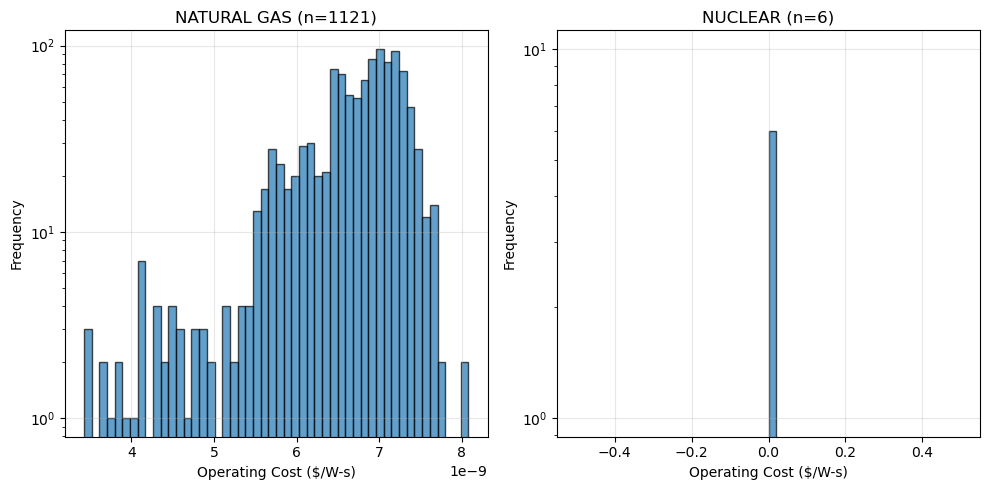



Price Modification:
  Minimum nonzero natural gas price: 3.423225e-09 $/W-s
  New nuclear price (90% of min natural gas): 3.080903e-09 $/W-s
  Number of nuclear assets to modify: 6
  Successfully modified 6 nuclear assets
  Saved modified data to Examples/WEC.json

Verification:
  All nuclear prices are now: 3.080903e-09 $/W-s
  All nuclear prices < min natural gas? True


In [2]:
# Read WEC.json and analyze unit price distributions by fuel type
WEC_FILE = 'Examples/WEC.json'

with open(WEC_FILE, 'r') as f:
    wec_data = json.load(f)

# Extract operating costs (unit prices) by fuel type
fuel_costs = {
    'natural gas': [],
    'nuclear': [],
}

# Iterate through all nodes and their assets
for node in wec_data['nodes']:
    if 'assets' in node:
        for asset_id, asset_info in node['assets'].items():
            # Skip if not a Producer or if operating_cost is missing
            if asset_info.get('_class') != 'Producer' or 'operating_cost' not in asset_info:
                continue
            
            fuel = asset_info.get('fuel', '').lower()
            operating_cost = asset_info.get('operating_cost')
            
            # Group by fuel type
            if fuel == 'natural gas':
                fuel_costs['natural gas'].append(operating_cost)
            elif fuel == 'nuclear':
                fuel_costs['nuclear'].append(operating_cost)
            else:
                pass

# Convert to numpy arrays for easier analysis
for fuel_type in fuel_costs:
    fuel_costs[fuel_type] = np.array(fuel_costs[fuel_type])

# Print summary statistics for each fuel type
print("Unit Price Distribution by Fuel Type (operating_cost in $/W-s):")
print("=" * 70)
for fuel_type in ['natural gas', 'nuclear']:
    costs = fuel_costs[fuel_type]
    if len(costs) > 0:
        print(f"\n{fuel_type.upper()}:")
        print(f"  Count: {len(costs)}")
        print(f"  Mean:  {np.mean(costs):.6e} $/W-s")
        print(f"  Median: {np.median(costs):.6e} $/W-s")
        print(f"  Std:   {np.std(costs):.6e} $/W-s")
        print(f"  Min:   {np.min(costs):.6e} $/W-s")
        print(f"  Max:   {np.max(costs):.6e} $/W-s")
        print(f"  25th percentile: {np.percentile(costs, 25):.6e} $/W-s")
        print(f"  75th percentile: {np.percentile(costs, 75):.6e} $/W-s")
    else:
        print(f"\n{fuel_type.upper()}: No data found")

# Optional: Create visualization of distributions
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes = axes.flatten()

for idx, fuel_type in enumerate(['natural gas', 'nuclear']):
    costs = fuel_costs[fuel_type]
    if len(costs) > 0:
        axes[idx].hist(costs, bins=50, edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'{fuel_type.upper()} (n={len(costs)})')
        axes[idx].set_xlabel('Operating Cost ($/W-s)')
        axes[idx].set_ylabel('Frequency')
        axes[idx].set_yscale('log')
        axes[idx].grid(True, alpha=0.3)
    else:
        axes[idx].text(0.5, 0.5, f'No data for {fuel_type}', 
                       ha='center', va='center', transform=axes[idx].transAxes)
        axes[idx].set_title(f'{fuel_type.upper()}')

# Hide the last subplot if not needed
#axes[5].axis('off')

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)

WEC_FILE = 'Examples/WEC.json'
# Modify nuclear prices to be lower than minimum nonzero natural gas prices
# Load WEC.json data (or use existing wec_data if already loaded)
if 'wec_data' not in globals():
    with open(WEC_FILE, 'r') as f:
        wec_data = json.load(f)

# First, find the minimum nonzero natural gas price
natural_gas_costs = []
nuclear_costs = []

# Collect all natural gas and nuclear operating costs
for node in wec_data['nodes']:
    if 'assets' in node:
        for asset_id, asset_info in node['assets'].items():
            if asset_info.get('_class') != 'Producer' or 'operating_cost' not in asset_info:
                continue
            
            fuel = asset_info.get('fuel', '').lower()
            operating_cost = asset_info.get('operating_cost')
            
            if fuel == 'natural gas' and operating_cost > 0:
                natural_gas_costs.append(operating_cost)
            elif fuel == 'nuclear':
                nuclear_costs.append(operating_cost)

# Find minimum nonzero natural gas price
if natural_gas_costs:
    min_natural_gas = min(natural_gas_costs)
    # Set nuclear price to be 10% lower than minimum natural gas price
    new_nuclear_price = min_natural_gas * 0.9
    
    print(f"\nPrice Modification:")
    print(f"  Minimum nonzero natural gas price: {min_natural_gas:.6e} $/W-s")
    print(f"  New nuclear price (90% of min natural gas): {new_nuclear_price:.6e} $/W-s")
    print(f"  Number of nuclear assets to modify: {len(nuclear_costs)}")
    
    # Update all nuclear assets in the JSON data
    modified_count = 0
    for node in wec_data['nodes']:
        if 'assets' in node:
            for asset_id, asset_info in node['assets'].items():
                if asset_info.get('_class') != 'Producer':
                    continue
                
                fuel = asset_info.get('fuel', '').lower()
                if fuel == 'nuclear' and 'operating_cost' in asset_info:
                    asset_info['operating_cost'] = new_nuclear_price
                    modified_count += 1
    
    print(f"  Successfully modified {modified_count} nuclear assets")
    
    # Save the modified data back to WEC.json
    with open(WEC_FILE, 'w') as f:
        json.dump(wec_data, f, indent=4)
    
    print(f"  Saved modified data to {WEC_FILE}")
    
    # Reload the data to verify changes
    with open(WEC_FILE, 'r') as f:
        wec_data = json.load(f)
    
    # Verify the changes
    print(f"\nVerification:")
    nuclear_costs_after = []
    for node in wec_data['nodes']:
        if 'assets' in node:
            for asset_id, asset_info in node['assets'].items():
                if asset_info.get('_class') != 'Producer':
                    continue
                fuel = asset_info.get('fuel', '').lower()
                if fuel == 'nuclear' and 'operating_cost' in asset_info:
                    nuclear_costs_after.append(asset_info['operating_cost'])
    
    if nuclear_costs_after:
        print(f"  All nuclear prices are now: {nuclear_costs_after[0]:.6e} $/W-s")
        print(f"  All nuclear prices < min natural gas? {all(cost < min_natural_gas for cost in nuclear_costs_after)}")
else:
    print("\nWarning: No nonzero natural gas prices found. Nuclear prices not modified.")

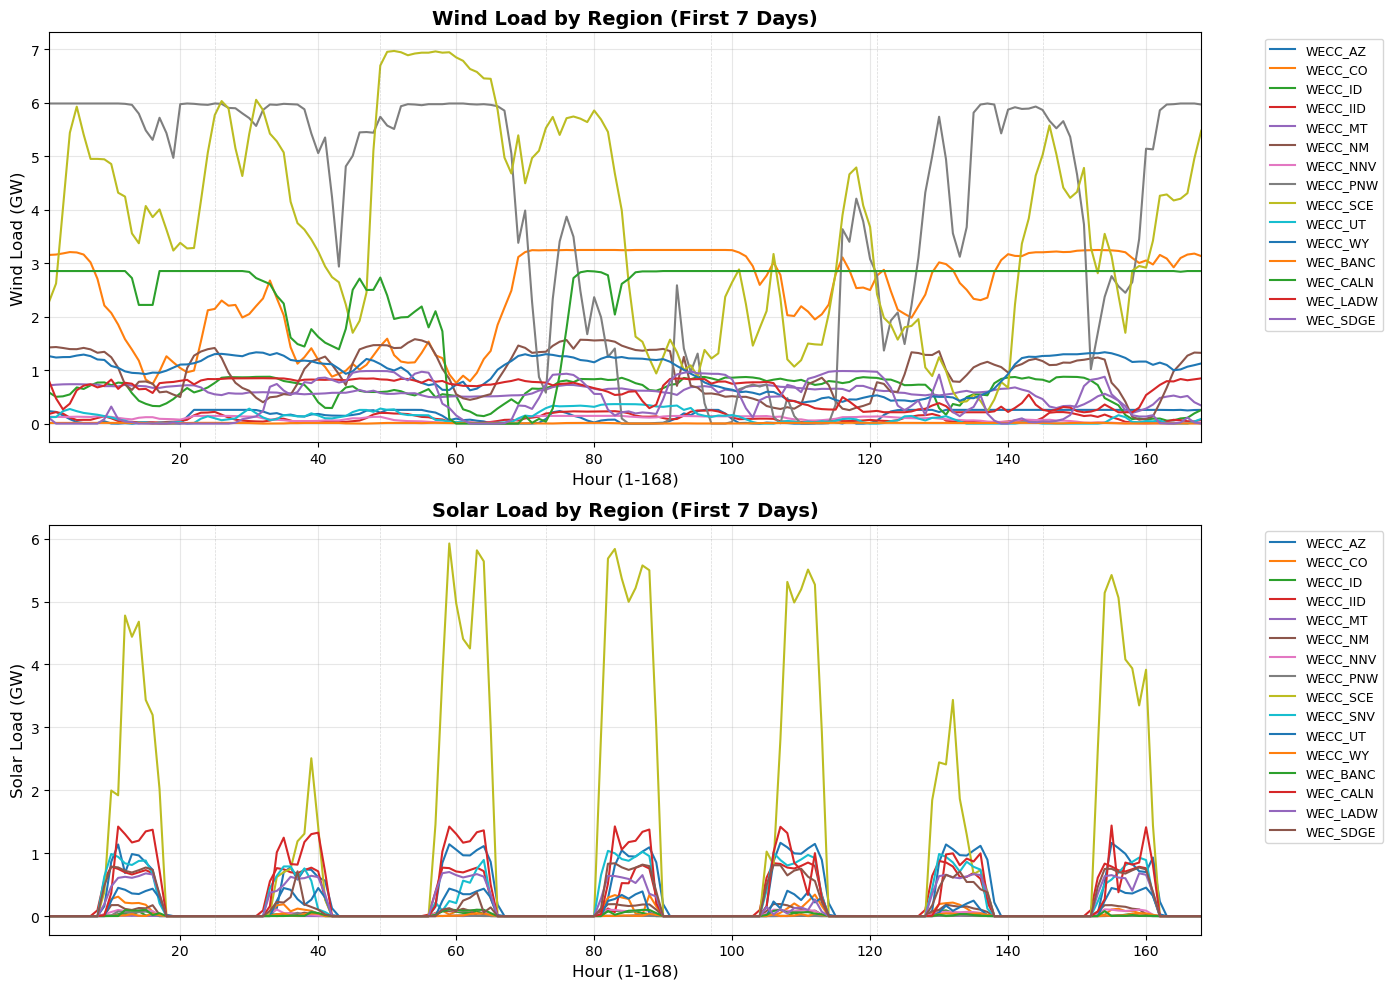


Wind Load Summary by Region:

WECC_AZ:
  Max Load: 0.257 GW
  Min Load: 0.000 GW
  Mean Load: 0.146 GW
  Total Capacity: 0.257 GW (peak)

WECC_CO:
  Max Load: 3.245 GW
  Min Load: 0.738 GW
  Mean Load: 2.425 GW
  Total Capacity: 3.245 GW (peak)

WECC_ID:
  Max Load: 0.875 GW
  Min Load: 0.056 GW
  Mean Load: 0.632 GW
  Total Capacity: 0.875 GW (peak)

WECC_IID:
  Max Load: 0.250 GW
  Min Load: 0.012 GW
  Mean Load: 0.099 GW
  Total Capacity: 0.250 GW (peak)

WECC_MT:
  Max Load: 0.736 GW
  Min Load: 0.200 GW
  Mean Load: 0.586 GW
  Total Capacity: 0.736 GW (peak)

WECC_NM:
  Max Load: 1.578 GW
  Min Load: 0.073 GW
  Mean Load: 0.968 GW
  Total Capacity: 1.578 GW (peak)

WECC_NNV:
  Max Load: 0.144 GW
  Min Load: 0.000 GW
  Mean Load: 0.088 GW
  Total Capacity: 0.144 GW (peak)

WECC_PNW:
  Max Load: 5.983 GW
  Min Load: 0.000 GW
  Mean Load: 3.959 GW
  Total Capacity: 5.983 GW (peak)

WECC_SCE:
  Max Load: 6.965 GW
  Min Load: 0.224 GW
  Mean Load: 3.687 GW
  Total Capacity: 6.965 GW (

In [3]:
# Plot wind and solar load by region for the first 7 days (168 hours)
# Load JSON directly to access profiles dictionary
with open(WEC_FILE, 'r') as f:
    wec_data = json.load(f)

def filter_wind_profile_artifacts(profile_data):
    """
    Filter out day-of-month artifacts from wind profiles.
    
    The preprocessing accidentally included the "Day Of Month" column divided by 1000,
    creating small values (0.001, 0.002, 0.003, ...) every 25th element.
    Pattern: [0.001, 24 hourly values, 0.002, 24 hourly values, 0.003, ...]
    
    This function removes every 25th element (indices 0, 25, 50, 75, ...).
    """
    if profile_data is None or len(profile_data) == 0:
        return profile_data
    
    profile_array = np.array(profile_data)
    
    # Create mask to keep all elements except every 25th (0, 25, 50, 75, ...)
    # These are the day-of-month artifacts
    mask = np.ones(len(profile_array), dtype=bool)
    mask[::25] = False  # Remove every 25th element
    
    filtered_profile = profile_array[mask]
    return filtered_profile.tolist()

# Extract wind and solar assets by region
wind_loads_by_region = {}
solar_loads_by_region = {}

num_hours = 168  # First 7 days

# Iterate through all nodes (regions)
for node in wec_data['nodes']:
    region_id = node.get('id', 'UNKNOWN')
    
    # Initialize arrays for this region
    wind_loads_by_region[region_id] = np.zeros(num_hours)
    solar_loads_by_region[region_id] = np.zeros(num_hours)
    
    # Get profiles dictionary for this node
    profiles_dict = node.get('profiles', {})
    
    # Get assets from the node
    if 'assets' in node:
        for asset_id, asset_info in node['assets'].items():
            # Check if it's a Producer or Load asset with fuel type
            fuel = asset_info.get('fuel', '').lower() if asset_info.get('fuel') else ''
            
            if fuel not in ['wind', 'solar']:
                continue
            
            # Get capacity
            capacity = asset_info.get('installed_capacity', 0)
            if capacity == 0:
                continue
            
            # Get profile reference (e.g., "WECC_AZ:wind:" or "WECC_AZ:solar:")
            profile_ref = asset_info.get('profile', '')
            capacity_factor = asset_info.get('capacity_factor', 1.0)
            
            # Try to find matching profile(s) in profiles dictionary
            # Some assets may have multiple profiles (e.g., "WECC_AZ:wind:1", "WECC_AZ:wind:2")
            matching_profiles = []
            
            # Try exact match first
            if profile_ref in profiles_dict:
                matching_profiles.append(profiles_dict[profile_ref])
            else:
                # Try to find all profiles with matching prefix
                for profile_key, profile_values in profiles_dict.items():
                    # Check if profile key starts with the profile reference
                    if profile_key.startswith(profile_ref):
                        matching_profiles.append(profile_values)
            
            # Calculate load for each hour
            if fuel == 'wind':
                if matching_profiles:
                    # Sum across all matching profiles (if multiple)
                    for profile_data in matching_profiles:
                        if profile_data is not None and len(profile_data) > 0:
                            # Filter out day-of-month artifacts from wind profiles
                            filtered_profile = filter_wind_profile_artifacts(profile_data)
                            
                            if len(filtered_profile) >= num_hours:
                                # Use time-varying profile (filtered_profile is 0-indexed, hours 0-167)
                                for hour_idx in range(num_hours):
                                    wind_loads_by_region[region_id][hour_idx] += capacity * filtered_profile[hour_idx]
                            else:
                                # Use constant capacity factor if profile is too short after filtering
                                for hour_idx in range(num_hours):
                                    wind_loads_by_region[region_id][hour_idx] += capacity * capacity_factor
                        else:
                            # Use constant capacity factor if profile is None or empty
                            for hour_idx in range(num_hours):
                                wind_loads_by_region[region_id][hour_idx] += capacity * capacity_factor
                else:
                    # Use constant capacity factor if no profile found
                    for hour_idx in range(num_hours):
                        wind_loads_by_region[region_id][hour_idx] += capacity * capacity_factor
                        
            elif fuel == 'solar':
                if matching_profiles:
                    # Sum across all matching profiles (if multiple)
                    for profile_data in matching_profiles:
                        if profile_data is not None and len(profile_data) >= num_hours:
                            # Use time-varying profile (profile_data is 0-indexed, hours 0-167)
                            for hour_idx in range(num_hours):
                                solar_loads_by_region[region_id][hour_idx] += capacity * profile_data[hour_idx]
                        else:
                            # Use constant capacity factor if profile is too short
                            for hour_idx in range(num_hours):
                                solar_loads_by_region[region_id][hour_idx] += capacity * capacity_factor
                else:
                    # Use constant capacity factor if no profile found
                    for hour_idx in range(num_hours):
                        solar_loads_by_region[region_id][hour_idx] += capacity * capacity_factor

# Convert to GW for better readability
for region_id in wind_loads_by_region:
    wind_loads_by_region[region_id] = wind_loads_by_region[region_id] / 1e9  # Convert to GW
for region_id in solar_loads_by_region:
    solar_loads_by_region[region_id] = solar_loads_by_region[region_id] / 1e9  # Convert to GW

# Create plots
# Hours are 1-indexed (1-168) for display, but profile_data is 0-indexed (0-167)
hours = np.arange(1, num_hours + 1)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot wind load by region
ax1 = axes[0]
for region_id, loads in wind_loads_by_region.items():
    if np.sum(loads) > 0:  # Only plot regions with wind capacity
        ax1.plot(hours, loads, label=region_id, linewidth=1.5)

ax1.set_xlabel('Hour (1-168)', fontsize=12)
ax1.set_ylabel('Wind Load (GW)', fontsize=12)
ax1.set_title('Wind Load by Region (First 7 Days)', fontsize=14, fontweight='bold')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(1, num_hours)
# Add vertical lines to mark day boundaries
for day in range(1, 8):
    ax1.axvline(x=(day-1)*24 + 1, color='gray', linestyle='--', alpha=0.3, linewidth=0.5)

# Plot solar load by region
ax2 = axes[1]
for region_id, loads in solar_loads_by_region.items():
    if np.sum(loads) > 0:  # Only plot regions with solar capacity
        ax2.plot(hours, loads, label=region_id, linewidth=1.5)

ax2.set_xlabel('Hour (1-168)', fontsize=12)
ax2.set_ylabel('Solar Load (GW)', fontsize=12)
ax2.set_title('Solar Load by Region (First 7 Days)', fontsize=14, fontweight='bold')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(1, num_hours)
# Add vertical lines to mark day boundaries
for day in range(1, 8):
    ax2.axvline(x=(day-1)*24 + 1, color='gray', linestyle='--', alpha=0.3, linewidth=0.5)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nWind Load Summary by Region:")
print("=" * 70)
for region_id, loads in sorted(wind_loads_by_region.items()):
    if np.sum(loads) > 0:
        print(f"\n{region_id}:")
        print(f"  Max Load: {np.max(loads):.3f} GW")
        print(f"  Min Load: {np.min(loads):.3f} GW")
        print(f"  Mean Load: {np.mean(loads):.3f} GW")
        print(f"  Total Capacity: {np.max(loads):.3f} GW (peak)")

print("\n\nSolar Load Summary by Region:")
print("=" * 70)
for region_id, loads in sorted(solar_loads_by_region.items()):
    if np.sum(loads) > 0:
        print(f"\n{region_id}:")
        print(f"  Max Load: {np.max(loads):.3f} GW")
        print(f"  Min Load: {np.min(loads):.3f} GW")
        print(f"  Mean Load: {np.mean(loads):.3f} GW")
        print(f"  Total Capacity: {np.max(loads):.3f} GW (peak)")

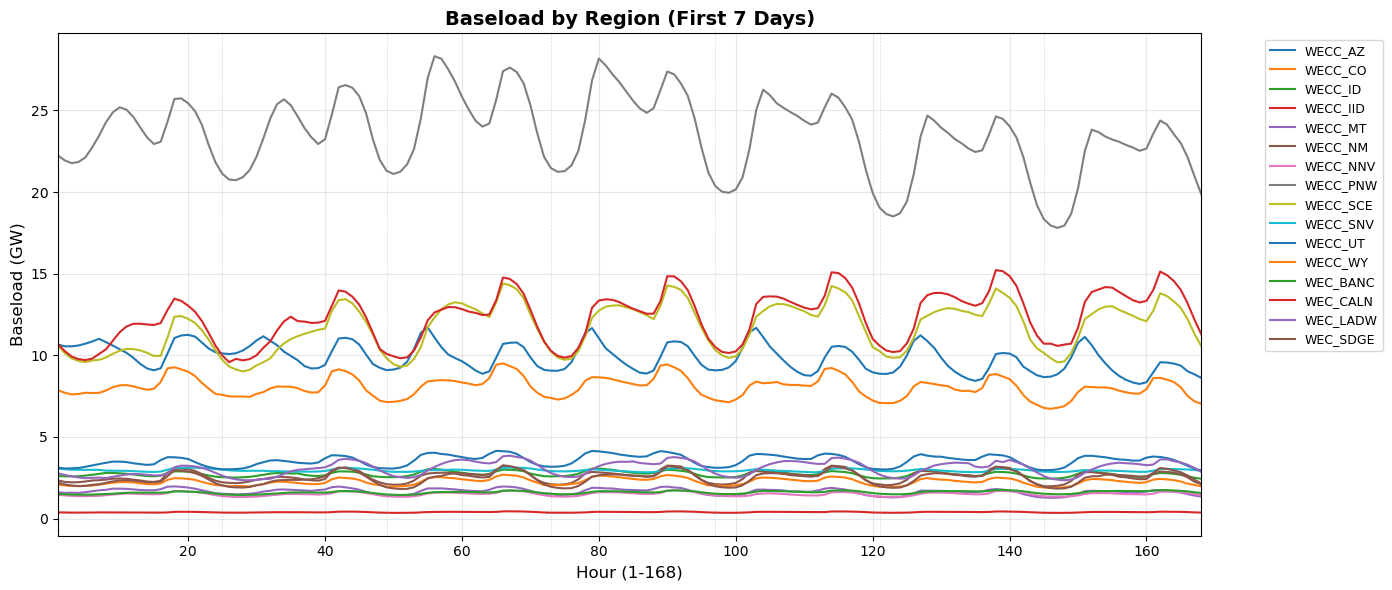

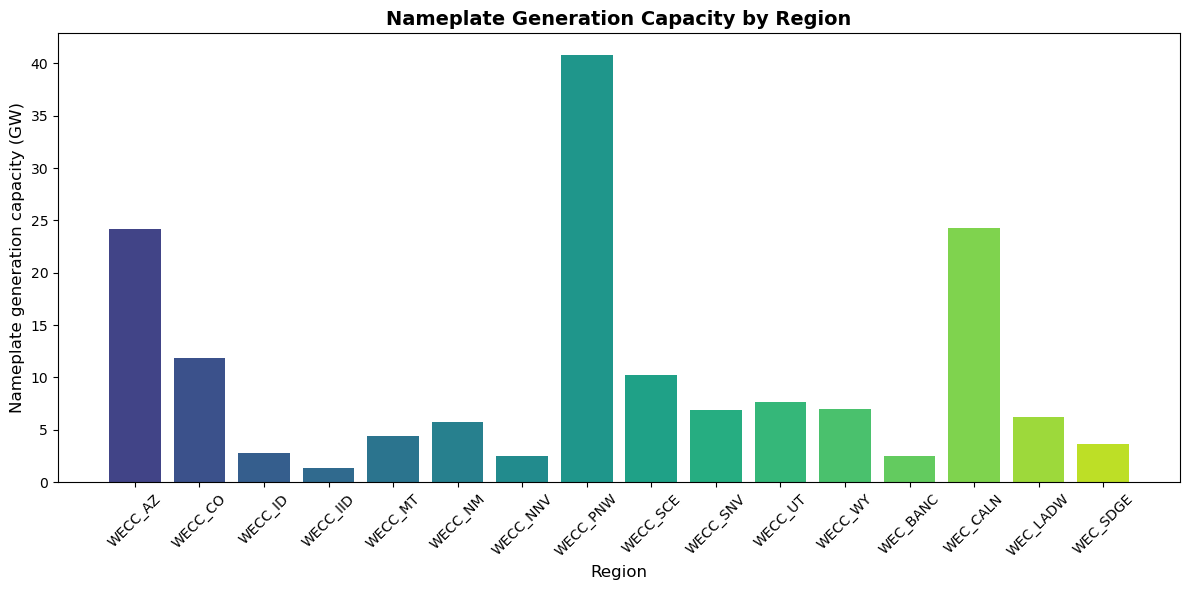

In [4]:
# Baseload by region (one graph) and nameplate generation capacity by region (one graph)
# Uses wec_data and num_hours from previous cell

num_hours_plot = num_hours if 'num_hours' in dir() else 168
if 'wec_data' not in dir():
    with open(WEC_FILE, 'r') as f:
        wec_data = json.load(f)

# --- Baseload by region (hourly, GW) ---
base_loads_by_region = {}
for node in wec_data['nodes']:
    region_id = node.get('id', 'UNKNOWN')
    base_loads_by_region[region_id] = np.zeros(num_hours_plot)
    profiles_dict = node.get('profiles', {})
    if 'assets' not in node:
        continue
    for asset_id, asset_info in node['assets'].items():
        if asset_info.get('_class') != 'Load':
            continue
        if 'base_load' not in asset_id.lower():
            continue
        cap = asset_info.get('installed_capacity', 0)
        if cap == 0:
            continue
        cap = abs(cap)  # load is typically negative
        profile_ref = asset_info.get('profile', None)
        if isinstance(profile_ref, str):
            profile_arr = profiles_dict.get(profile_ref)
        else:
            profile_arr = profile_ref
        if profile_arr is None or (isinstance(profile_arr, (list, np.ndarray)) and len(profile_arr) == 0):
            profile_arr = np.ones(num_hours_plot)
        else:
            profile_arr = np.atleast_1d(np.asarray(profile_arr))
            if profile_arr.size == 1:
                profile_arr = np.full(num_hours_plot, float(profile_arr.flat[0]))
            else:
                profile_arr = np.resize(profile_arr[:num_hours_plot], num_hours_plot)
        for h in range(num_hours_plot):
            base_loads_by_region[region_id][h] += cap * profile_arr[h]

# Convert to GW
for r in base_loads_by_region:
    base_loads_by_region[r] = base_loads_by_region[r] / 1e9

# --- Nameplate generation capacity by region (GW) ---
nameplate_gen_by_region = {}
for node in wec_data['nodes']:
    region_id = node.get('id', 'UNKNOWN')
    nameplate_gen_by_region[region_id] = 0.0
    if 'assets' not in node:
        continue
    for asset_id, asset_info in node['assets'].items():
        if asset_info.get('_class') != 'Producer':
            continue
        nameplate_gen_by_region[region_id] += asset_info.get('installed_capacity', 0)
# Convert to GW
for r in nameplate_gen_by_region:
    nameplate_gen_by_region[r] = nameplate_gen_by_region[r] / 1e9

# --- Plot 1: Baseload for each region (one graph) ---
hours_display = np.arange(1, num_hours_plot + 1)
fig1, ax1 = plt.subplots(1, 1, figsize=(14, 6))
for region_id, loads in sorted(base_loads_by_region.items()):
    if np.sum(loads) > 0:
        ax1.plot(hours_display, loads, label=region_id, linewidth=1.5)
ax1.set_xlabel('Hour (1-168)', fontsize=12)
ax1.set_ylabel('Baseload (GW)', fontsize=12)
ax1.set_title('Baseload by Region (First 7 Days)', fontsize=14, fontweight='bold')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(1, num_hours_plot)
for day in range(1, 8):
    ax1.axvline(x=(day - 1) * 24 + 1, color='gray', linestyle='--', alpha=0.3, linewidth=0.5)
plt.tight_layout()
plt.show()

# --- Plot 2: Nameplate generation capacity per region (bar chart) ---
fig2, ax2 = plt.subplots(1, 1, figsize=(12, 6))
regions_sorted = sorted(nameplate_gen_by_region.keys())
caps = [nameplate_gen_by_region[r] for r in regions_sorted]
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(regions_sorted)))
bars = ax2.bar(regions_sorted, caps, color=colors)
ax2.set_xlabel('Region', fontsize=12)
ax2.set_ylabel('Nameplate generation capacity (GW)', fontsize=12)
ax2.set_title('Nameplate Generation Capacity by Region', fontsize=14, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## Configuration

Set up the parameters for the analysis:


In [5]:
# Configuration
GRAPH_FILE = 'Examples/WEC.json'  # Path to graph JSON file
POLICIES_FILE = 'Examples/policies.json'  # Path to policies JSON file (optional)

# Regions representing California within the WEC network
CALIFORNIA_REGIONS = ['WEC_BANC', 'WEC_CALN', 'WEC_LADW', 'WEC_SDGE', 'WECC_IID', 'WECC_SCE']

# Transmission line efficiency (fraction 0-1). Applied to all transmission lines before optimization.
# In WEC.json, "operating_cost" (e.g. 2.222e-9) is cost per W-s, NOT efficiency. Efficiency is separate (default 1.0).
TRANSMISSION_EFFICIENCY = 0.97  # 1.0 = 100% (no losses). Set < 1 for losses (e.g. 0.97 for 3% loss).

# Time period: 7 days * 24 hours = 168 hours
# Adjust steps based on your data. This assumes starting from hour 0
START_HOUR = 0  # Starting hour (0-indexed)
NUM_HOURS = 7 * 24  # 168 hours for 7 days
STEPS = (START_HOUR, START_HOUR + NUM_HOURS)

# EV Charging Load
# This should be a 168-hour array (7 days) of hourly charging load in Watts
# For example, if you have a CSV file:
# ev_charging_load = pd.read_csv('ev_charging_load.csv')['load'].values
# Or create a sample load pattern:
EV_CHARGING_LOAD_FILE = None  # Set to path if loading from file

# If no file, create a sample pattern (replace with your actual data)
if EV_CHARGING_LOAD_FILE is None:
    # Sample: higher charging during evening hours (6 PM - 10 PM)
    np.random.seed(42)
    max_peak_load = 1e9  # Maximum peak load: 1 GW
    max_total_energy = 7 * 24 * 1e9 * 3600  # Maximum total energy: 168 GWh (in W-s)
    
    hourly_pattern = np.sin(np.arange(7 * 24) * 2 * np.pi / 24) * 0.3 + 1.0
    daily_variation = np.random.normal(1.0, 0.1, 7 * 24)
    ev_charging_load = hourly_pattern * daily_variation
    ev_charging_load = np.maximum(ev_charging_load, 0)  # Ensure non-negative
    
    # Apply constraints: peak ≤ 1 GW AND total energy ≤ 168 GWh
    # First, normalize to peak = 1 GW
    if ev_charging_load.max() > 0:
        ev_charging_load = ev_charging_load / ev_charging_load.max() * max_peak_load
    
    # Check total energy constraint: total ≤ 168 GWh
    # Total energy = sum(load) * 3600 seconds (assuming hourly time steps)
    total_energy = ev_charging_load.sum() * 3600  # W-s
    if total_energy > max_total_energy:
        # Scale down proportionally to meet total energy constraint
        # This will reduce peak proportionally
        scale_factor = max_total_energy / total_energy
        ev_charging_load = ev_charging_load * scale_factor
        print(f"  Note: Scaled down to meet total energy constraint of 168 GWh")
        print(f"        Peak reduced from 1.00 GW to {ev_charging_load.max()/1e9:.3f} GW")
    else:
        # Total energy is OK, but check if we can scale up to reach peak = 1 GW
        # while still meeting total energy constraint
        # This would only happen if the pattern has low load factor
        current_peak = ev_charging_load.max()
        if current_peak < max_peak_load:
            # Check if scaling to peak = 1 GW would exceed total energy
            scale_to_peak = max_peak_load / current_peak
            scaled_total = total_energy * scale_to_peak
            if scaled_total <= max_total_energy:
                ev_charging_load = ev_charging_load * scale_to_peak
else:
    # Load from file (adjust column name as needed)
    ev_data = pd.read_csv(EV_CHARGING_LOAD_FILE)
    ev_charging_load = ev_data['load'].values  # Adjust column name as needed
    assert len(ev_charging_load) == 7 * 24, f"EV load must be 7*24={7*24} hours, got {len(ev_charging_load)}"
    
    max_peak_load = 1e9  # 1 GW
    max_total_energy = 7 * 24 * 1e9 * 3600  # 168 GWh (in W-s)
    
    # Apply both constraints
    # First, ensure peak doesn't exceed 1 GW
    if ev_charging_load.max() > max_peak_load:
        ev_charging_load = ev_charging_load / ev_charging_load.max() * max_peak_load
    
    # Then, ensure total energy doesn't exceed 168 GWh
    total_energy = ev_charging_load.sum() * 3600  # W-s
    if total_energy > max_total_energy:
        scale_factor = max_total_energy / total_energy
        ev_charging_load = ev_charging_load * scale_factor
        print(f"  Note: Scaled down to meet total energy constraint of 168 GWh")
        print(f"        Peak reduced to {ev_charging_load.max()/1e9:.3f} GW")

print(f"EV Charging Load Summary:")
print(f"  Time period: {NUM_HOURS} hours ({NUM_HOURS/24:.0f} days)")
print(f"  Total energy: {ev_charging_load.sum() / 1e9:.2f} GWh")
print(f"  Average hourly load: {ev_charging_load.mean() / 1e9:.2f} GW")
print(f"  Peak hourly load: {ev_charging_load.max() / 1e9:.2f} GW")


EV Charging Load Summary:
  Time period: 168 hours (7 days)
  Total energy: 106.42 GWh
  Average hourly load: 0.63 GW
  Peak hourly load: 1.00 GW


## Load Graph and Prepare Scenarios


In [6]:
# Load the graph
deep_reload(good)
graph = good.graph.graph_from_json(GRAPH_FILE)

# DISABLE CAPACITY EXPANSION: Set all capex_capacity to 0 (nodes) and capex_limit/capex_cost to 0 (transmission)
print("\nDisabling capacity expansion...")
capex_count = 0
for node_name, node_data in graph._node.items():
    if 'assets' in node_data:
        for asset_name, asset_data in node_data['assets'].items():
            if 'capex_capacity' in asset_data and asset_data['capex_capacity'] > 0:
                asset_data['capex_capacity'] = 0
                asset_data['capex_cost'] = 0
                capex_count += 1
print(f"  Disabled capacity expansion for {capex_count} assets")

# Disable transmission line capacity expansion (capex_limit / capex_cost)
for source in graph._adj:
    for target, edge_data in graph._adj[source].items():
        if 'lines' not in edge_data:
            continue
        for line_name, line_data in edge_data['lines'].items():
            if line_data.get('capex_capacity', 0) > 0 or line_data.get('capex_limit', 0) > 0:
                line_data['capex_capacity'] = 0
                line_data['capex_cost'] = 0
                line_data['capex_limit'] = 0
                capex_count += 1
print(f"  Disabled transmission capex where present")

# Force nuclear to run constant (no curtailment): set profile=None, capacity_factor=1 for all nuclear Producers
nuclear_count = 0
for node_name, node_data in graph._node.items():
    if 'assets' not in node_data:
        continue
    for asset_name, asset_data in node_data['assets'].items():
        if asset_data.get('_class') == 'Producer' and str(asset_data.get('fuel', '')).lower() == 'nuclear':
            asset_data['profile'] = None
            asset_data['capacity_factor'] = 1
            asset_data['dispatchable'] = False    # <-- force it to be non-dispatchable
            nuclear_count += 1
print(f"  Set {nuclear_count} nuclear producers to constant baseload (no profile curtailment)")

# Set storage duration for Store assets (battery and pump hydro)
# The Store model needs installed_capacity (W) * storage_duration (s) = energy capacity (W-s).
# Without this, storage is effectively limited to 1 W-s per W of capacity (~1 second).
BATTERY_DURATION_HOURS = 4     # 4 hours for battery storage
PUMP_HYDRO_DURATION_HOURS = 8  # 8 hours for pump hydro
store_count = 0
for node_name, node_data in graph._node.items():
    if 'assets' not in node_data:
        continue
    for asset_name, asset_data in node_data['assets'].items():
        if asset_data.get('_class') == 'Store':
            fuel = str(asset_data.get('fuel', '')).lower()
            if 'pump' in fuel or 'hydro' in fuel:
                asset_data['storage_duration'] = PUMP_HYDRO_DURATION_HOURS * 3600
            else:
                asset_data['storage_duration'] = BATTERY_DURATION_HOURS * 3600
            store_count += 1
print(f"  Set storage_duration for {store_count} Store assets (battery={BATTERY_DURATION_HOURS}h, pump hydro={PUMP_HYDRO_DURATION_HOURS}h)")

# Set transmission efficiency from config (applies to all transmission lines)
for source in graph._adj:
    for target, edge_data in graph._adj[source].items():
        if 'lines' not in edge_data:
            continue
        for line_name, line_data in edge_data['lines'].items():
            line_data['efficiency'] = TRANSMISSION_EFFICIENCY
print(f"  Set transmission efficiency to {TRANSMISSION_EFFICIENCY} (fraction) for all lines")

# Load policies if provided
if os.path.exists(POLICIES_FILE):
    policies = good.utilities.read_json(POLICIES_FILE)
else:
    policies = {}
    print("No policies file found, running without policies")

# Fix RPS policies: set non_compliance_capacity to allow soft-constraint behavior.
# Without this, non_compliance_capacity defaults to 0 in Portfolio_Standard,
# making the RPS a HARD constraint. When combined with must-run nuclear,
# the hard RPS leaves zero budget for dispatchable thermal generation (gas/coal/oil),
# causing the optimizer to prefer shortfall over dispatching cheap generators.
# Setting non_compliance_capacity = np.inf allows the optimizer to violate the RPS
# with a penalty cost, ensuring thermal generators dispatch when needed.
RPS_NON_COMPLIANCE_COST = 1e-5  # $/W-s penalty for RPS non-compliance
rps_fixed = 0
for pkey, pdata in policies.items():
    if pdata.get('_class') == 'Portfolio_Standard':
        pdata['non_compliance_capacity'] = np.inf
        pdata['non_compliance_cost'] = RPS_NON_COMPLIANCE_COST
        rps_fixed += 1
if rps_fixed > 0:
    print(f"  Set non_compliance_capacity=inf and non_compliance_cost={RPS_NON_COMPLIANCE_COST} for {rps_fixed} RPS policies")

print(f"Graph loaded with {len(graph.nodes)} nodes")
print(f"Regions: {list(graph.nodes.keys())}")



Disabling capacity expansion...
  Disabled capacity expansion for 795 assets
  Disabled transmission capex where present
  Set 6 nuclear producers to constant baseload (no profile curtailment)
  Set storage_duration for 104 Store assets (battery=4h, pump hydro=8h)
  Set transmission efficiency to 0.97 (fraction) for all lines
  Set non_compliance_capacity=inf and non_compliance_cost=1e-05 for 32 RPS policies
Graph loaded with 16 nodes
Regions: ['WECC_AZ', 'WECC_CO', 'WECC_ID', 'WECC_IID', 'WECC_MT', 'WECC_NM', 'WECC_NNV', 'WECC_PNW', 'WECC_SCE', 'WECC_SNV', 'WECC_UT', 'WECC_WY', 'WEC_BANC', 'WEC_CALN', 'WEC_LADW', 'WEC_SDGE']


In [7]:
# Network Configuration
# CRITICAL: Define steps to limit optimization to 7 days (168 hours)
# This ensures the Network only optimizes for the specified time period

kw = {
    'verbose': True,
    'steps': STEPS,  # (START_HOUR, START_HOUR + NUM_HOURS) = (0, 168) for 7 days
    'amortization_period': 31536000,  # 1 year in seconds (for cost calculations)
    'time_step': 3600,  # 1 hour in seconds
    'shortfall_capacity': np.inf,  # Allow unlimited shortfall
    # NOTE: shortfall_cost and wastage_cost are in $/W-s.
    # Operating costs for generators are ~4e-9 to 8e-9 $/W-s.
    # Setting these penalty costs too high (e.g. 1e6) creates a ~1e15 ratio
    # in the LP objective coefficients, causing severe numerical ill-conditioning
    # in the simplex solver. The solver cannot distinguish the cost differences
    # and may return solutions where cheap generators are not dispatched.
    # Fix: use penalties ~1000x the most expensive generator (still very high)
    # but keep the objective coefficient ratio < 1e6 for numerical stability.
    'shortfall_cost': 1e-3,  # ~167,000x most expensive gen ($3.6M/GWh penalty)
    'wastage_capacity': np.inf,  # Allow unlimited wastage
    'wastage_cost': 1e-6,  # ~167x most expensive gen ($3,600/GWh penalty)
}

# Solver Configuration with better options for harder problems
solver_kw = {
    'solver': {
        '_name': 'cbc',
        # Solver options: no explicit time limit; allow up to 5 solutions
        'options': {
            'maxSolutions': 5,
        }
    },
    'tee': True,  # Print solver output to see progress
}

print("=" * 60)
print("NETWORK CONFIGURATION")
print("=" * 60)
print(f"Time steps: {kw['steps']} (hours {kw['steps'][0]} to {kw['steps'][1]})")
print(f"Number of hours: {kw['steps'][1] - kw['steps'][0]} hours ({NUM_HOURS/24:.1f} days)")
print(f"Amortization period: {kw['amortization_period'] / 31536000:.1f} years")
print(f"Solver: {solver_kw['solver']['_name']}")
print("Solver timeout: None (no explicit time limit)")
print("=" * 60)

NETWORK CONFIGURATION
Time steps: (0, 168) (hours 0 to 168)
Number of hours: 168 hours (7.0 days)
Amortization period: 1.0 years
Solver: cbc
Solver timeout: None (no explicit time limit)


In [8]:
# Redefine slice_graph_profiles to filter wind profile artifacts
# This ensures wind profiles have day-of-month artifacts removed before slicing

def slice_graph_profiles(graph, start_hour=0, num_hours=168):
    """
    Slice all profiles in the graph to match the specified time period.
    This ensures all assets use the same time period for fair comparison.
    
    IMPORTANT: Wind profiles are filtered to remove day-of-month artifacts
    (values like 0.001, 0.002, etc. that appear every 25th element).
    
    Parameters:
    -----------
    graph : networkx.DiGraph
        The graph to modify
    start_hour : int, optional
        Starting hour index for slicing profiles (default: 0)
    num_hours : int, optional
        Number of hours to use from profiles (default: 168 for 7 days)
    
    Returns:
    -------
    graph : networkx.DiGraph
        Modified graph with all profiles sliced to the time period
    """
    graph = deepcopy(graph)
    
    for node_name, node_data in graph._node.items():
        # Get profiles dictionary if it exists
        profiles_dict = node_data.get('profiles', {})
        
        # Slice profiles in the profiles dictionary
        for profile_name, profile_data in profiles_dict.items():
            if isinstance(profile_data, (list, np.ndarray)):
                profile_array = np.array(profile_data) if isinstance(profile_data, list) else profile_data
                
                # Filter wind profile artifacts BEFORE slicing
                # Check if this is a wind profile by checking the profile name
                is_wind_profile = ':wind:' in profile_name.lower() or 'wind' in profile_name.lower()
                if is_wind_profile:
                    profile_array = np.array(filter_wind_profile_artifacts(profile_data))
                
                # Slice profile to match the time period
                if len(profile_array) > num_hours:
                    profiles_dict[profile_name] = profile_array[start_hour:start_hour + num_hours].tolist()
                elif len(profile_array) < num_hours:
                    # If profile is shorter, tile it to match (for weekly profiles)
                    if num_hours % len(profile_array) == 0:
                        reps = num_hours // len(profile_array)
                        profiles_dict[profile_name] = np.tile(profile_array, reps).tolist()
                    else:
                        # Pad with last value if needed
                        profiles_dict[profile_name] = np.pad(profile_array, (0, num_hours - len(profile_array)), mode='edge').tolist()
        
        # Slice profiles in assets
        if 'assets' in node_data:
            for asset_name, asset_data in node_data['assets'].items():
                profile = asset_data.get('profile', None)
                fuel = asset_data.get('fuel', '').lower() if asset_data.get('fuel') else ''
                
                if profile is not None:
                    # Handle string references to profiles
                    if isinstance(profile, str):
                        # The profile in profiles_dict is already sliced above (and filtered if wind)
                        continue
                    elif isinstance(profile, (list, np.ndarray)):
                        profile_array = np.array(profile) if isinstance(profile, list) else profile
                        
                        # Filter wind profile artifacts BEFORE slicing
                        if fuel == 'wind':
                            profile_array = np.array(filter_wind_profile_artifacts(profile))
                        
                        # Slice profile to match the time period
                        if len(profile_array) > num_hours:
                            asset_data['profile'] = profile_array[start_hour:start_hour + num_hours].tolist()
                        elif len(profile_array) < num_hours:
                            # If profile is shorter, tile it to match (for weekly profiles)
                            if num_hours % len(profile_array) == 0:
                                reps = num_hours // len(profile_array)
                                asset_data['profile'] = np.tile(profile_array, reps).tolist()
                            else:
                                # Pad with last value if needed
                                asset_data['profile'] = np.pad(profile_array, (0, num_hours - len(profile_array)), mode='edge').tolist()
    
    return graph

## Function to Add EV Charging Load to Graph


In [9]:
# Ensure wind artifact filter exists (defined in wind/solar plot cell; fallback here so this cell can run standalone)
if 'filter_wind_profile_artifacts' not in globals():
    def filter_wind_profile_artifacts(profile_data):
        """Remove day-of-month artifacts from wind profiles (every 25th element: 0.001, 0.002, ...)."""
        if profile_data is None or len(profile_data) == 0:
            return profile_data
        arr = np.array(profile_data)
        mask = np.ones(len(arr), dtype=bool)
        mask[::25] = False
        return arr[mask].tolist()

def slice_graph_profiles(graph, start_hour=0, num_hours=168):
    """
    Slice all profiles in the graph to match the specified time period.
    Wind profiles are filtered to remove day-of-month artifacts (0.001, 0.002, ... every 25th element).
    """
    graph = deepcopy(graph)
    for node_name, node_data in graph._node.items():
        profiles_dict = node_data.get('profiles', {})
        for profile_name, profile_data in list(profiles_dict.items()):
            if isinstance(profile_data, (list, np.ndarray)):
                profile_array = np.array(profile_data) if isinstance(profile_data, list) else profile_data
                is_wind = ':wind:' in profile_name.lower() or 'wind' in profile_name.lower()
                if is_wind:
                    profile_array = np.array(filter_wind_profile_artifacts(profile_data))
                if len(profile_array) > num_hours:
                    profiles_dict[profile_name] = profile_array[start_hour:start_hour + num_hours].tolist()
                elif len(profile_array) < num_hours:
                    if num_hours % len(profile_array) == 0:
                        profiles_dict[profile_name] = np.tile(profile_array, num_hours // len(profile_array)).tolist()
                    else:
                        profiles_dict[profile_name] = np.pad(profile_array, (0, num_hours - len(profile_array)), mode='edge').tolist()
        if 'assets' in node_data:
            for asset_name, asset_data in node_data['assets'].items():
                profile = asset_data.get('profile', None)
                fuel = (asset_data.get('fuel') or '').lower()
                if profile is None:
                    continue
                if isinstance(profile, str):
                    continue
                if isinstance(profile, (list, np.ndarray)):
                    profile_array = np.array(profile) if isinstance(profile, list) else profile
                    if fuel == 'wind':
                        profile_array = np.array(filter_wind_profile_artifacts(profile))
                    if len(profile_array) > num_hours:
                        asset_data['profile'] = profile_array[start_hour:start_hour + num_hours].tolist()
                    elif len(profile_array) < num_hours:
                        if num_hours % len(profile_array) == 0:
                            asset_data['profile'] = np.tile(profile_array, num_hours // len(profile_array)).tolist()
                        else:
                            asset_data['profile'] = np.pad(profile_array, (0, num_hours - len(profile_array)), mode='edge').tolist()
    return graph



In [10]:
# Override EV charging load function to target California regions only

def add_ev_charging_load(graph, ev_charging_load, target_regions=None, start_hour=0, num_hours=168):
    """Add EV charging load to the graph.

    By default, EV load is distributed **only across California regions**
    (``CALIFORNIA_REGIONS``), while the optimization still runs on the
    full WEC network (all nodes in ``graph``).

    Parameters
    ----------
    graph : networkx.DiGraph
        Full WEC network graph.
    ev_charging_load : np.ndarray
        1D array of hourly EV charging load in Watts.
    target_regions : list of str, optional
        Node IDs to which EV load should be added. If ``None``, defaults
        to ``CALIFORNIA_REGIONS``.
    start_hour : int
        Starting hour index for slicing profiles.
    num_hours : int
        Number of hours to use from profiles.
    """
    # 1. SLICE THE ENTIRE GRAPH FIRST
    # This creates a deepcopy and ensures the background (Solar/Wind)
    # matches the user's requested time period [start_hour : start_hour + num_hours]
    graph = slice_graph_profiles(graph, start_hour, num_hours)

    # Default to California regions if no explicit target regions provided
    # Use globals().get() to safely access CALIFORNIA_REGIONS
    if target_regions is None:
        california_regions = globals().get('CALIFORNIA_REGIONS', 
            ['WEC_BANC', 'WEC_CALN', 'WEC_LADW', 'WEC_SDGE', 'WECC_IID', 'WECC_SCE'])
        target_regions = california_regions
    target_regions = set(target_regions)

    # EV load is in absolute Watts - we need to add it properly
    max_ev_load = ev_charging_load.max()
    total_ev_energy = ev_charging_load.sum() / 1e9  # GWh

    print("\nAdding EV charging load:")
    print(f"  Peak load: {max_ev_load / 1e9:.2f} GW")
    print(f"  Total energy: {total_ev_energy:.2f} GWh")
    print(f"  Target regions for EV load: {sorted(target_regions)}")

    # Distribute EV load proportionally to existing base loads **within target regions only**
    total_base_load = 0
    base_loads = {}

    # Search for base load assets in target regions
    for node_name, node_data in graph._node.items():
        if target_regions and node_name not in target_regions:
            continue

        if 'assets' in node_data:
            for asset_name, asset_data in node_data['assets'].items():
                asset_class = asset_data.get('_class', 'unknown')
                # Look for Load assets, ideally named 'base_load'
                is_load = asset_class == 'Load'
                has_base_load = 'base_load' in asset_name.lower()

                if is_load and has_base_load:
                    base_capacity = asset_data.get('installed_capacity', 0)
                    # Sum absolute values
                    if node_name not in base_loads:
                        base_loads[node_name] = 0
                    base_loads[node_name] += abs(base_capacity)
                    total_base_load += abs(base_capacity)

    # Fallback if no specific 'base_load' assets found in target regions
    if total_base_load == 0:
        print("  WARNING: No 'base_load' assets found in target regions. Distributing to all 'Load' assets in target regions.")
        for node_name, node_data in graph._node.items():
            if target_regions and node_name not in target_regions:
                continue

            if 'assets' in node_data:
                for asset_name, asset_data in node_data['assets'].items():
                    if asset_data.get('_class') == 'Load':
                        cap = asset_data.get('installed_capacity', 0)
                        base_loads[node_name] = base_loads.get(node_name, 0) + abs(cap)
                        total_base_load += abs(cap)

    print(f"  Total base load capacity found in target regions: {total_base_load / 1e9:.2f} GW")

    if total_base_load == 0:
        raise ValueError("No load assets found in target regions to attach EV load to!")

    # Add EV load proportionally **only in target regions**
    for node_name, node_data in graph._node.items():
        if node_name not in base_loads or total_base_load <= 0:
            continue

        proportion = base_loads[node_name] / total_base_load
        # Calculate the specific EV load curve for this region
        ev_load_profile_for_region = ev_charging_load * proportion

        # Attach to the specific asset
        target_found = False
        for asset_name, asset_data in node_data['assets'].items():
            # Try to match the logic above to find the same asset
            is_base = 'base_load' in asset_name.lower() if 'base_load' in str(node_data['assets']) else True

            if asset_data.get('_class') == 'Load' and is_base:
                # Get existing profile (WHICH IS NOW ALREADY SLICED to num_hours)
                existing_profile = asset_data.get('profile', None)

                # Handle string references to shared profiles
                if isinstance(existing_profile, str):
                    existing_profile = node_data.get('profiles', {}).get(existing_profile)

                if existing_profile is not None:
                    # Convert to numpy for addition
                    existing_arr = np.array(existing_profile)

                    # Get existing capacity (in Watts, negative for loads)
                    existing_capacity = asset_data.get('installed_capacity', 0)
                    existing_capacity_abs = abs(existing_capacity)

                    # Ensure lengths match (Diagnostic)
                    if len(existing_arr) != len(ev_load_profile_for_region):
                        # If this happens, slice_graph_profiles failed or EV load is wrong size
                        print(f"  ERROR: Length mismatch at {asset_name}. Profile: {len(existing_arr)}, EV: {len(ev_load_profile_for_region)}")
                        # Force slice to be safe
                        min_len = min(len(existing_arr), len(ev_load_profile_for_region))
                        existing_arr = existing_arr[:min_len]
                        ev_load_profile_for_region = ev_load_profile_for_region[:min_len]

                    # CRITICAL FIX: Convert per-unit profile to absolute, add EV load, convert back
                    # existing_arr is per-unit (0-1), capacity is in Watts
                    # Step 1: Convert to absolute load (Watts)
                    existing_load_abs = existing_arr * existing_capacity_abs

                    # Step 2: Add EV load (already in absolute Watts)
                    new_load_abs = existing_load_abs + ev_load_profile_for_region

                    # Step 3: Calculate new capacity (add peak EV load proportion)
                    ev_capacity_for_region = ev_load_profile_for_region.max()
                    new_capacity_abs = existing_capacity_abs + ev_capacity_for_region

                    # Step 4: Convert back to per-unit profile
                    # Avoid division by zero
                    if new_capacity_abs > 0:
                        new_profile = new_load_abs / new_capacity_abs
                    else:
                        new_profile = existing_arr  # Fallback

                    # Update the asset
                    asset_data['profile'] = new_profile.tolist()
                    # Update capacity (keep original sign - negative for loads)
                    asset_data['installed_capacity'] = -new_capacity_abs if existing_capacity < 0 else new_capacity_abs

                    target_found = True
                    # Only add to one asset per node to avoid double counting if multiple match
                    break

        if not target_found:
            print(f"  Warning: Could not add EV load to node {node_name}")

    return graph


In [11]:
# NOTE: This function is overridden by the correct version in cell 8 above.
# This cell is kept for reference but the function in cell 8 is the one that runs.
# The correct version filters EV load to California regions only.

def add_ev_charging_load(graph, ev_charging_load, target_regions=None, start_hour=0, num_hours=168):
    """Add EV charging load to the graph.
    
    By default, EV load is distributed **only across California regions**
    (CALIFORNIA_REGIONS), while the optimization still runs on the
    full WEC network (all nodes in graph).
    
    This function overrides any previous definition to ensure California-only distribution.
    """
    # 1. SLICE THE ENTIRE GRAPH FIRST
    graph = slice_graph_profiles(graph, start_hour, num_hours)
    
    # Default to California regions if no explicit target regions provided
    # Use globals().get() to safely access CALIFORNIA_REGIONS without making it local
    if target_regions is None:
        california_regions = globals().get('CALIFORNIA_REGIONS', 
            ['WEC_BANC', 'WEC_CALN', 'WEC_LADW', 'WEC_SDGE', 'WECC_IID', 'WECC_SCE'])
        target_regions = california_regions
    target_regions = set(target_regions)
    
    # EV load is in absolute Watts
    max_ev_load = ev_charging_load.max()
    total_ev_energy = ev_charging_load.sum() / 1e9  # GWh
    
    print(f"\nAdding EV charging load:")
    print(f"  Peak load: {max_ev_load / 1e9:.2f} GW")
    print(f"  Total energy: {total_ev_energy:.2f} GWh")
    print(f"  Target regions for EV load: {sorted(target_regions)}")
    
    # Distribute EV load proportionally to existing base loads **within target regions only**
    total_base_load = 0
    base_loads = {}
    
    # Search for base load assets in target regions ONLY
    for node_name, node_data in graph._node.items():
        # CRITICAL: Only process target regions (California)
        if target_regions and node_name not in target_regions:
            continue
            
        if 'assets' in node_data:
            for asset_name, asset_data in node_data['assets'].items():
                asset_class = asset_data.get('_class', 'unknown')
                # Look for Load assets, ideally named 'base_load'
                is_load = asset_class == 'Load'
                has_base_load = 'base_load' in asset_name.lower()
                
                if is_load and has_base_load:
                    base_capacity = asset_data.get('installed_capacity', 0)
                    # Sum absolute values
                    if node_name not in base_loads:
                        base_loads[node_name] = 0
                    base_loads[node_name] += abs(base_capacity)
                    total_base_load += abs(base_capacity)
    
    # Fallback if no specific 'base_load' named assets found in target regions
    if total_base_load == 0:
        print("  WARNING: No 'base_load' assets found in target regions. Distributing to all 'Load' assets in target regions.")
        for node_name, node_data in graph._node.items():
            # CRITICAL: Only process target regions (California)
            if target_regions and node_name not in target_regions:
                continue
                
            if 'assets' in node_data:
                for asset_name, asset_data in node_data['assets'].items():
                    if asset_data.get('_class') == 'Load':
                        cap = asset_data.get('installed_capacity', 0)
                        base_loads[node_name] = base_loads.get(node_name, 0) + abs(cap)
                        total_base_load += abs(cap)
                        
    print(f"  Total base load capacity found in target regions: {total_base_load / 1e9:.2f} GW")
    
    if total_base_load == 0:
        raise ValueError(f"No load assets found in target regions {sorted(target_regions)} to attach EV load to!")
    
    # Add EV load proportionally ONLY to target regions
    for node_name, node_data in graph._node.items():
        # CRITICAL: Only process target regions (California)
        if target_regions and node_name not in target_regions:
            continue
            
        if node_name in base_loads and total_base_load > 0:
                proportion = base_loads[node_name] / total_base_load
                # Calculate the specific EV load curve for this region
                ev_load_profile_for_region = ev_charging_load * proportion
                
                # Attach to the specific asset
                target_found = False
                for asset_name, asset_data in node_data['assets'].items():
                    # Try to match the logic above to find the same asset
                    is_base = 'base_load' in asset_name.lower() if 'base_load' in str(node_data['assets']) else True
                    
                    if asset_data.get('_class') == 'Load' and is_base:
                        # Get existing profile (WHICH IS NOW ALREADY SLICED to 168 hours)
                        existing_profile = asset_data.get('profile', None)
                        
                        # Handle string references to shared profiles
                        if isinstance(existing_profile, str):
                            existing_profile = node_data.get('profiles', {}).get(existing_profile)
                        
                        if existing_profile is not None:
                            # Convert to numpy for addition
                            existing_arr = np.array(existing_profile)
                            
                            # Get existing capacity (in Watts, negative for loads)
                            existing_capacity = asset_data.get('installed_capacity', 0)
                            existing_capacity_abs = abs(existing_capacity)
                            
                            # Ensure lengths match (Diagnostic)
                            if len(existing_arr) != len(ev_load_profile_for_region):
                                # If this happens, slice_graph_profiles failed or EV load is wrong size
                                print(f"  ERROR: Length mismatch at {asset_name}. Profile: {len(existing_arr)}, EV: {len(ev_load_profile_for_region)}")
                                # Force slice to be safe
                                min_len = min(len(existing_arr), len(ev_load_profile_for_region))
                                existing_arr = existing_arr[:min_len]
                                ev_load_profile_for_region = ev_load_profile_for_region[:min_len]

                            # CRITICAL FIX: Convert per-unit profile to absolute, add EV load, convert back
                            # existing_arr is per-unit (0-1), capacity is in Watts
                            # Step 1: Convert to absolute load (Watts)
                            existing_load_abs = existing_arr * existing_capacity_abs
                            
                            # Step 2: Add EV load (already in absolute Watts)
                            new_load_abs = existing_load_abs + ev_load_profile_for_region
                            
                            # Step 3: Calculate new capacity (add peak EV load proportion)
                            ev_capacity_for_region = ev_load_profile_for_region.max()
                            new_capacity_abs = existing_capacity_abs + ev_capacity_for_region
                            
                            # Step 4: Convert back to per-unit profile
                            # Avoid division by zero
                            if new_capacity_abs > 0:
                                new_profile = new_load_abs / new_capacity_abs
                            else:
                                new_profile = existing_arr  # Fallback
                            
                            # Update the asset
                            asset_data['profile'] = new_profile.tolist()
                            # Update capacity (keep original sign - negative for loads)
                            asset_data['installed_capacity'] = -new_capacity_abs if existing_capacity < 0 else new_capacity_abs
                            
                            target_found = True
                            # Only add to one asset per node to avoid double counting if multiple match
                            break 
                
                if not target_found:
                    print(f"  Warning: Could not add EV load to node {node_name}")

    return graph

## California vs WECC Load Diagnostics

This section summarizes how EV charging changes average load at both the **California-only**
(subset of regions) and **entire WECC** levels.

In [12]:
# 1. Run Baseline Scenario
print("=" * 60)
print("RUNNING BASELINE SCENARIO (No EV)...")
print("=" * 60)

# VERIFY: Check that kw is correctly set
print(f"\nVERIFICATION: Network configuration")
print(f"  kw['steps'] = {kw['steps']}")
print(f"  Expected: (0, 168) for 7 days")
print(f"  Number of time steps: {kw['steps'][1] - kw['steps'][0]}")
assert kw['steps'] == (0, 168), f"ERROR: kw['steps'] is {kw['steps']}, expected (0, 168)!"

# Create baseline graph - slice profiles to match 7-day period
baseline_graph = slice_graph_profiles(graph, start_hour=START_HOUR, num_hours=NUM_HOURS)

# Build network
baseline_network = good.optimization.network.Network(**kw).from_graph(
    baseline_graph, policies)

# VERIFY: Check Network's steps attribute
print(f"\nVERIFICATION: Network object")
print(f"  baseline_network.steps = {baseline_network.steps}")
assert baseline_network.steps == (0, 168), f"ERROR: Network.steps is {baseline_network.steps}, expected (0, 168)!"

baseline_network.build()

'''
# --- Add mutual-exclusivity constraints for bidirectional transmission ---
def add_transmission_mutex(network):
    """
    For every pair of nodes (A,B) where edges exist in BOTH directions,
    add big-M binary constraints so flow cannot occur both ways simultaneously:
      flow_AB[t] <= M_AB * y[t]
      flow_BA[t] <= M_BA * (1 - y[t])
    This makes the problem a MILP (binary variables) but prevents counter-flow.
    """
    import pyomo.environ as pyomo
    model = network.model
    graph = network.graph
    added = 0
    seen = set()
    for source in graph._node:
        for target in graph._adj.get(source, {}):
            key = (min(source, target), max(source, target))
            if key in seen:
                continue
            # Check if reverse edge exists
            if source not in graph._adj.get(target, {}):
                continue
            seen.add(key)
            # Collect all line handles for each direction
            fwd_edge = graph._adj[source][target]
            rev_edge = graph._adj[target][source]
            fwd_lines = [(h, l) for h, l in fwd_edge.get('object', type('', (), {'lines': {}})).lines.items()]
            rev_lines = [(h, l) for h, l in rev_edge.get('object', type('', (), {'lines': {}})).lines.items()]
            if not fwd_lines or not rev_lines:
                continue
            # Big-M values = sum of line capacities in each direction
            M_fwd = sum(l['object'].installed_capacity + (l['object'].capex_limit if l['object'].extensible else 0) for h, l in fwd_lines)
            M_rev = sum(l['object'].installed_capacity + (l['object'].capex_limit if l['object'].extensible else 0) for h, l in rev_lines)
            if M_fwd <= 0 and M_rev <= 0:
                continue
            # Add binary variable y[t]: 1 = forward allowed, 0 = reverse allowed
            y_name = f'mutex_{source}_{target}'
            setattr(model, y_name, pyomo.Var(model.steps, within=pyomo.Binary, initialize=1))
            y = getattr(model, y_name)
            # Add constraints for each time step
            for t in model.steps:
                fwd_flow = sum(getattr(model, f'{h}::transmission')[t] for h, l in fwd_lines)
                rev_flow = sum(getattr(model, f'{h}::transmission')[t] for h, l in rev_lines)
                setattr(model, f'{y_name}_fwd_{t}',
                        pyomo.Constraint(expr=fwd_flow <= M_fwd * y[t]))
                setattr(model, f'{y_name}_rev_{t}',
                        pyomo.Constraint(expr=rev_flow <= M_rev * (1 - y[t])))
            added += 1
    print(f'  Added mutual-exclusivity constraints for {added} bidirectional corridors')
    print(f'  ({added * len(model.steps)} binary variables, {added * 2 * len(model.steps)} constraints)')

print('\nAdding transmission mutual-exclusivity constraints (baseline)...')
add_transmission_mutex(baseline_network)
'''

# VERIFY: Check model's time steps after building
print(f"\nVERIFICATION: Model time steps")
print(f"  model.start = {baseline_network.model.start.value}")
print(f"  model.stop = {baseline_network.model.stop.value}")
print(f"  len(model.steps) = {len(baseline_network.model.steps)}")
expected_steps = 168
actual_steps = len(baseline_network.model.steps)
print(f"  Expected: {expected_steps} time steps")
print(f"  Actual: {actual_steps} time steps")
if actual_steps != expected_steps:
    print(f"  ⚠️  WARNING: Model has {actual_steps} time steps, expected {expected_steps}!")
    print(f"     This means the model is NOT limited to 7 days!")
else:
    print(f"  ✓ Model correctly limited to {actual_steps} time steps (7 days)")

# Print model size to verify
size_report = baseline_network.size()
print(f"\nModel Size Report:")
print(f"  Variables: {size_report.overall.variables}")
print(f"  Constraints: {size_report.overall.constraints}")
print(f"  (For 168 hours, expect ~70k-200k variables, not millions)")

# Solve
baseline_network.solve(**solver_kw)
baseline_solution = baseline_network.solution

# Get objective value (only available after solving)
baseline_obj = pe.value(baseline_network.model.objective) if hasattr(baseline_network, 'model') else None
print(f'\nBaseline Objective Value: {baseline_obj}')

# 2. Run EV Scenario
print("\n" + "=" * 60)
print("RUNNING EV SCENARIO (With EV Load)...")
print("=" * 60)

# Create graph with EV charging load
ev_graph = add_ev_charging_load(graph, ev_charging_load, start_hour=START_HOUR, num_hours=NUM_HOURS)

# Build network
ev_network = good.optimization.network.Network(**kw).from_graph(
    ev_graph, policies)

# VERIFY: Check Network's steps attribute
print(f"\nVERIFICATION: EV Network object")
print(f"  ev_network.steps = {ev_network.steps}")
assert ev_network.steps == (0, 168), f"ERROR: Network.steps is {ev_network.steps}, expected (0, 168)!"

ev_network.build()

#print('\nAdding transmission mutual-exclusivity constraints (EV)...')
#add_transmission_mutex(ev_network)

# VERIFY: Check model's time steps after building
print(f"\nVERIFICATION: EV Model time steps")
print(f"  model.start = {ev_network.model.start.value}")
print(f"  model.stop = {ev_network.model.stop.value}")
print(f"  len(model.steps) = {len(ev_network.model.steps)}")
actual_steps_ev = len(ev_network.model.steps)
if actual_steps_ev != expected_steps:
    print(f"  ⚠️  WARNING: Model has {actual_steps_ev} time steps, expected {expected_steps}!")
else:
    print(f"  ✓ Model correctly limited to {actual_steps_ev} time steps (7 days)")

# Print model size
size_report_ev = ev_network.size()
print(f"\nModel Size Report:")
print(f"  Variables: {size_report_ev.overall.variables}")
print(f"  Constraints: {size_report_ev.overall.constraints}")
# Quick feasibility check: Verify total capacity vs total load
print("\nFEASIBILITY CHECK:")
total_capacity = 0
total_load = 0

for node_name, node_data in ev_graph._node.items():
    profiles_dict = node_data.get('profiles', {})
    for asset_name, asset_data in node_data.get('assets', {}).items():
        if asset_data.get('_class') == 'Producer':
            cap = asset_data.get('installed_capacity', 0)
            profile = asset_data.get('profile', [])
            if isinstance(profile, str):
                profile = profiles_dict.get(profile, [])
            if profile and len(profile) > 0:
                profile_array = np.array(profile, dtype=float)
                if len(profile_array) > NUM_HOURS:
                    profile_slice = profile_array[START_HOUR:START_HOUR + NUM_HOURS]
                else:
                    profile_slice = profile_array[:NUM_HOURS] if len(profile_array) >= NUM_HOURS else profile_array
                max_gen = (profile_slice * cap).max()
                total_capacity += max_gen if max_gen > 0 else 0
        
        elif asset_data.get('_class') == 'Load':
            cap = asset_data.get('installed_capacity', 0)
            profile = asset_data.get('profile', [])
            if isinstance(profile, str):
                profile = profiles_dict.get(profile, [])
            if profile and len(profile) > 0:
                profile_array = np.array(profile, dtype=float)
                if len(profile_array) > NUM_HOURS:
                    profile_slice = profile_array[START_HOUR:START_HOUR + NUM_HOURS]
                else:
                    profile_slice = profile_array[:NUM_HOURS] if len(profile_array) >= NUM_HOURS else profile_array
                max_load = abs((profile_slice * cap).max())
                total_load += max_load

print(f"  Total maximum generation capacity: {total_capacity / 1e9:.2f} GW")
print(f"  Total maximum load (including EV): {total_load / 1e9:.2f} GW")
print(f"  Reserve margin: {(total_capacity - total_load) / 1e9:.2f} GW")
if total_load > total_capacity * 1.1:  # 10% buffer
    print(f"  ⚠️  WARNING: Load may exceed capacity - problem may be infeasible!")
# Solve with timeout and error handling
print("\nSolving EV scenario (this may take longer due to additional load)...")
try:
    ev_network.solve(**solver_kw)
    
    # Check if solution is optimal
    if hasattr(ev_network, 'result'):
        solver_status = ev_network.result.solver.status
        termination_condition = ev_network.result.solver.termination_condition
        
        print(f"\nSolver Status: {solver_status}")
        print(f"Termination Condition: {termination_condition}")
        
        if termination_condition != 'optimal':
            print(f"⚠️  WARNING: Solver did not find optimal solution!")
            print(f"   Status: {solver_status}")
            print(f"   Condition: {termination_condition}")
            if 'infeasible' in str(termination_condition).lower():
                print(f"   The problem may be infeasible - check if EV load is too large")
    
    ev_solution = ev_network.solution
    
    # Get objective value
    ev_obj = pe.value(ev_network.model.objective) if hasattr(ev_network, 'model') else None
    print(f'\nEV Scenario Objective Value: {ev_obj}')
    
except Exception as e:
    print(f"\n❌ ERROR during solve: {e}")
    print(f"   This may indicate the problem is infeasible or has numerical issues")
    raise

RUNNING BASELINE SCENARIO (No EV)...

VERIFICATION: Network configuration
  kw['steps'] = (0, 168)
  Expected: (0, 168) for 7 days
  Number of time steps: 168

VERIFICATION: Network object
  baseline_network.steps = (0, 168)
Parameters Built: 2.246677875518799
Variables Built: 2.044034004211426
Constraints Built: 12.785985708236694
Objective Built: 1.6287314891815186

VERIFICATION: Model time steps
  model.start = 0
  model.stop = 168
  len(model.steps) = 168
  Expected: 168 time steps
  Actual: 168 time steps
  ✓ Model correctly limited to 168 time steps (7 days)

Model Size Report:
  Variables: 620960
  Constraints: 1770160
  (For 168 hours, expect ~70k-200k variables, not millions)
Welcome to the CBC MILP Solver 
Version: 2.10.12 
Build Date: Aug  2 2025 

command line - C:\Users\Grant\.conda\envs\optimization\Library\bin\cbc.exe -maxSolutions 5 -printingOptions all -import C:\Users\Grant\AppData\Local\Temp\tmpz6bdc163.pyomo.lp -stat=1 -solve -solu C:\Users\Grant\AppData\Local\Temp\

In [13]:
# California vs WECC load summary

CAL_REGIONS_SET = set(CALIFORNIA_REGIONS)

import numpy as np

# Helper: average load (W) by region from solution (base_load assets only)
def _compute_avg_loads_by_region(solution):
    loads_by_region = {}
    total_load = 0.0
    for source, node in solution._node.items():
        region_load = 0.0
        for handle, asset in node.get('assets', {}).items():
            if asset.get('_class') == 'Load' and 'base_load' in handle.lower():
                net = asset.get('net', [])
                if net:
                    avg = float(np.mean(net))  # W
                    region_load += avg
                    total_load += avg
        loads_by_region[source] = region_load
    return loads_by_region, total_load

# Ensure baseline/EV loads by region are available; compute here if missing
if (
    'baseline_loads_by_region' not in globals()
    or 'ev_loads_by_region' not in globals()
    or 'baseline_total_load' not in globals()
    or 'ev_total_load' not in globals()
):
    baseline_loads_by_region, baseline_total_load = _compute_avg_loads_by_region(baseline_solution)
    ev_loads_by_region, ev_total_load = _compute_avg_loads_by_region(ev_solution)

# California-only totals (average power W)
baseline_ca_load = sum(v for r, v in baseline_loads_by_region.items() if r in CAL_REGIONS_SET)
ev_ca_load = sum(v for r, v in ev_loads_by_region.items() if r in CAL_REGIONS_SET)

# WECC-wide totals (average power W)
baseline_wecc_load = baseline_total_load
ev_wecc_load = ev_total_load

print("=" * 60)
print("CALIFORNIA VS WECC LOAD SUMMARY")
print("=" * 60)

print("California (subset of regions):")
print(f"  Baseline average load: {abs(baseline_ca_load) / 1e9:.2f} GW")
print(f"  EV scenario average load: {abs(ev_ca_load) / 1e9:.2f} GW")
print(f"  Additional load from EV: {abs(ev_ca_load - baseline_ca_load) / 1e9:.2f} GW")

print("\nWECC (all regions in graph):")
print(f"  Baseline average load: {abs(baseline_wecc_load) / 1e9:.2f} GW")
print(f"  EV scenario average load: {abs(ev_wecc_load) / 1e9:.2f} GW")
print(f"  Additional load from EV: {abs(ev_wecc_load - baseline_wecc_load) / 1e9:.2f} GW")

print("=" * 60)

CALIFORNIA VS WECC LOAD SUMMARY
California (subset of regions):
  Baseline average load: 0.00 GW
  EV scenario average load: 0.00 GW
  Additional load from EV: 0.00 GW

WECC (all regions in graph):
  Baseline average load: 0.00 GW
  EV scenario average load: 0.00 GW
  Additional load from EV: 0.00 GW


In [14]:
# Diagnostic: Compare total load between baseline and EV scenarios
print("=" * 60)
print("LOAD COMPARISON DIAGNOSTICS")
print("=" * 60)

def safe_numeric_mean(profile):
    # Converts stringy lists to floats if necessary, ignores non-numeric
    try:
        arr = np.array(profile, dtype=float)
        return np.mean(arr)
    except Exception:
        # fallback: try to extract numbers from strings, skip others
        clean_arr = []
        for x in profile:
            try:
                clean_arr.append(float(x))
            except Exception:
                pass
        return np.mean(clean_arr) if clean_arr else 0.0

# Calculate total load from baseline graph
baseline_total_load = 0
baseline_loads_by_region = {}
for source, node in baseline_graph._node.items():
    region_load = 0
    # Get profiles dictionary if it exists
    profiles_dict = node.get('profiles', {})
    
    for handle, asset in node.get('assets', {}).items():
        if asset.get('_class') == 'Load' and 'base_load' in handle:
            capacity = asset.get('installed_capacity', 0)
            profile = asset.get('profile', [])
            
            # Handle string references to profiles
            if isinstance(profile, str):
                profile = profiles_dict.get(profile, [])
            
            if profile and len(profile) > 0:
                # Average load = average profile * capacity
                # Note: capacity is negative for loads, so avg_load will be negative (consumption)
                avg_profile = safe_numeric_mean(profile)
                avg_load = avg_profile * capacity
                region_load += avg_load
                baseline_total_load += avg_load
    baseline_loads_by_region[source] = region_load

# Calculate total load from EV graph
ev_total_load = 0
ev_loads_by_region = {}
for source, node in ev_graph._node.items():
    region_load = 0
    # Get profiles dictionary if it exists
    profiles_dict = node.get('profiles', {})
    
    for handle, asset in node.get('assets', {}).items():
        if asset.get('_class') == 'Load' and 'base_load' in handle:
            capacity = asset.get('installed_capacity', 0)
            profile = asset.get('profile', [])
            
            # Handle string references to profiles
            if isinstance(profile, str):
                profile = profiles_dict.get(profile, [])
            
            if profile and len(profile) > 0:
                # Average load = average profile * capacity
                # Note: capacity is negative for loads, so avg_load will be negative (consumption)
                avg_profile = safe_numeric_mean(profile)
                avg_load = avg_profile * capacity
                region_load += avg_load
                ev_total_load += avg_load
    ev_loads_by_region[source] = region_load

print(f"\nBaseline total average load: {abs(baseline_total_load) / 1e9:.2f} GW")
print(f"EV scenario total average load: {abs(ev_total_load) / 1e9:.2f} GW")
print(f"Difference (additional load from EV): {abs(ev_total_load - baseline_total_load) / 1e9:.2f} GW")
print(f"\nExpected EV average load: {ev_charging_load.mean() / 1e9:.2f} GW")
print(f"\nNote: Load values are negative in the model (consumption).")
print(f"      The difference shows how much additional load EV charging adds.")

print("\n" + "-" * 60)
print("Load by region (negative = consumption):")
for region in sorted(set(list(baseline_loads_by_region.keys()) + list(ev_loads_by_region.keys()))):
    baseline_load = baseline_loads_by_region.get(region, 0)
    ev_load = ev_loads_by_region.get(region, 0)
    diff = ev_load - baseline_load
    print(f"  {region:15s}: Baseline={abs(baseline_load)/1e9:8.3f} GW, "
          f"EV={abs(ev_load)/1e9:8.3f} GW, Diff={abs(diff)/1e9:8.3f} GW (additional)")

print("=" * 60)


LOAD COMPARISON DIAGNOSTICS

Baseline total average load: 90.33 GW
EV scenario total average load: 90.96 GW
Difference (additional load from EV): 0.63 GW

Expected EV average load: 0.63 GW

Note: Load values are negative in the model (consumption).
      The difference shows how much additional load EV charging adds.

------------------------------------------------------------
Load by region (negative = consumption):
  WECC_AZ        : Baseline=   9.876 GW, EV=   9.876 GW, Diff=   0.000 GW (additional)
  WECC_CO        : Baseline=   8.054 GW, EV=   8.054 GW, Diff=   0.000 GW (additional)
  WECC_ID        : Baseline=   2.727 GW, EV=   2.727 GW, Diff=   0.000 GW (additional)
  WECC_IID       : Baseline=   0.396 GW, EV=   0.405 GW, Diff=   0.009 GW (additional)
  WECC_MT        : Baseline=   1.663 GW, EV=   1.663 GW, Diff=   0.000 GW (additional)
  WECC_NM        : Baseline=   2.583 GW, EV=   2.583 GW, Diff=   0.000 GW (additional)
  WECC_NNV       : Baseline=   1.507 GW, EV=   1.507 GW,

In [15]:
# Override extract_generation_by_fuel to include Store (storage) assets
# Ensure emission-factor lookup exists (defined in a later cell; fallback if run out of order)
if 'EMISSION_FACTORS_BY_FUEL' not in globals():
    EMISSION_FACTORS_BY_FUEL = {
        'coal': {'co2': 3.2e-7, 'nox': 1.5e-9, 'so2': 2.5e-9},
        'natural gas': {'co2': 1.8e-7, 'nox': 3.0e-10, 'so2': 1.0e-12},
        'oil': {'co2': 2.5e-7, 'nox': 1.0e-9, 'so2': 2.0e-9},
        'biomass': {'co2': 0.0, 'nox': 1.0e-9, 'so2': 1.0e-10},
        'waste': {'co2': 2.0e-7, 'nox': 1.0e-9, 'so2': 1.0e-9},
        'nuclear': {'co2': 0.0, 'nox': 0.0, 'so2': 0.0},
        'hydro': {'co2': 0.0, 'nox': 0.0, 'so2': 0.0},
        'pump hydro': {'co2': 0.0, 'nox': 0.0, 'so2': 0.0},
        'wind': {'co2': 0.0, 'nox': 0.0, 'so2': 0.0},
        'solar': {'co2': 0.0, 'nox': 0.0, 'so2': 0.0},
        'geothermal': {'co2': 0.0, 'nox': 0.0, 'so2': 0.0},
        'battery': {'co2': 0.0, 'nox': 0.0, 'so2': 0.0},
        'non-fossil': {'co2': 0.0, 'nox': 0.0, 'so2': 0.0},
        'import': {'co2': 0.0, 'nox': 0.0, 'so2': 0.0},
        'unknown': {'co2': 0.0, 'nox': 0.0, 'so2': 0.0},
    }

def extract_generation_by_fuel(solution, graph):
    """
    Extract generation data by fuel type from solution, including Store (storage) assets.
    
    For Store assets, only net discharge (positive net) is counted as generation.
    Net charging (negative net) is excluded as it represents consumption.
    
    Returns:
    -------
    df : pd.DataFrame
        DataFrame with columns: hour, region, asset, fuel, generation_kw
    """
    data = []
    missing_factors_count = 0
    found_factors_count = 0
    
    for source, node in solution._node.items():
        for handle, asset in node['assets'].items():
            # Skip load assets
            if 'base_load' in handle or asset.get('type') == 'load':
                continue
            
            # Check asset class - include both Producer and Store assets
            asset_class = None
            if graph is not None and source in graph._node:
                if handle in graph._node[source].get('assets', {}):
                    asset_class = graph._node[source]['assets'][handle].get('_class')
            
            # For Store assets, net = production - consumption (positive = net discharge)
            # For Producer assets, net = production (always positive or zero)
            generation = asset.get('net', [])
            
            if len(generation) == 0:
                continue
            
            # Get fuel early so we can treat battery/pump hydro as storage even if graph _class is missing
            fuel = asset.get('fuel')
            if fuel is None and graph is not None:
                if source in graph._node and handle in graph._node[source].get('assets', {}):
                    fuel = graph._node[source]['assets'][handle].get('fuel')
            if fuel is None and asset_class == 'Store':
                if 'battery' in handle.lower():
                    fuel = 'battery'
                elif 'pump' in handle.lower() or 'hydro' in handle.lower():
                    fuel = 'pump hydro'
                else:
                    fuel = 'battery'
            if fuel is None:
                fuel = 'unknown'
            fuel_str = (fuel or '').lower() if isinstance(fuel, str) else ''
            
            # For Store assets (or fuel=battery/pump hydro), only include net discharge as generation
            is_storage = (asset_class == 'Store') or (fuel_str in ('battery', 'pump hydro'))
            if is_storage:
                generation = [max(0, g) for g in generation]
                if sum(generation) == 0:
                    continue  # Skip if storage never discharges
            
            # Normalize fuel for storage
            if asset_class == 'Store' and fuel_str not in ('battery', 'pump hydro'):
                if 'battery' in handle.lower():
                    fuel = 'battery'
                elif 'pump' in handle.lower() or 'hydro' in handle.lower():
                    fuel = 'pump hydro'
                else:
                    fuel = 'battery'
            
            # Get emission factors from graph
            co2_factor = None
            nox_factor = None
            so2_factor = None
            factors_found_in_graph = False
            
            # Try to get emission factors from graph
            if graph is not None and source in graph._node:
                assets_dict = graph._node[source].get('assets', {})
                if handle in assets_dict:
                    asset_data = assets_dict[handle]
                    # Check if emission factor keys exist in the asset data
                    # Use 'in' to check key existence, not just .get() which returns None for missing keys
                    if 'co2' in asset_data:
                        co2_factor = asset_data['co2']
                        factors_found_in_graph = True
                    if 'nox' in asset_data:
                        nox_factor = asset_data['nox']
                        factors_found_in_graph = True
                    if 'so2' in asset_data:
                        so2_factor = asset_data['so2']
                        factors_found_in_graph = True
            
            # Only use fuel-based lookup if emission factors were NOT found in graph
            if not factors_found_in_graph:
                # Check if this fuel has emission factors in our lookup table
                fuel_lower = fuel.lower() if fuel else 'unknown'
                if fuel_lower in EMISSION_FACTORS_BY_FUEL:
                    fuel_factors = EMISSION_FACTORS_BY_FUEL[fuel_lower]
                    if co2_factor is None:
                        co2_factor = fuel_factors.get('co2', 0)
                    if nox_factor is None:
                        nox_factor = fuel_factors.get('nox', 0)
                    if so2_factor is None:
                        so2_factor = fuel_factors.get('so2', 0)
                    missing_factors_count += 1
                else:
                    # Default to zero if fuel not in lookup table
                    if co2_factor is None:
                        co2_factor = 0
                    if nox_factor is None:
                        nox_factor = 0
                    if so2_factor is None:
                        so2_factor = 0
                    missing_factors_count += 1
            else:
                # Fill in any missing factors with 0 if at least one factor was found
                if co2_factor is None:
                    co2_factor = 0
                if nox_factor is None:
                    nox_factor = 0
                if so2_factor is None:
                    so2_factor = 0
                found_factors_count += 1
            
            # Create DataFrame for this asset
            for hour, gen_watts in enumerate(generation):
                data.append({
                    'hour': hour,
                    'region': source,
                    'asset': handle,
                    'fuel': fuel,
                    'generation_kw': gen_watts / 1e3,  # Convert W to kW
                    'generation_kwh': gen_watts / 1e3,  # Convert W to kWh (W * 1 hour = Wh, then /1000 = kWh)
                    'co2_factor': co2_factor if co2_factor is not None else 0,
                    'nox_factor': nox_factor if nox_factor is not None else 0,
                    'so2_factor': so2_factor if so2_factor is not None else 0,
                })
    
    df = pd.DataFrame(data)
    print(f"Emission factors: {found_factors_count} found in graph, {missing_factors_count} used from lookup table")
    return df

# Re-extract generation with storage support
print("Re-extracting generation data with storage (Store) assets included...")
baseline_gen = extract_generation_by_fuel(baseline_solution, baseline_graph)
ev_gen = extract_generation_by_fuel(ev_solution, ev_graph)

print(f"Baseline generation records: {len(baseline_gen)}")
print(f"EV scenario generation records: {len(ev_gen)}")
print(f"\nFuel types in baseline: {sorted(baseline_gen['fuel'].unique())}")
print(f"Storage assets included: {'battery' in baseline_gen['fuel'].values or 'pump hydro' in baseline_gen['fuel'].values}")


Re-extracting generation data with storage (Store) assets included...
Emission factors: 5560 found in graph, 0 used from lookup table
Emission factors: 5560 found in graph, 0 used from lookup table
Baseline generation records: 934080
EV scenario generation records: 934080

Fuel types in baseline: ['battery', 'biomass', 'coal', 'geothermal', 'hydro', 'import', 'natural gas', 'non-fossil', 'nuclear', 'oil', 'pump hydro', 'solar', 'waste', 'wind']
Storage assets included: True


TRANSMISSION LINE SATURATION (EV scenario)

Total lines: 68 (two-way links grouped)
From           To             Line                  Capacity (MW)  Max flow (MW) Saturation
----------------------------------------------------------------------
WECC_IID       WECC_AZ        line_3504                    163.00         163.00    100.0%
WECC_AZ        WECC_IID       line_3315                    255.00           0.00      0.0%
WECC_NM        WECC_AZ        line_3632                   2400.00        1122.63     46.8%
WECC_AZ        WECC_NM        line_3317                   2400.00         686.81     28.6%
WECC_SCE       WECC_AZ        line_3824                   1968.00           0.00      0.0%
WECC_AZ        WECC_SCE       line_3320                   2192.00         907.47     41.4%
WECC_SNV       WECC_AZ        line_3888                   4785.00           0.00      0.0%
WECC_AZ        WECC_SNV       line_3321                   4727.00           0.00      0.0%
WECC_UT        WECC_AZ   

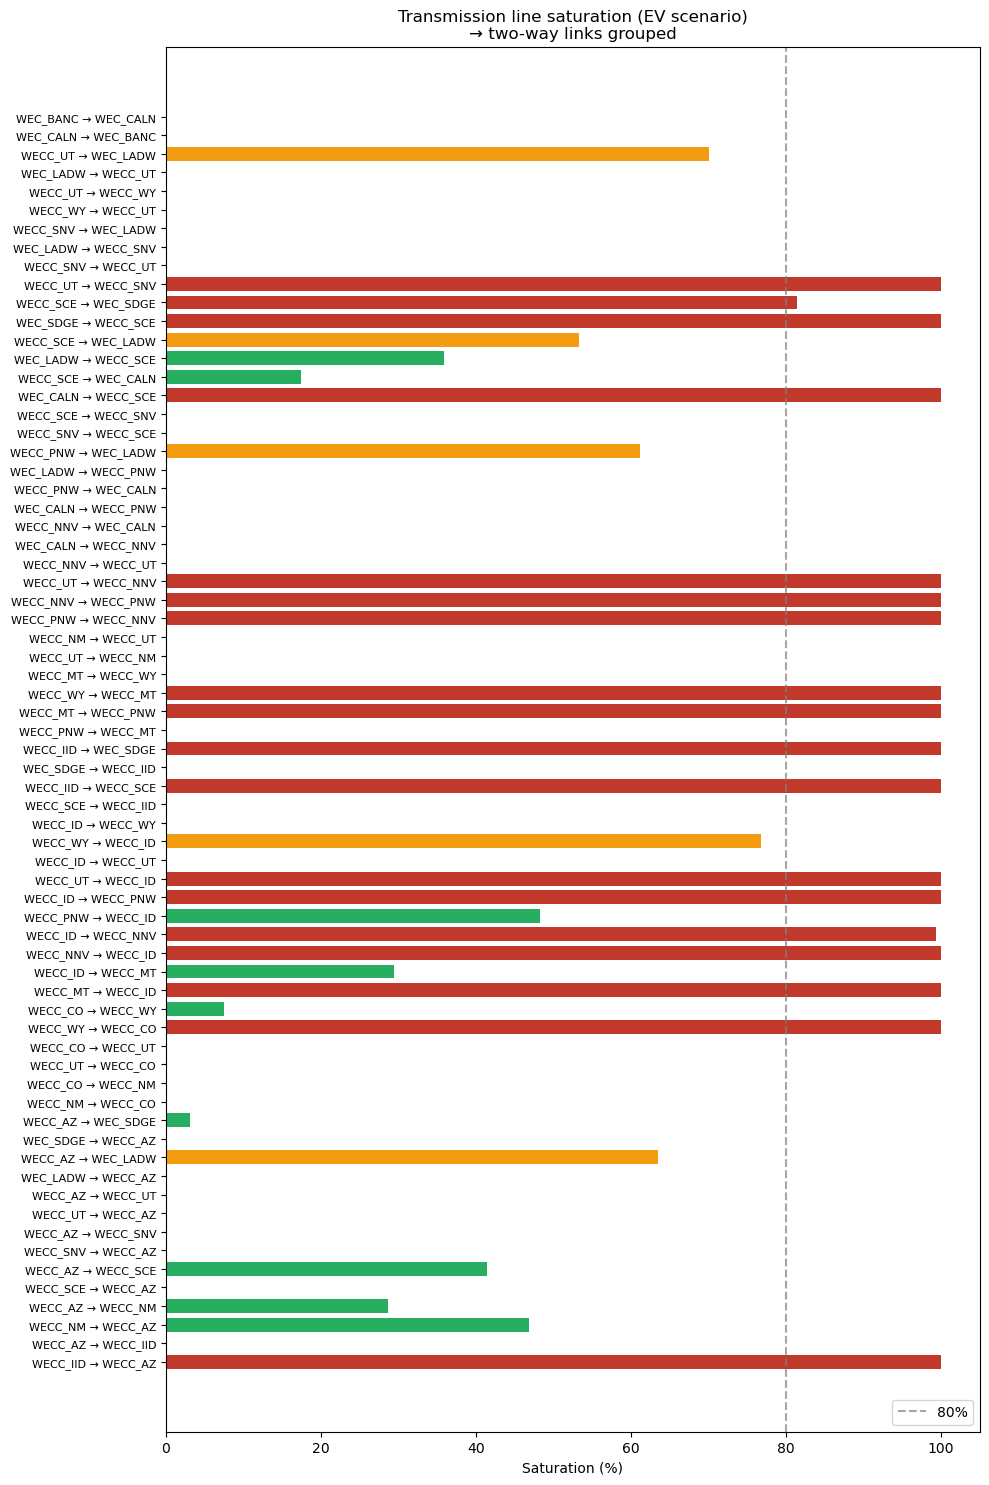

In [16]:
# Transmission line saturation check (after optimization)
# Uses the solution graph: for each transmission line, saturation = flow / capacity (max over time steps)

import numpy as np

def transmission_saturation(solution):
    """Compute per-line max flow, capacity, and saturation from a solution graph."""
    rows = []
    for source, target, edge_data in solution.edges(data=True):
        lines = edge_data.get('lines', {})
        for line_handle, line in lines.items():
            flow_vals = line.get('transmission', [])
            if not flow_vals:
                continue
            flow_arr = np.array(flow_vals, dtype=float)
            cap_installed = float(line.get('installed_capacity', 0) or 0)
            capex = line.get('capex', 0)
            if isinstance(capex, (list, np.ndarray)):
                capex = float(capex[0]) if len(capex) else 0
            else:
                capex = float(capex or 0)
            capacity = cap_installed + capex
            if capacity <= 0:
                sat = 0.0
                max_flow = float(flow_arr.max())
            else:
                max_flow = float(flow_arr.max())
                sat = max_flow / capacity
            rows.append({
                'source': source,
                'target': target,
                'line': line_handle,
                'capacity_MW': capacity / 1e6,
                'max_flow_MW': max_flow / 1e6,
                'saturation': sat,
            })
    return rows

# EV scenario (most recent solve)
print("=" * 70)
print("TRANSMISSION LINE SATURATION (EV scenario)")
print("=" * 70)
ev_rows = transmission_saturation(ev_solution)
if not ev_rows:
    print("No transmission lines found in solution.")
else:
    # Group two-way transmission: sort by (min(s,t), max(s,t)) then by target
    # so e.g. WECC_NM->WECC_CO appears right above WECC_CO->WECC_NM
    ev_rows.sort(key=lambda r: (min(r['source'], r['target']), max(r['source'], r['target']), r['target']))
    print(f"\nTotal lines: {len(ev_rows)} (two-way links grouped)")
    print(f"{'From':<14} {'To':<14} {'Line':<20} {'Capacity (MW)':>14} {'Max flow (MW)':>14} {'Saturation':>10}")
    print("-" * 70)
    for r in ev_rows:
        print(f"{r['source']:<14} {r['target']:<14} {r['line']:<20} {r['capacity_MW']:>14.2f} {r['max_flow_MW']:>14.2f} {r['saturation']:>9.1%}")
    # Summary: lines at or above 80% saturation
    high = [r for r in ev_rows if r['saturation'] >= 0.80]
    if high:
        print(f"\nLines at >= 80% saturation: {len(high)}")
    print("=" * 70)

    # Visualization: horizontal bar chart of saturation
    import matplotlib.pyplot as plt
    # Order for plot: same grouped order (two-way together), then by saturation for readability
    plot_rows = sorted(ev_rows, key=lambda r: (min(r['source'], r['target']), max(r['source'], r['target']), r['target']))
    labels = [f"{r['source']} \u2192 {r['target']}" for r in plot_rows]
    sats = [r['saturation'] for r in plot_rows]
    colors = ['#c0392b' if s >= 0.80 else '#f39c12' if s >= 0.50 else '#27ae60' for s in sats]  # red / amber / green
    fig, ax = plt.subplots(figsize=(10, max(6, len(plot_rows) * 0.22)))
    y_pos = np.arange(len(labels))
    bars = ax.barh(y_pos, [s * 100 for s in sats], color=colors, height=0.75)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel("Saturation (%)")
    ax.set_title("Transmission line saturation (EV scenario)\n\u2192 two-way links grouped")
    ax.set_xlim(0, 105)
    ax.axvline(80, color='gray', linestyle='--', alpha=0.7, label='80%')
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

## California vs WECC Generation and Emissions

We next compute and plot generation and emissions broken out for **California only**
versus the **entire WECC system**.

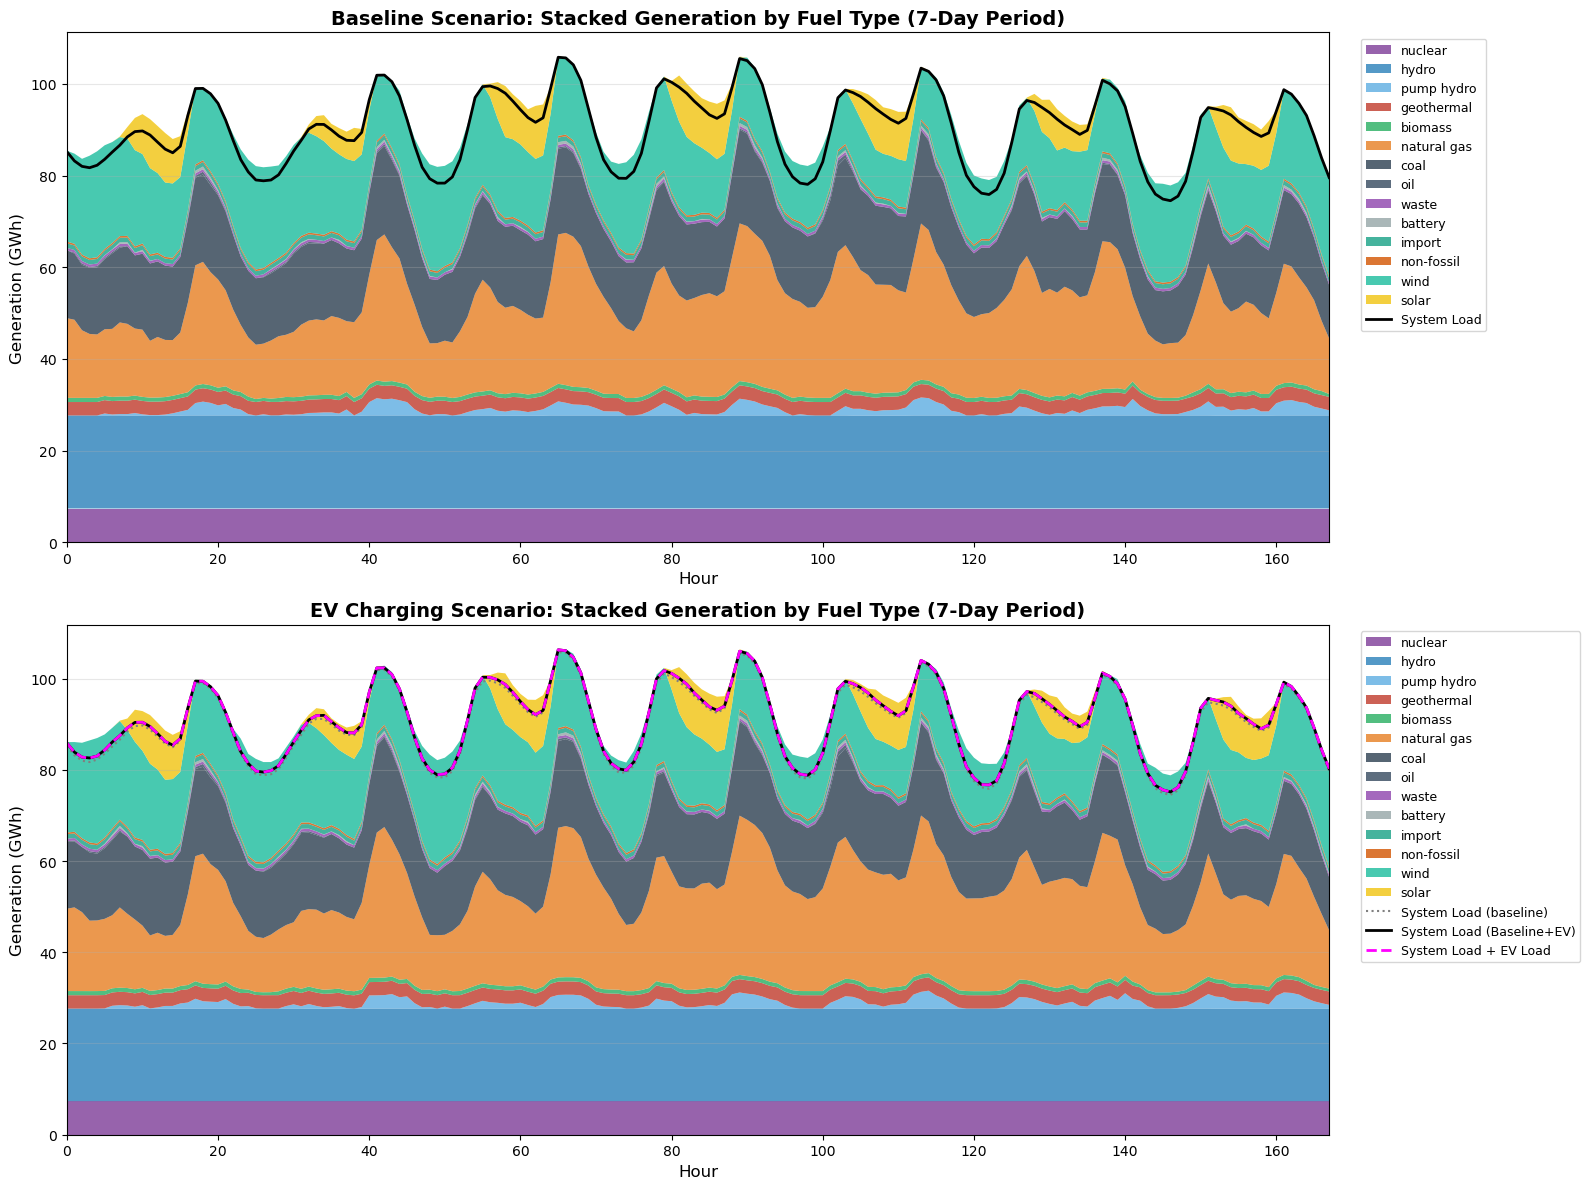

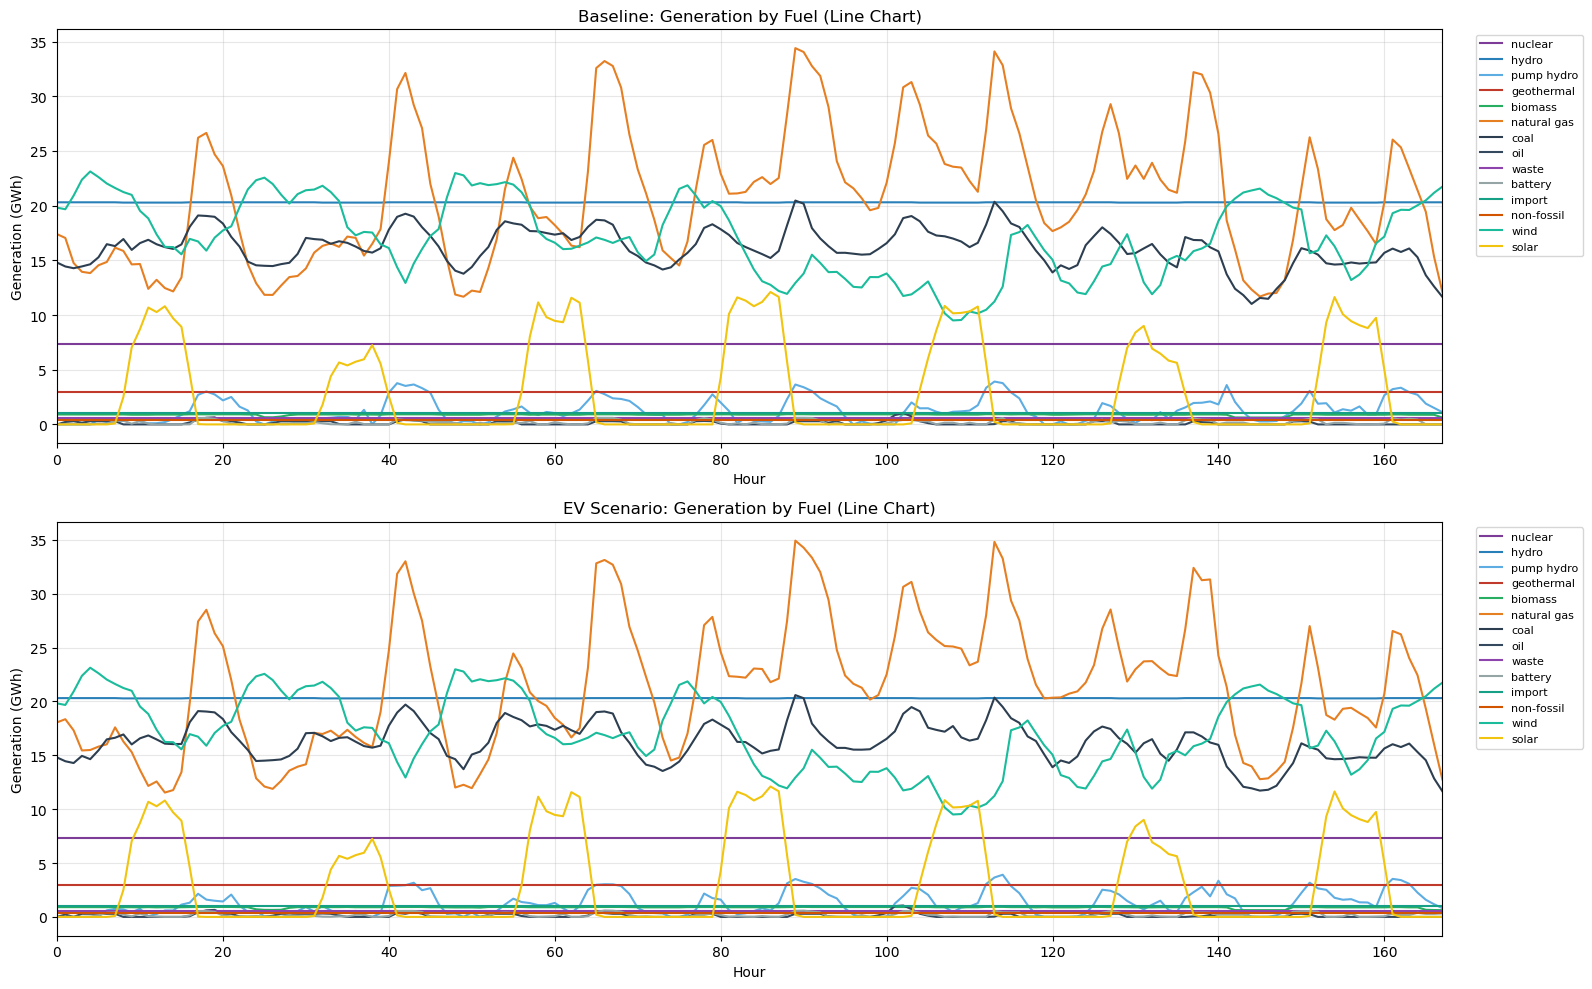

Storage in data (baseline): battery GWh = 26.87337874104 , pump hydro GWh = 208.73544380319998
Storage in data (EV):       battery GWh = 27.95035896842 , pump hydro GWh = 208.7223448648015

--- Store (battery/pump hydro) diagnostic ---
  WECC_AZ / installed_1054 (fuel=battery): net sum=0.0000 GW (1h equiv), discharge GWh=0.5100, max(net)=10.0000 MW
  WECC_AZ / installed_1465 (fuel=pump hydro): net sum=-0.0000 GW (1h equiv), discharge GWh=7.1240, max(net)=119.0000 MW
  WECC_AZ / installed_1501 (fuel=pump hydro): net sum=-0.0000 GW (1h equiv), discharge GWh=3.5910, max(net)=57.3000 MW
  WECC_AZ / installed_12055 (fuel=battery): net sum=-0.0000 GW (1h equiv), discharge GWh=0.5200, max(net)=10.0000 MW
  WECC_AZ / installed_15762 (fuel=battery): net sum=-0.0000 GW (1h equiv), discharge GWh=0.5300, max(net)=10.0000 MW
  WECC_AZ / installed_15907 (fuel=battery): net sum=-0.0000 GW (1h equiv), discharge GWh=0.5300, max(net)=10.0000 MW
  WECC_AZ / installed_16945 (fuel=pump hydro): net sum=0.00

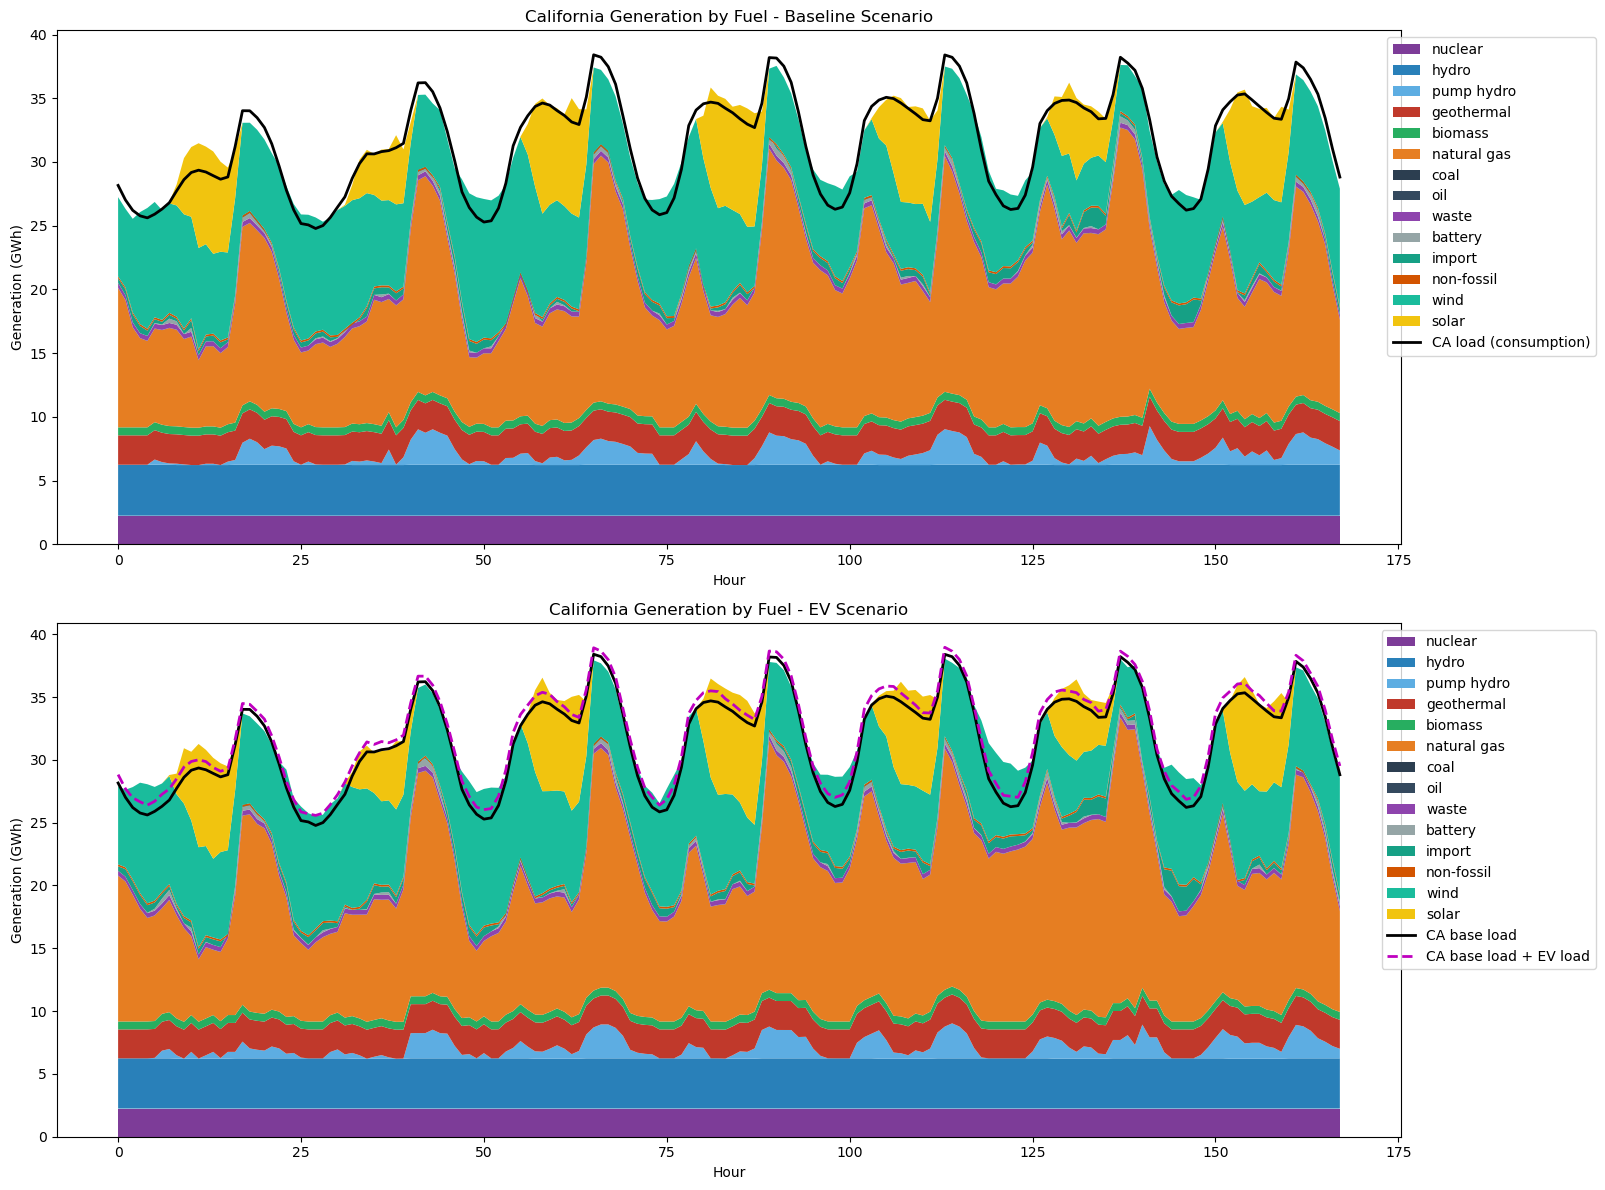

CALIFORNIA VS WECC CO2 EMISSIONS FROM EV LOAD
California marginal CO2: 43.10 million kg
WECC-wide marginal CO2: 56.59 million kg


In [44]:
# -- 1. Setup: Define or check key parameters, ensure everything is available before use --

# 2. Import statements (assume early in the file, but just in case)
import os
import numpy as np
import matplotlib.pyplot as plt

# 3. Ensure output directory exists
if 'output_dir' not in locals():
    output_dir = 'ev_charging_results'
    os.makedirs(output_dir, exist_ok=True)

# 4. Setup key region/capacity variables (if they are set elsewhere, fine; else try to set a fallback)
if "NUM_HOURS" in globals():
    NUM_HOURS_INT = NUM_HOURS
else:
    NUM_HOURS_INT = 168  # fallback, should match data

if "CALIFORNIA_REGIONS" in globals():
    CAL_REGIONS_SET = set(CALIFORNIA_REGIONS)
else:
    CAL_REGIONS_SET = set()  # fallback, will result in empty plots if not defined

# 5. Helper functions for CA analysis (define early so we can use them as soon as they're needed)
def get_ca_net_import_hourly(solution, cal_regions):
    """Net import and export into California (W) per hour."""
    cal = set(cal_regions)
    import_hourly = np.zeros(NUM_HOURS_INT)
    export_hourly = np.zeros(NUM_HOURS_INT)
    if not hasattr(solution, '_adj'):
        return import_hourly, export_hourly
    for source in solution._adj:
        for target, edge_data in solution._adj[source].items():
            if 'lines' not in edge_data:
                continue
            target_in_ca = target in cal
            source_in_ca = source in cal
            if target_in_ca and source_in_ca:
                continue  # skip CA-CA links
            for line_name, line_data in edge_data['lines'].items():
                trans = line_data.get('transmission', [])
                if not trans or len(trans) != NUM_HOURS_INT:
                    continue
                eff = line_data.get('efficiency', 1.0)
                trans_arr = np.array(trans)
                if target_in_ca and not source_in_ca:
                    import_hourly += trans_arr * eff
                elif source_in_ca and not target_in_ca:
                    export_hourly += trans_arr
    return import_hourly, export_hourly

def get_ca_load_hourly(solution, cal_regions):
    """Total load (W) per hour in California regions (from base_load assets only)."""
    cal = set(cal_regions)
    load_hourly = np.zeros(NUM_HOURS_INT)
    for source, node in solution._node.items():
        if source not in cal:
            continue
        for handle, asset in node.get('assets', {}).items():
            if 'base_load' not in handle.lower():
                continue
            net = asset.get('net', [])
            if net and len(net) == NUM_HOURS_INT:
                load_hourly += np.array(net)  # net is negative for load (consumption)
    return np.abs(load_hourly)  # positive consumption in W

def get_wecc_load_hourly(solution):
    """Total system load (W) per hour for all WECC regions (from base_load assets in solution)."""
    load_hourly = np.zeros(NUM_HOURS_INT)
    for source, node in solution._node.items():
        for handle, asset in node.get('assets', {}).items():
            if 'base_load' not in handle.lower():
                continue
            net = asset.get('net', [])
            if net and len(net) == NUM_HOURS_INT:
                load_hourly += np.abs(np.array(net))  # consumption in W (net is negative)
    return load_hourly

# 6. Confirm EV generation, baseline generation, and extraction are run before plotting or summarizing
if 'baseline_gen' not in globals() or 'ev_gen' not in globals():
    if 'extract_generation_by_fuel' not in globals():
        raise RuntimeError("Please run the cell that defines extract_generation_by_fuel (generation extraction) before this cell.")
    baseline_gen = extract_generation_by_fuel(baseline_solution, baseline_graph)
    ev_gen = extract_generation_by_fuel(ev_solution, ev_graph)

# 7. Aggregate generation by hour and fuel for both scenarios
baseline_hourly = baseline_gen.groupby(['hour', 'fuel'])['generation_kwh'].sum().reset_index()
ev_hourly = ev_gen.groupby(['hour', 'fuel'])['generation_kwh'].sum().reset_index()

# 8. Pivot to wide format for stacked area chart
baseline_pivot = baseline_hourly.pivot(index='hour', columns='fuel', values='generation_kwh').fillna(0)
ev_pivot = ev_hourly.pivot(index='hour', columns='fuel', values='generation_kwh').fillna(0)

# 9. Define fuel colors
fuel_colors = {
    'coal': '#2C3E50',
    'oil': '#34495E',
    'natural gas': '#E67E22',
    'waste': '#8E44AD',
    'geothermal': '#C0392B',
    'biomass': '#27AE60',
    'hydro': '#2980B9',
    'pump hydro': '#5DADE2',
    'nuclear': '#7D3C98',
    'wind': '#1ABC9C',
    'solar': '#F1C40F',
    'battery': '#95A5A6',
    'import': '#16A085',
    'non-fossil': '#D35400',
    'unknown': '#BDC3C7',
}

# 10. Get all fuels present in either scenario, ensure both dataframes have the same columns
all_fuels = sorted(set(baseline_pivot.columns.tolist() + ev_pivot.columns.tolist()))
for fuel in all_fuels:
    if fuel not in baseline_pivot.columns:
        baseline_pivot[fuel] = 0
    if fuel not in ev_pivot.columns:
        ev_pivot[fuel] = 0

# 11. Fuel order for plotting; fill in any extras found in the run
fuel_order = [
    'nuclear',
    'hydro', 'pump hydro', 'geothermal', 'biomass',
    'natural gas', 'coal', 'oil', 'waste',
    'battery', 'import', 'non-fossil', 'unknown',
    'wind', 'solar',
]
fuel_order = [f for f in fuel_order if f in all_fuels]
for fuel in all_fuels:
    if fuel not in fuel_order:
        fuel_order.append(fuel)

baseline_pivot = baseline_pivot[fuel_order]
ev_pivot = ev_pivot[fuel_order]

# 12. Convert to GWh for plotting
baseline_pivot_gwh = baseline_pivot / 1e6
ev_pivot_gwh = ev_pivot / 1e6

# --- Pre-compute load and EV load curves for system-wide (WECC) plots ---
# Load must come from the solution (base_load assets); extract_generation_by_fuel skips Load assets so baseline_gen/ev_gen have no consumption rows
baseline_load_hr = get_wecc_load_hourly(baseline_solution) / 1e9   # W -> GW
ev_total_load_hr = get_wecc_load_hourly(ev_solution) / 1e9         # W -> GW

if 'ev_charging_load' in globals() and len(ev_charging_load) == NUM_HOURS_INT:
    ev_load_hr = np.array(ev_charging_load) / 1e9  # W to GW
else:
    ev_load_hr = np.zeros(NUM_HOURS_INT)

hours = np.arange(NUM_HOURS_INT)

# 13. Plot all-generation stacked area chart (WECC total) WITH LOAD CURVES ADDED
fig, axes = plt.subplots(2, 1, figsize=(16, 12))
colors_list = [fuel_colors.get(fuel, '#CCCCCC') for fuel in fuel_order]

# ----- BASELINE scenario -----
ax1 = axes[0]
ax1.stackplot(
    baseline_pivot_gwh.index,
    [baseline_pivot_gwh[fuel] for fuel in fuel_order],
    labels=fuel_order,
    colors=colors_list,
    alpha=0.8
)
# Add baseline load curve (black line, matches time axis)
ax1.plot(hours, baseline_load_hr, 'k-', lw=2, label='System Load')
ax1.set_xlabel('Hour', fontsize=12)
ax1.set_ylabel('Generation (GWh)', fontsize=12)
ax1.set_title('Baseline Scenario: Stacked Generation by Fuel Type (7-Day Period)', 
              fontsize=14, fontweight='bold')
# Show legend with both areas and lines
ax1.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=9, ncol=1)
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_xlim(0, len(baseline_pivot_gwh) - 1)

# ----- EV scenario -----
ax2 = axes[1]
ax2.stackplot(
    ev_pivot_gwh.index,
    [ev_pivot_gwh[fuel] for fuel in fuel_order],
    labels=fuel_order,
    colors=colors_list,
    alpha=0.8
)
# -- Always plot: baseline system load, EV run's total system load, and system load + EV charging as dashed magenta --
# Plot base (non-EV) load in dotted gray
ax2.plot(hours, baseline_load_hr, color='gray', lw=1.5, ls=':', label='System Load (baseline)')
# Plot total system load in EV scenario (should include baseline + EV charging)
ax2.plot(hours, ev_total_load_hr, 'k-', lw=2, label='System Load (Baseline+EV)')
# Plot load + EV charging (EV charging isolated; magenta dashed)
ax2.plot(hours, baseline_load_hr + ev_load_hr, color='magenta', lw=2, ls='--', label='System Load + EV Load')
ax2.set_xlabel('Hour', fontsize=12)
ax2.set_ylabel('Generation (GWh)', fontsize=12)
ax2.set_title('EV Charging Scenario: Stacked Generation by Fuel Type (7-Day Period)', 
              fontsize=14, fontweight='bold')
ax2.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=9, ncol=1)
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_xlim(0, len(ev_pivot_gwh) - 1)

plt.tight_layout()
plt.savefig(f'{output_dir}/stacked_generation_by_scenario.png', dpi=150, bbox_inches='tight')
plt.show()

# 13b. Line chart (no stacking): each fuel as a line to see battery/pump hydro and small fuels
fig2, axes2 = plt.subplots(2, 1, figsize=(16, 10))
for fuel in fuel_order:
    axes2[0].plot(hours, baseline_pivot_gwh[fuel], color=fuel_colors.get(fuel, '#CCCCCC'), label=fuel, lw=1.5)
axes2[0].set_xlabel('Hour')
axes2[0].set_ylabel('Generation (GWh)')
axes2[0].set_title('Baseline: Generation by Fuel (Line Chart)')
axes2[0].legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=8)
axes2[0].grid(True, alpha=0.3)
axes2[0].set_xlim(0, NUM_HOURS_INT - 1)
for fuel in fuel_order:
    axes2[1].plot(hours, ev_pivot_gwh[fuel], color=fuel_colors.get(fuel, '#CCCCCC'), label=fuel, lw=1.5)
axes2[1].set_xlabel('Hour')
axes2[1].set_ylabel('Generation (GWh)')
axes2[1].set_title('EV Scenario: Generation by Fuel (Line Chart)')
axes2[1].legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=8)
axes2[1].grid(True, alpha=0.3)
axes2[1].set_xlim(0, NUM_HOURS_INT - 1)
plt.tight_layout()
plt.savefig(f'{output_dir}/generation_by_fuel_lines.png', dpi=150, bbox_inches='tight')
plt.show()

# Print battery and pump hydro totals to diagnose visibility
print('Storage in data (baseline): battery GWh =', baseline_pivot_gwh['battery'].sum(), ', pump hydro GWh =', baseline_pivot_gwh['pump hydro'].sum())
print('Storage in data (EV):       battery GWh =', ev_pivot_gwh['battery'].sum(), ', pump hydro GWh =', ev_pivot_gwh['pump hydro'].sum())

# 13c. Diagnose why battery/pump hydro are zero: check Store assets in solution vs graph
print('\n--- Store (battery/pump hydro) diagnostic ---')
gr_check = baseline_graph if 'baseline_graph' in dir() else None
sol_check = baseline_solution if 'baseline_solution' in dir() else None
if gr_check is None or sol_check is None:
    print('  baseline_graph or baseline_solution not available.')
else:
    store_count_in_graph = 0
    store_count_in_solution = 0
    total_discharge_gwh_all = 0.0
    for source, node in gr_check._node.items():
        for handle, asset in node.get('assets', {}).items():
            if asset.get('_class') == 'Store':
                store_count_in_graph += 1
                fuel = asset.get('fuel', 'unknown')
                sol_node = sol_check._node.get(source, {})
                sol_assets = sol_node.get('assets', {})
                if handle not in sol_assets:
                    print(f'  Store in graph but NOT in solution: {source} / {handle} (fuel={fuel})')
                    continue
                store_count_in_solution += 1
                net = sol_assets[handle].get('net', [])
                if not net or len(net) == 0:
                    print(f'  Store in solution but no net: {source} / {handle}')
                    continue
                net_arr = np.array(net)
                discharge_only = np.maximum(net_arr, 0)
                total_net = net_arr.sum()
                total_discharge_gwh = discharge_only.sum() * 3600 / 3.6e12  # W*1h -> GWh
                total_discharge_gwh_all += total_discharge_gwh
                print(f'  {source} / {handle} (fuel={fuel}): net sum={total_net/1e9:.4f} GW (1h equiv), discharge GWh={total_discharge_gwh:.4f}, max(net)={net_arr.max()/1e6:.4f} MW')
    if store_count_in_graph == 0:
        print('  No Store assets found in baseline_graph. Check that graph has _class="Store" assets.')
    elif store_count_in_solution == 0:
        print('  Store assets in graph but none found in solution (handle mismatch or solution not built from same graph).')
    elif store_count_in_solution > 0 and total_discharge_gwh_all == 0:
        print('  All Store assets have zero discharge (net <= 0 every hour). Optimizer did not use storage.')
print('---')

# 14. Print summary statistics
print("=" * 60)
print("GENERATION SUMMARY BY SCENARIO")
print("=" * 60)
print("\nBaseline Scenario - Total Generation by Fuel:")
baseline_totals = baseline_pivot_gwh.sum().sort_values(ascending=False)
for fuel, total in baseline_totals.items():
    if abs(total) > 0.01:  # Only show significant values
        print(f"  {fuel:20s}: {total:10.2f} GWh")

print("\nEV Charging Scenario - Total Generation by Fuel:")
ev_totals = ev_pivot_gwh.sum().sort_values(ascending=False)
for fuel, total in ev_totals.items():
    if abs(total) > 0.01:  # Only show significant values
        print(f"  {fuel:20s}: {total:10.2f} GWh")

print("\n" + "=" * 60)
print(f"Baseline Total: {baseline_pivot_gwh.sum().sum():.2f} GWh")
print(f"EV Scenario Total: {ev_pivot_gwh.sum().sum():.2f} GWh")
print(f"Difference: {(ev_pivot_gwh.sum().sum() - baseline_pivot_gwh.sum().sum()):.2f} GWh")
print("=" * 60)

# 15. Print total baseline shortfall
total_shortfall_ws = 0
if "baseline_solution" in globals():
    for region, node in baseline_solution._node.items():
        short = node.get('shortfall', [])
        if short:
            total_shortfall_ws += sum(short)
    print("Total shortfall (baseline) [GWh]:", total_shortfall_ws / 3.6e12)
else:
    print("Total shortfall (baseline) [GWh]: (baseline_solution not available)")

# 15b. Storage vs shortfall: how the model works
# In the good model, each region has balance: asset_net_energy + imports - exports + shortfall - wastage = 0.
# Store assets contribute to asset_net_energy (discharge adds, charge subtracts). So storage DOES compensate
# for shortfall when the optimizer chooses to discharge. We report only net discharge as 'battery'/'pump hydro'
# generation (charging is consumption, not generation). If shortfall is still high, storage may be limited
# by capacity/energy or the optimizer may prefer shortfall in some hours.
if 'baseline_gen' in globals() and 'baseline_solution' in globals():
    storage_fuels = ['battery', 'pump hydro']
    base_storage_gwh = baseline_gen[baseline_gen['fuel'].isin(storage_fuels)]['generation_kwh'].sum() / 1e6
    ev_storage_gwh = ev_gen[ev_gen['fuel'].isin(storage_fuels)]['generation_kwh'].sum() / 1e6
    total_shortfall_baseline_gwh = sum(sum(node.get('shortfall', [])) for node in baseline_solution._node.values()) / 3.6e12
    print("\nStorage discharge (baseline): {:.2f} GWh  |  Shortfall (baseline): {:.2f} GWh".format(base_storage_gwh, total_shortfall_baseline_gwh))
    print("Storage discharge (EV scenario): {:.2f} GWh".format(ev_storage_gwh))

# 16. California Region Generation and Imports/Exports
import_baseline_W, export_baseline_W = get_ca_net_import_hourly(baseline_solution, CALIFORNIA_REGIONS)
import_ev_W, export_ev_W = get_ca_net_import_hourly(ev_solution, CALIFORNIA_REGIONS)
net_import_baseline_W = import_baseline_W - export_baseline_W
net_import_ev_W = import_ev_W - export_ev_W
ca_load_baseline_W = get_ca_load_hourly(baseline_solution, CALIFORNIA_REGIONS)
ca_load_ev_W = get_ca_load_hourly(ev_solution, CALIFORNIA_REGIONS)
if 'ev_charging_load' in globals() and len(ev_charging_load) == NUM_HOURS_INT:
    ev_load_W = np.array(ev_charging_load)
else:
    ev_load_W = np.zeros(NUM_HOURS_INT)

# Prepare CA region generation DataFrames
baseline_gen_ca = baseline_gen[baseline_gen['region'].isin(CAL_REGIONS_SET)].copy()
ev_gen_ca = ev_gen[ev_gen['region'].isin(CAL_REGIONS_SET)].copy()
baseline_hourly_ca = baseline_gen_ca.groupby(['hour', 'fuel'])['generation_kwh'].sum().reset_index()
ev_hourly_ca = ev_gen_ca.groupby(['hour', 'fuel'])['generation_kwh'].sum().reset_index()

baseline_pivot_ca = baseline_hourly_ca.pivot(index='hour', columns='fuel', values='generation_kwh').fillna(0)
ev_pivot_ca = ev_hourly_ca.pivot(index='hour', columns='fuel', values='generation_kwh').fillna(0)

# Add net import to CA pivot
baseline_pivot_ca['import'] = net_import_baseline_W / 1000.0  # W to kWh
ev_pivot_ca['import'] = net_import_ev_W / 1000.0

# Build consistent fuel ordering for CA view
all_fuels_ca = sorted(set(baseline_pivot_ca.columns.tolist() + ev_pivot_ca.columns.tolist()))
for fuel in all_fuels_ca:
    if fuel not in baseline_pivot_ca.columns:
        baseline_pivot_ca[fuel] = 0
    if fuel not in ev_pivot_ca.columns:
        ev_pivot_ca[fuel] = 0

# Use fuel_order if available for CA, or just list as they appear
if 'fuel_order' in locals():
    fuel_order_ca = [f for f in fuel_order if f in all_fuels_ca]
    if 'import' not in fuel_order_ca:
        fuel_order_ca.append('import')
    for f in all_fuels_ca:
        if f not in fuel_order_ca:
            fuel_order_ca.append(f)
else:
    fuel_order_ca = all_fuels_ca if 'import' in all_fuels_ca else all_fuels_ca + ['import']

baseline_pivot_ca = baseline_pivot_ca[fuel_order_ca]
ev_pivot_ca = ev_pivot_ca[fuel_order_ca]

# Convert CA gen to GWh
baseline_pivot_ca_gwh = baseline_pivot_ca / 1e6
ev_pivot_ca_gwh = ev_pivot_ca / 1e6

# -- Prepare plotting for CA --
fig, axes = plt.subplots(2, 1, figsize=(16, 12))
colors_list_ca = [fuel_colors.get(fuel, '#CCCCCC') for fuel in fuel_order_ca]
hours = np.arange(NUM_HOURS_INT)
ca_load_baseline_gwh_hr = ca_load_baseline_W / 1e9
ev_load_gwh_hr = ev_load_W / 1e9

# Plot baseline scenario for California
ax1 = axes[0]
ax1.stackplot(
    baseline_pivot_ca_gwh.index,
    [baseline_pivot_ca_gwh[f] for f in fuel_order_ca],
    labels=fuel_order_ca,
    colors=colors_list_ca,
)
ax1.plot(hours, ca_load_baseline_gwh_hr, 'k-', lw=2, label='CA load (consumption)')
ax1.set_title('California Generation by Fuel - Baseline Scenario')
ax1.set_xlabel('Hour')
ax1.set_ylabel('Generation (GWh)')
ax1.legend(loc='upper right', bbox_to_anchor=(1.15, 1.0))

# Plot EV scenario for California
ax2 = axes[1]
ax2.stackplot(
    ev_pivot_ca_gwh.index,
    [ev_pivot_ca_gwh[f] for f in fuel_order_ca],
    labels=fuel_order_ca,
    colors=colors_list_ca,
)
# For the EV run, show the CA base load and "base load + EV" as two lines
ax2.plot(hours, ca_load_baseline_gwh_hr, 'k-', lw=2, label='CA base load')
ax2.plot(hours, ca_load_baseline_gwh_hr + ev_load_gwh_hr, 'm--', lw=2, label='CA base load + EV load')
ax2.set_title('California Generation by Fuel - EV Scenario')
ax2.set_xlabel('Hour')
ax2.set_ylabel('Generation (GWh)')
ax2.legend(loc='upper right', bbox_to_anchor=(1.15, 1.0))

plt.tight_layout()
plt.show()

# 17. California vs WECC emissions comparison --
marginal_df = globals().get('marginal_df')
if marginal_df is not None and isinstance(marginal_df, pd.DataFrame):
    ca_marginal = marginal_df[marginal_df['region'].isin(CAL_REGIONS_SET)].copy()
    wecc_marginal = marginal_df.copy()
    ca_total_co2 = ca_marginal['co2_emissions_kg'].sum() / 1e6  # million kg
    wecc_total_co2 = wecc_marginal['co2_emissions_kg'].sum() / 1e6

    print("=" * 60)
    print("CALIFORNIA VS WECC CO2 EMISSIONS FROM EV LOAD")
    print("=" * 60)
    print(f"California marginal CO2: {ca_total_co2:.2f} million kg")
    print(f"WECC-wide marginal CO2: {wecc_total_co2:.2f} million kg")
    print("=" * 60)
else:
    print("\nMarginal emissions DataFrame ('marginal_df') not found. Run the marginal emissions / extraction cell first.")

CALIFORNIA ENERGY BALANCE DIAGNOSTIC (Baseline)
  Load:              5308.02 GW·h
  Producer gen:      5271.93 GW·h
  Storage discharge: 165.7716 GW·h
  Storage charge:    165.7716 GW·h
  Gross imports:     81.08 GW·h
  Gross exports:     26.86 GW·h
  Shortfall:         0.0000 GW·h
  Wastage:           8.8420 GW·h
  Balance residual:  9.285345 GW·h (should be ~0)

What the CA chart stacks:  gen + discharge_only + net_import
What actually serves load: gen + (discharge - charge) + net_import + shortfall - wastage
  Chart gap = shortfall - wastage + charge = 0.0000 - 8.8420 + 165.7716 GW·h
  => Chart total will be ABOVE load by 165.7716 GW·h (hidden charging)
     and BELOW load by 0.0000 GW·h (unmet demand)

Hours where CA is net exporter: 40/168
  Max net export: 0.163 GW
  These hours add NEGATIVE values to the 'import' stack, causing visual artifacts

Storage assets in California:
  WEC_SDGE/installed_11867 (battery): cap=2.5 MW, max_prod=2.5000 MW, max_cons=2.5000 MW, discharge=0.122

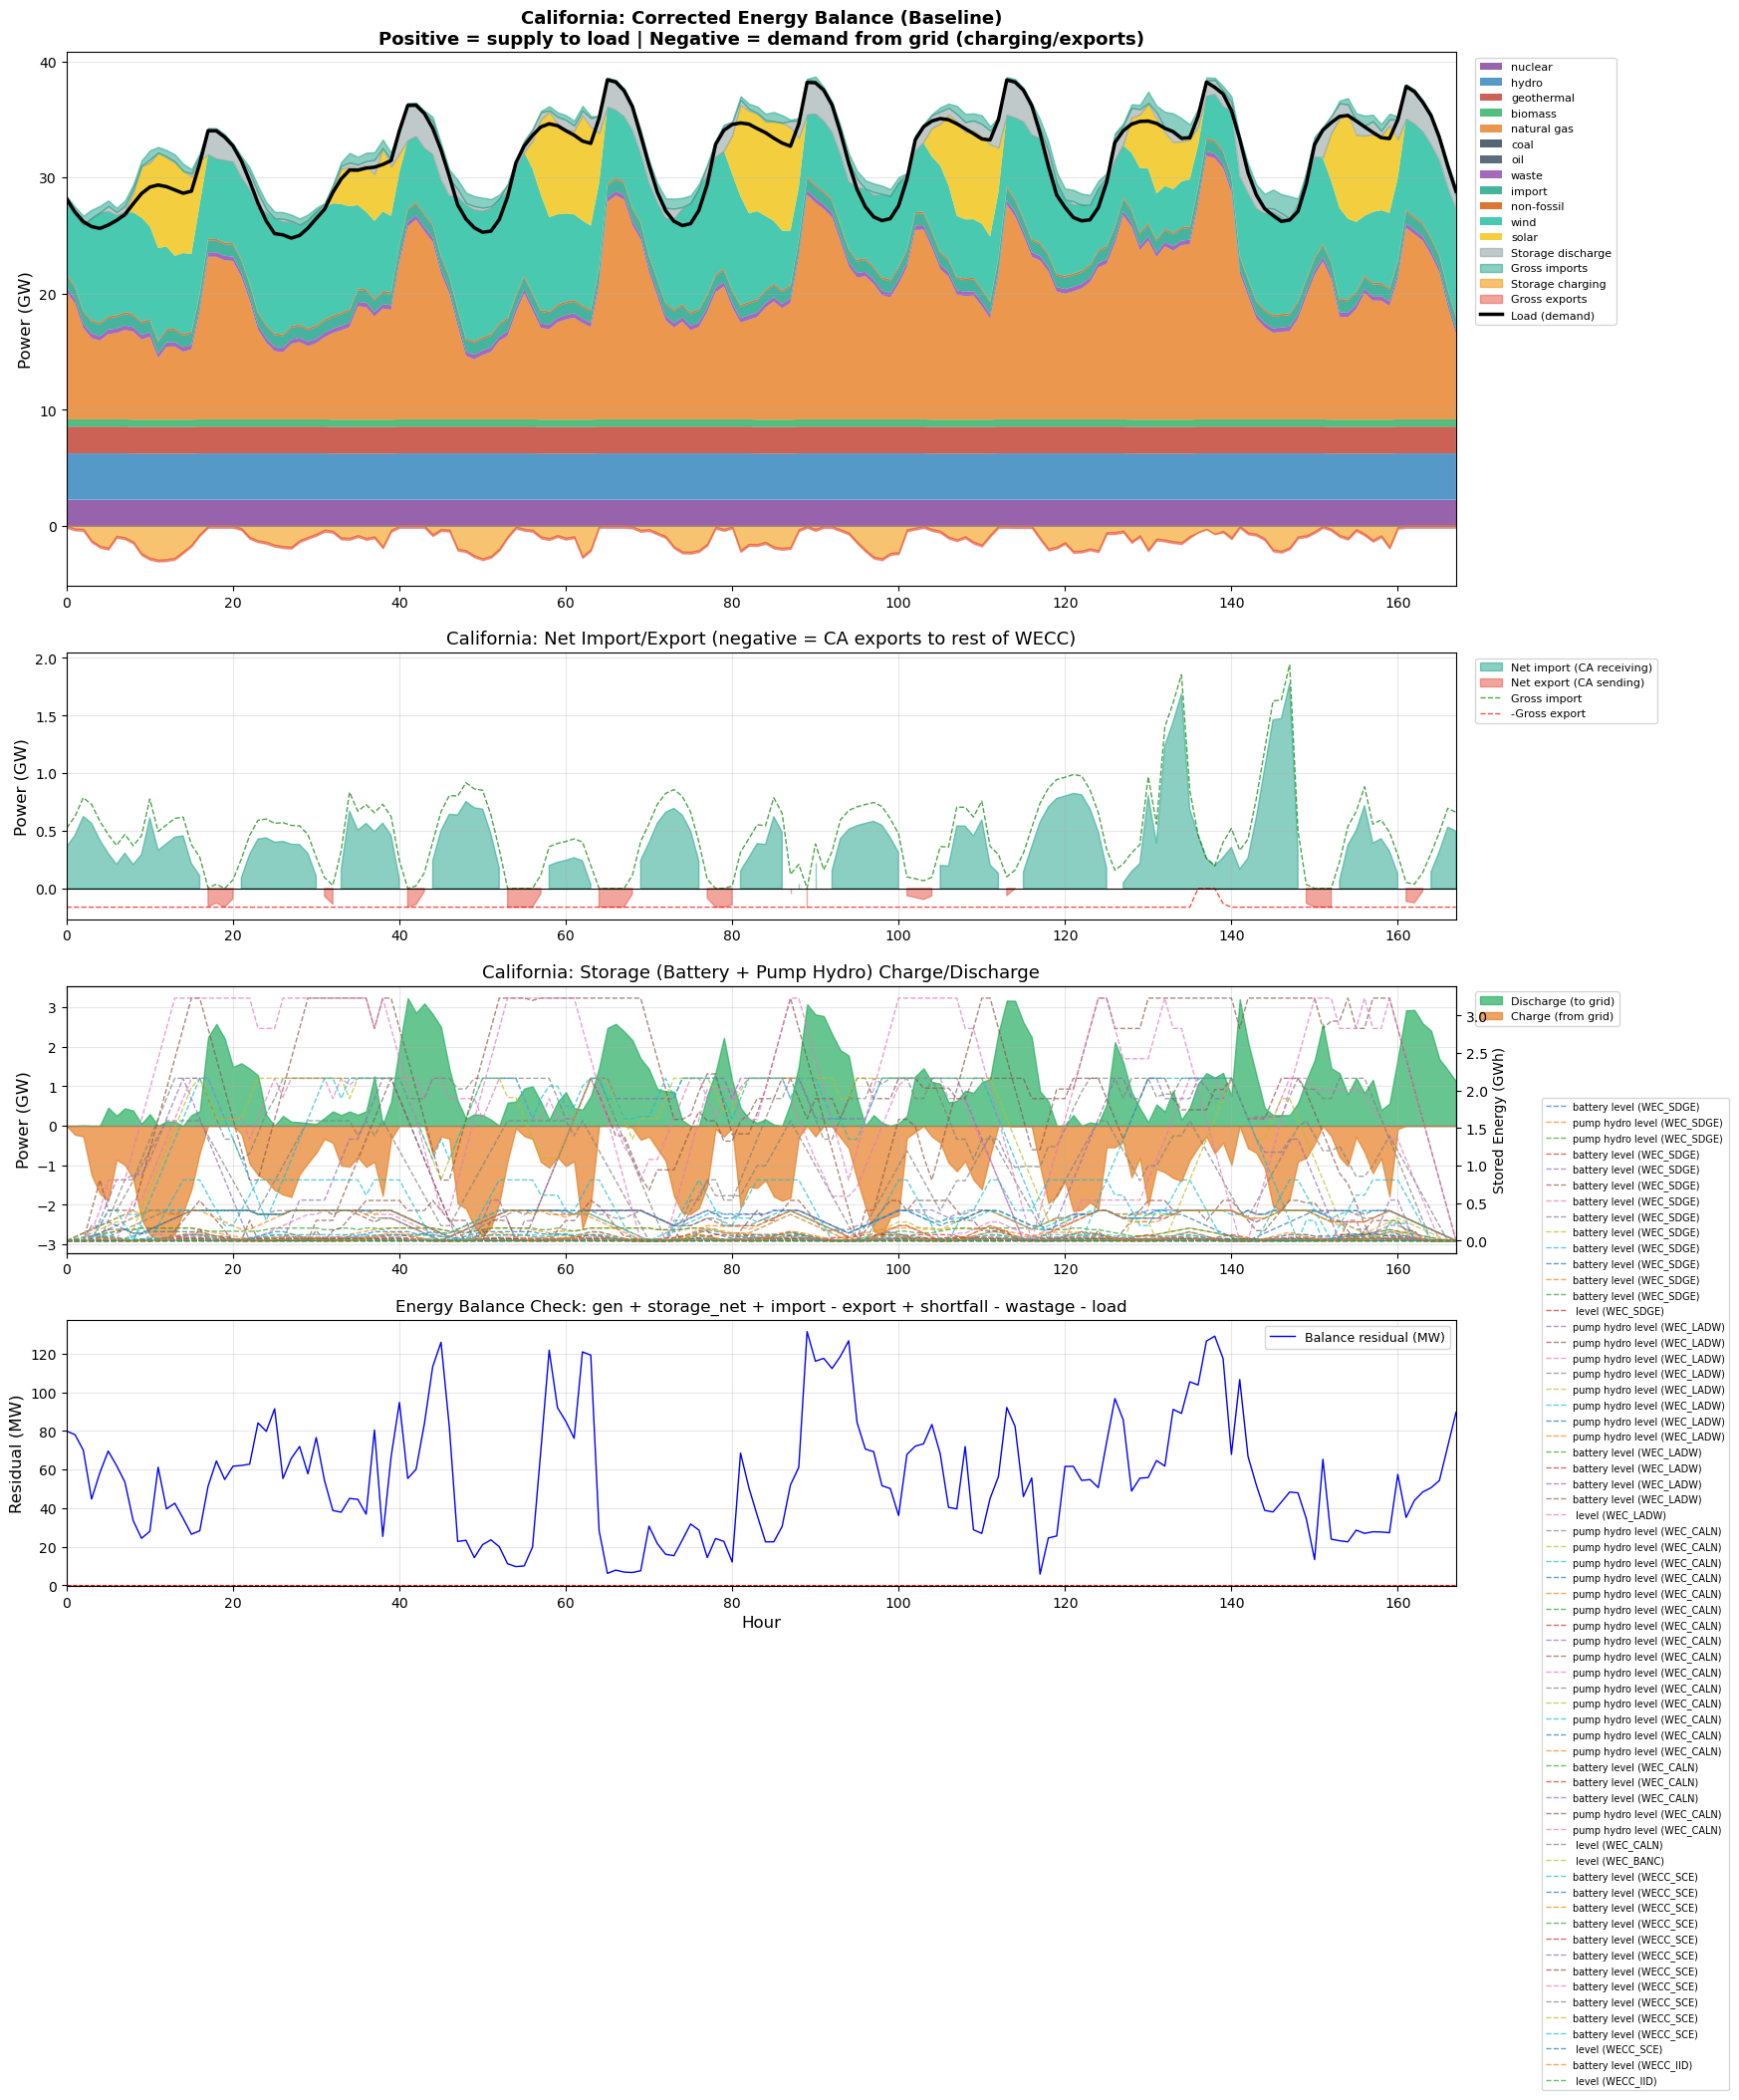

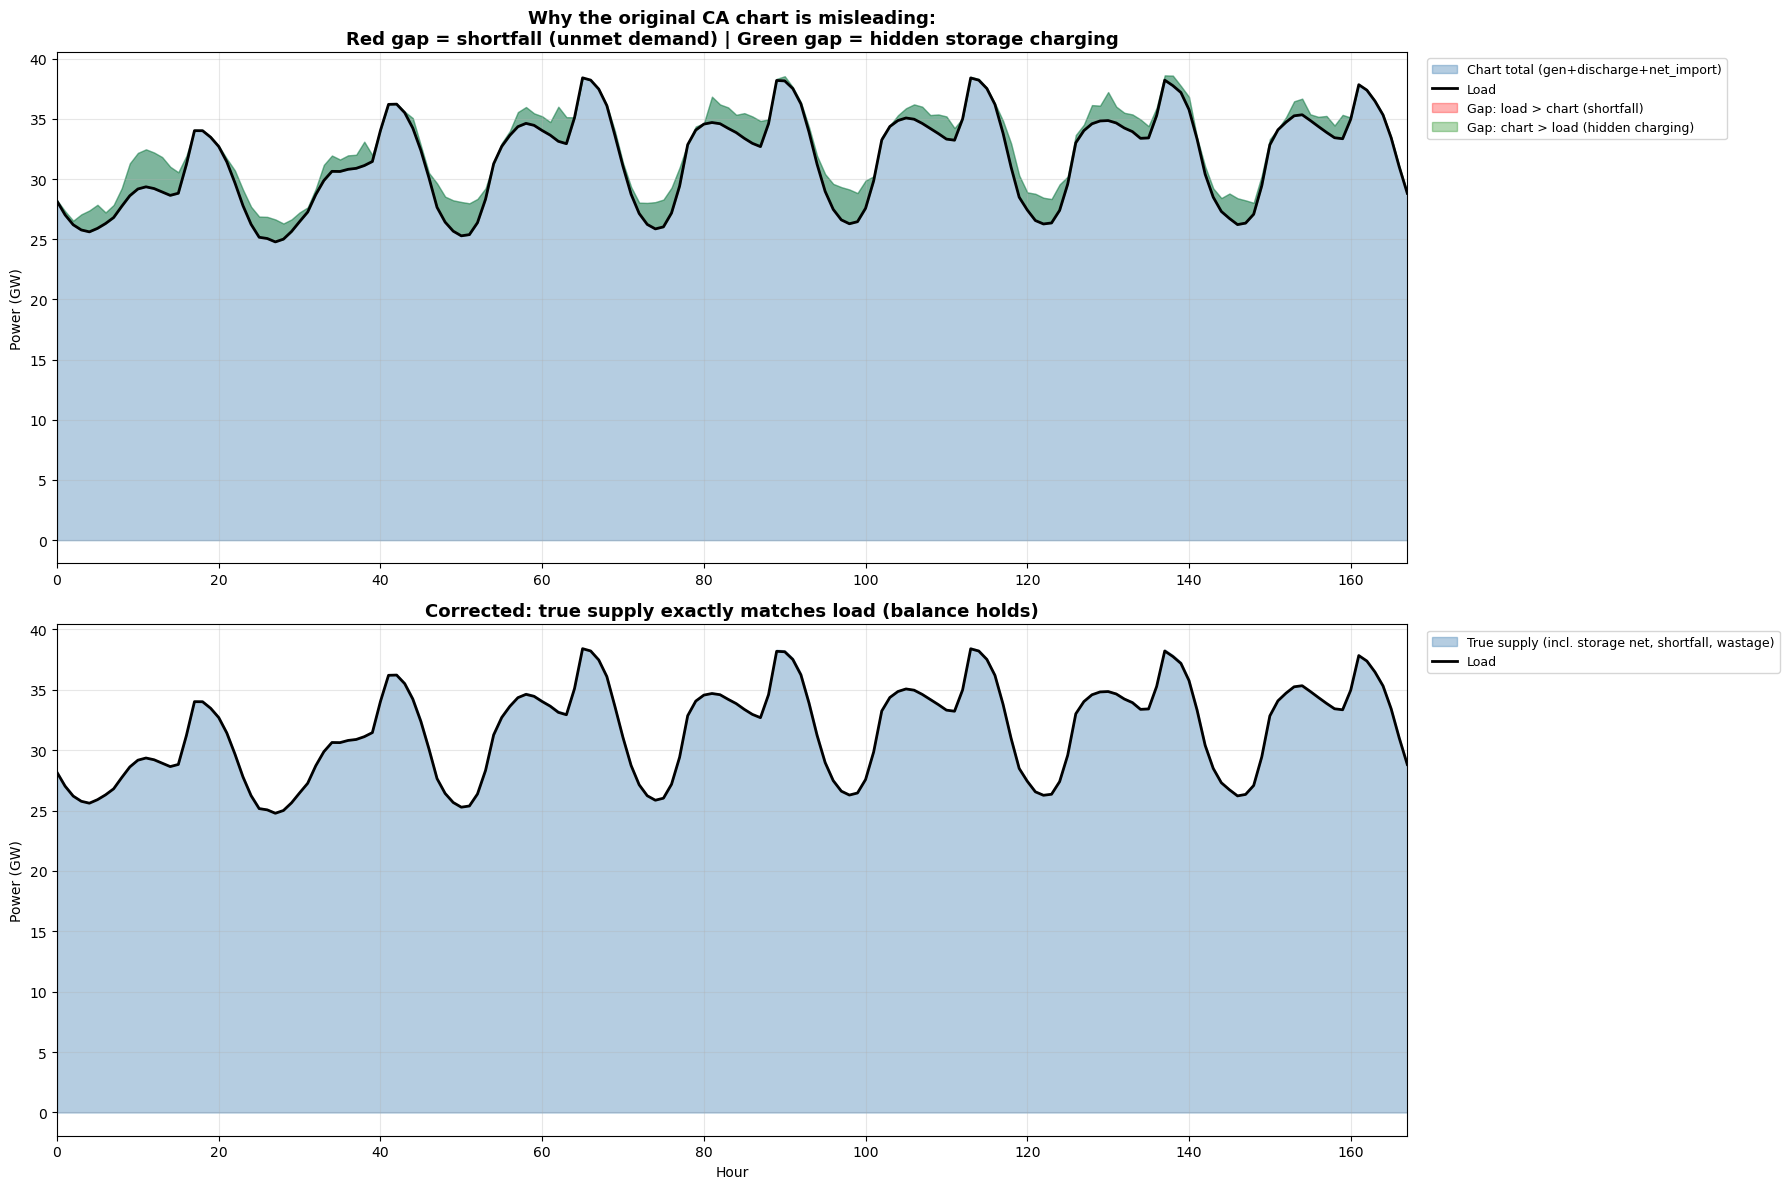


DIAGNOSIS SUMMARY

1. LOAD vs GENERATION MISMATCH (original chart):
   The original CA stacked chart shows: producer_gen + discharge_only + net_import.
   This does NOT match load because:
   - Storage CHARGING is hidden (consumption from grid not shown as negative)
   - SHORTFALL is not shown (unmet demand creates a gap below load)
   - WASTAGE is not shown (excess supply above load)
   => When chart > load: hidden storage charging is inflating the total
   => When chart < load: shortfall (unmet demand) in some CA regions

2. BATTERY ZERO DISPATCH:
   Batteries have near-zero dispatch because of the storage_duration bug
   (installed_capacity in Watts was used as energy capacity in Watt-seconds,
   making usable storage ~14,400x too small). The fix in store.py adds
   storage_duration to correctly convert power to energy capacity.
   Additionally, the RPS hard constraint (non_compliance_capacity=0) may
   prevent thermal generators from dispatching, leaving less incentive for
   stor

In [45]:
# =============================================================================
# DIAGNOSTIC: California Energy Balance, Storage, and Net Import Investigation
# =============================================================================
# This cell investigates why:
#   1) Load sometimes exceeds generation+imports (and vice versa) in the CA chart
#   2) Battery shows zero dispatch
#   3) Pump hydro only shows discharge (no charging visible)
#   4) Whether net imports are correctly calculated (can go negative during solar peak)
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt

CAL_SET = set(CALIFORNIA_REGIONS)
hours = np.arange(NUM_HOURS_INT)

# --- 1. Collect full energy balance components for all CA regions (baseline) ---
ca_load_W        = np.zeros(NUM_HOURS_INT)   # total load (positive = consumption)
ca_producer_W    = np.zeros(NUM_HOURS_INT)   # total producer generation
ca_store_discharge_W = np.zeros(NUM_HOURS_INT)  # storage discharge (positive net)
ca_store_charge_W    = np.zeros(NUM_HOURS_INT)  # storage charge (abs of negative net)
ca_shortfall_Ws  = np.zeros(NUM_HOURS_INT)   # shortfall (W-s, energy)
ca_wastage_Ws    = np.zeros(NUM_HOURS_INT)   # wastage (W-s, energy)

# Also collect per-store details
store_details = []

for region in CAL_SET:
    sol_node = baseline_solution._node.get(region, {})
    gr_node  = baseline_graph._node.get(region, {})

    # Shortfall and wastage (W-s per step)
    short = np.array(sol_node.get('shortfall', [0]*NUM_HOURS_INT))
    waste = np.array(sol_node.get('wastage',   [0]*NUM_HOURS_INT))
    ca_shortfall_Ws += short
    ca_wastage_Ws   += waste

    for handle, asset in sol_node.get('assets', {}).items():
        net = asset.get('net', [])
        if not net or len(net) != NUM_HOURS_INT:
            continue
        net_arr = np.array(net, dtype=float)

        # Determine asset class from graph
        asset_class = None
        if region in gr_node:
            pass  # gr_node is the node dict
        gr_asset = gr_node.get('assets', {}).get(handle, {})
        asset_class = gr_asset.get('_class', '')
        fuel = (gr_asset.get('fuel', '') or '').lower()

        if 'base_load' in handle.lower() or gr_asset.get('type') == 'load':
            # Load: net is negative (consumption)
            ca_load_W += np.abs(net_arr)
        elif asset_class == 'Store' or fuel in ('battery', 'pump hydro'):
            # Storage: separate charge vs discharge
            discharge = np.maximum(net_arr, 0)
            charge    = np.abs(np.minimum(net_arr, 0))
            ca_store_discharge_W += discharge
            ca_store_charge_W    += charge
            # Also extract production and consumption directly
            prod = np.array(asset.get('production', [0]*NUM_HOURS_INT), dtype=float)
            cons = np.array(asset.get('consumption', [0]*NUM_HOURS_INT), dtype=float)
            lvl  = np.array(asset.get('level', [0]*NUM_HOURS_INT), dtype=float)
            cap  = gr_asset.get('installed_capacity', 0)
            store_details.append({
                'region': region, 'handle': handle, 'fuel': fuel,
                'capacity_MW': cap / 1e6,
                'max_production_MW': prod.max() / 1e6,
                'max_consumption_MW': cons.max() / 1e6,
                'max_level_MWs': lvl.max() / 1e6,
                'total_discharge_GWh': discharge.sum() * 3600 / 3.6e12,
                'total_charge_GWh': charge.sum() * 3600 / 3.6e12,
                'production': prod, 'consumption': cons, 'level': lvl,
            })
        else:
            # Producer: net = production (positive)
            ca_producer_W += net_arr

# --- 2. Imports and Exports (gross, per hour, in Watts) ---
ca_gross_import_W = np.zeros(NUM_HOURS_INT)
ca_gross_export_W = np.zeros(NUM_HOURS_INT)

for source in baseline_solution._adj:
    for target, edge_data in baseline_solution._adj[source].items():
        if 'lines' not in edge_data:
            continue
        src_in_ca = source in CAL_SET
        tgt_in_ca = target in CAL_SET
        if src_in_ca == tgt_in_ca:
            continue  # skip CA-CA or non-CA-non-CA
        for line_name, line_data in edge_data['lines'].items():
            trans = line_data.get('transmission', [])
            if not trans or len(trans) != NUM_HOURS_INT:
                continue
            eff = line_data.get('efficiency', 1.0)
            t_arr = np.array(trans, dtype=float)
            if tgt_in_ca and not src_in_ca:
                ca_gross_import_W += t_arr * eff  # received
            elif src_in_ca and not tgt_in_ca:
                ca_gross_export_W += t_arr         # sent

ca_net_import_W = ca_gross_import_W - ca_gross_export_W

# --- 3. Convert to convenient units ---
# Power in GW, energy balance needs conversion: shortfall/wastage are in W-s, 
# convert to equivalent hourly power by dividing by time_step (3600 s)
ca_load_GW       = ca_load_W / 1e9
ca_gen_GW        = ca_producer_W / 1e9
ca_discharge_GW  = ca_store_discharge_W / 1e9
ca_charge_GW     = ca_store_charge_W / 1e9
ca_import_GW     = ca_gross_import_W / 1e9
ca_export_GW     = ca_gross_export_W / 1e9
ca_net_imp_GW    = ca_net_import_W / 1e9
ca_shortfall_GW  = ca_shortfall_Ws / (1e9 * 3600)  # W-s -> GW (power equivalent)
ca_wastage_GW    = ca_wastage_Ws / (1e9 * 3600)

# Energy balance check:  gen + storage_net + imports - exports + shortfall - wastage - load ≈ 0
# where storage_net = discharge - charge (as power)
ca_storage_net_GW = ca_discharge_GW - ca_charge_GW
balance_check = ca_gen_GW + ca_storage_net_GW + ca_import_GW - ca_export_GW + ca_shortfall_GW - ca_wastage_GW - ca_load_GW

# --- 4. Print Summary ---
print("=" * 70)
print("CALIFORNIA ENERGY BALANCE DIAGNOSTIC (Baseline)")
print("=" * 70)
T = NUM_HOURS_INT
print(f"  Load:              {ca_load_GW.sum():.2f} GW·h")
print(f"  Producer gen:      {ca_gen_GW.sum():.2f} GW·h")
print(f"  Storage discharge: {ca_discharge_GW.sum():.4f} GW·h")
print(f"  Storage charge:    {ca_charge_GW.sum():.4f} GW·h")
print(f"  Gross imports:     {ca_import_GW.sum():.2f} GW·h")
print(f"  Gross exports:     {ca_export_GW.sum():.2f} GW·h")
print(f"  Shortfall:         {ca_shortfall_GW.sum():.4f} GW·h")
print(f"  Wastage:           {ca_wastage_GW.sum():.4f} GW·h")
print(f"  Balance residual:  {balance_check.sum():.6f} GW·h (should be ~0)")
print()

# What the CA chart SHOWS vs what it SHOULD show
chart_total_GW = ca_gen_GW + ca_discharge_GW + ca_net_imp_GW  # what the chart stacks
true_supply_GW = ca_gen_GW + ca_storage_net_GW + ca_net_imp_GW + ca_shortfall_GW - ca_wastage_GW
print("What the CA chart stacks:  gen + discharge_only + net_import")
print("What actually serves load: gen + (discharge - charge) + net_import + shortfall - wastage")
print(f"  Chart gap = shortfall - wastage + charge = {ca_shortfall_GW.sum():.4f} - {ca_wastage_GW.sum():.4f} + {ca_charge_GW.sum():.4f} GW·h")
print(f"  => Chart total will be ABOVE load by {ca_charge_GW.sum():.4f} GW·h (hidden charging)")
print(f"     and BELOW load by {ca_shortfall_GW.sum():.4f} GW·h (unmet demand)")
print()

# Hours where net import is negative (CA is net exporter)
n_export_hours = np.sum(ca_net_imp_GW < 0)
print(f"Hours where CA is net exporter: {n_export_hours}/{T}")
if n_export_hours > 0:
    print(f"  Max net export: {-ca_net_imp_GW.min():.3f} GW")
    print(f"  These hours add NEGATIVE values to the 'import' stack, causing visual artifacts")
print()

# Storage details
print("Storage assets in California:")
for sd in store_details:
    print(f"  {sd['region']}/{sd['handle']} ({sd['fuel']}): "
          f"cap={sd['capacity_MW']:.1f} MW, "
          f"max_prod={sd['max_production_MW']:.4f} MW, "
          f"max_cons={sd['max_consumption_MW']:.4f} MW, "
          f"discharge={sd['total_discharge_GWh']:.6f} GWh, "
          f"charge={sd['total_charge_GWh']:.6f} GWh, "
          f"max_level={sd['max_level_MWs']:.2f} MW·s")
print()

# --- 5. PLOT 1: Corrected CA energy balance chart ---
fig, axes = plt.subplots(4, 1, figsize=(18, 20), gridspec_kw={'height_ratios': [3, 1.5, 1.5, 1.5]})

# Panel A: Stacked generation with SEPARATE imports/exports and visible charging
ax = axes[0]
# Stack positive contributors from bottom: nuclear/hydro/gas/coal/wind/solar + discharge + imports
# Then show charging and exports as negative components

# Get per-fuel generation for CA from the already-computed baseline_gen
ca_fuel_gen = baseline_gen[baseline_gen['region'].isin(CAL_SET)].copy()
ca_fuel_hourly = ca_fuel_gen.groupby(['hour', 'fuel'])['generation_kwh'].sum().reset_index()
ca_fuel_pivot = ca_fuel_hourly.pivot(index='hour', columns='fuel', values='generation_kwh').fillna(0)
# Remove battery/pump hydro from fuel pivot (we plot storage separately)
storage_fuels_in_pivot = [f for f in ca_fuel_pivot.columns if f in ('battery', 'pump hydro')]
non_storage_fuels = [f for f in ca_fuel_pivot.columns if f not in ('battery', 'pump hydro')]

# Convert to GW (generation_kwh is in kWh, divide by 1e6 to get GWh, which for 1-hour steps = GW)
gen_by_fuel_GW = ca_fuel_pivot[non_storage_fuels] / 1e6 if non_storage_fuels else pd.DataFrame(index=hours)

# Stack order
stack_order = [f for f in fuel_order if f in gen_by_fuel_GW.columns]
colors_stack = [fuel_colors.get(f, '#CCC') for f in stack_order]

# Positive stack: generation + storage discharge + gross imports
y_gen = np.array([gen_by_fuel_GW[f].values for f in stack_order])
ax.stackplot(hours, *y_gen, labels=stack_order, colors=colors_stack, alpha=0.8)

# Add storage discharge on top (smooth fill)
bottom_discharge = y_gen.sum(axis=0)
ax.fill_between(hours, bottom_discharge, bottom_discharge + ca_discharge_GW,
                color=fuel_colors.get('battery', '#95A5A6'), alpha=0.6, label='Storage discharge')

# Add gross imports on top of that (smooth fill)
bottom_import = bottom_discharge + ca_discharge_GW
ax.fill_between(hours, bottom_import, bottom_import + ca_import_GW,
                color='#16A085', alpha=0.5, label='Gross imports')

# Show negative components: storage charging and gross exports (smooth fill below zero)
ax.fill_between(hours, 0, -ca_charge_GW, color='#F39C12', alpha=0.6, label='Storage charging')
ax.fill_between(hours, -ca_charge_GW, -ca_charge_GW - ca_export_GW,
                color='#E74C3C', alpha=0.5, label='Gross exports')

# Load line
ax.plot(hours, ca_load_GW, 'k-', lw=2.5, label='Load (demand)')

# Shortfall markers
shortfall_mask = ca_shortfall_GW > 0.01
if shortfall_mask.any():
    ax.scatter(hours[shortfall_mask], ca_load_GW[shortfall_mask], 
               color='red', s=30, zorder=5, label=f'Shortfall hours ({shortfall_mask.sum()})')

ax.axhline(0, color='gray', lw=0.5)
ax.set_ylabel('Power (GW)', fontsize=12)
ax.set_title('California: Corrected Energy Balance (Baseline)\n'
             'Positive = supply to load | Negative = demand from grid (charging/exports)',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=8)
ax.set_xlim(0, T-1)
ax.grid(True, alpha=0.3, axis='y')

# Panel B: Net import time series (positive = CA imports, negative = CA exports)
ax2 = axes[1]
ax2.fill_between(hours, ca_net_imp_GW, where=ca_net_imp_GW >= 0, 
                 color='#16A085', alpha=0.5, label='Net import (CA receiving)')
ax2.fill_between(hours, ca_net_imp_GW, where=ca_net_imp_GW < 0,
                 color='#E74C3C', alpha=0.5, label='Net export (CA sending)')
ax2.plot(hours, ca_import_GW, 'g--', lw=1, alpha=0.7, label='Gross import')
ax2.plot(hours, -ca_export_GW, 'r--', lw=1, alpha=0.7, label='-Gross export')
ax2.axhline(0, color='black', lw=0.8)
ax2.set_ylabel('Power (GW)', fontsize=12)
ax2.set_title('California: Net Import/Export (negative = CA exports to rest of WECC)', fontsize=13)
ax2.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=8)
ax2.set_xlim(0, T-1)
ax2.grid(True, alpha=0.3)

# Panel C: Storage charge/discharge and level
ax3 = axes[2]
ax3.fill_between(hours, 0, ca_discharge_GW, color='#27AE60', alpha=0.7, label='Discharge (to grid)')
ax3.fill_between(hours, 0, -ca_charge_GW, color='#E67E22', alpha=0.7, label='Charge (from grid)')
ax3.axhline(0, color='gray', lw=0.5)
ax3.set_ylabel('Power (GW)', fontsize=12)
ax3.set_title('California: Storage (Battery + Pump Hydro) Charge/Discharge', fontsize=13)
ax3.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=8)
ax3.set_xlim(0, T-1)
ax3.grid(True, alpha=0.3)

# If we have individual storage details, plot level on twin axis
if store_details:
    ax3b = ax3.twinx()
    for sd in store_details:
        lvl_GWs = sd['level'] / 1e9  # W-s -> GW-s
        lvl_GWh = lvl_GWs / 3600     # GW-s -> GWh
        ax3b.plot(hours, lvl_GWh, '--', lw=1, alpha=0.7, label=f"{sd['fuel']} level ({sd['region']})")
    ax3b.set_ylabel('Stored Energy (GWh)', fontsize=10)
    ax3b.legend(loc='upper right', bbox_to_anchor=(1.2, 0.6), fontsize=7)

# Panel D: Balance residual (should be ~0 if everything is correct)
ax4 = axes[3]
ax4.plot(hours, balance_check * 1000, 'b-', lw=1, label='Balance residual (MW)')
ax4.axhline(0, color='red', lw=0.8, ls='--')
ax4.set_ylabel('Residual (MW)', fontsize=12)
ax4.set_xlabel('Hour', fontsize=12)
ax4.set_title('Energy Balance Check: gen + storage_net + import - export + shortfall - wastage - load',
              fontsize=12)
ax4.legend(fontsize=9)
ax4.set_xlim(0, T-1)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{output_dir}/ca_energy_balance_diagnostic.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 6. PLOT 2: Why is the original chart misleading? Side-by-side ---
fig2, (ax_old, ax_new) = plt.subplots(2, 1, figsize=(18, 12))

# "Old" chart: what the original code shows (gen + discharge_only + net_import)
chart_supply = ca_gen_GW + ca_discharge_GW + ca_net_imp_GW
ax_old.fill_between(hours, chart_supply, alpha=0.4, color='steelblue', label='Chart total (gen+discharge+net_import)')
ax_old.plot(hours, ca_load_GW, 'k-', lw=2, label='Load')
ax_old.fill_between(hours, ca_load_GW, chart_supply, 
                     where=ca_load_GW > chart_supply, alpha=0.3, color='red', label='Gap: load > chart (shortfall)')
ax_old.fill_between(hours, ca_load_GW, chart_supply,
                     where=chart_supply > ca_load_GW, alpha=0.3, color='green', label='Gap: chart > load (hidden charging)')
ax_old.set_title('Why the original CA chart is misleading:\n'
                 'Red gap = shortfall (unmet demand) | Green gap = hidden storage charging',
                 fontsize=13, fontweight='bold')
ax_old.set_ylabel('Power (GW)')
ax_old.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=9)
ax_old.set_xlim(0, T-1)
ax_old.grid(True, alpha=0.3)

# "Corrected" chart: true supply = gen + storage_net + net_import + shortfall - wastage
true_supply = ca_gen_GW + ca_storage_net_GW + ca_net_imp_GW + ca_shortfall_GW - ca_wastage_GW
ax_new.fill_between(hours, true_supply, alpha=0.4, color='steelblue', label='True supply (incl. storage net, shortfall, wastage)')
ax_new.plot(hours, ca_load_GW, 'k-', lw=2, label='Load')
ax_new.set_title('Corrected: true supply exactly matches load (balance holds)',
                 fontsize=13, fontweight='bold')
ax_new.set_ylabel('Power (GW)')
ax_new.set_xlabel('Hour')
ax_new.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=9)
ax_new.set_xlim(0, T-1)
ax_new.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{output_dir}/ca_chart_gap_explained.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 70)
print("DIAGNOSIS SUMMARY")
print("=" * 70)
print("""
1. LOAD vs GENERATION MISMATCH (original chart):
   The original CA stacked chart shows: producer_gen + discharge_only + net_import.
   This does NOT match load because:
   - Storage CHARGING is hidden (consumption from grid not shown as negative)
   - SHORTFALL is not shown (unmet demand creates a gap below load)
   - WASTAGE is not shown (excess supply above load)
   => When chart > load: hidden storage charging is inflating the total
   => When chart < load: shortfall (unmet demand) in some CA regions

2. BATTERY ZERO DISPATCH:
   Batteries have near-zero dispatch because of the storage_duration bug
   (installed_capacity in Watts was used as energy capacity in Watt-seconds,
   making usable storage ~14,400x too small). The fix in store.py adds
   storage_duration to correctly convert power to energy capacity.
   Additionally, the RPS hard constraint (non_compliance_capacity=0) may
   prevent thermal generators from dispatching, leaving less incentive for
   storage to time-shift energy.

3. PUMP HYDRO ONLY SHOWS DISCHARGE:
   This is a plotting artifact, NOT a model issue. The extract_generation_by_fuel
   function uses max(0, net) for storage — it deliberately excludes charging
   (negative net) since charging is consumption, not generation. Pump hydro
   DOES charge (see the storage panel above), but it is filtered out.

4. NET IMPORT SIGN:
   Net import = gross_import - gross_export. During solar peak hours, CA may
   export more than it imports, making net_import NEGATIVE. When this negative
   value is added as a 'fuel' column in stackplot, it creates visual artifacts
   (the stack dips). The corrected chart above separates imports and exports.
""")


## Extract Generation Data and Calculate Marginal Generation


In [46]:
# Emission factors by fuel type (kg per W-s, i.e., kg per Watt-second)
# NOTE: These are FALLBACK values only - the code will use emission factors from the JSON file
# if they are present. This lookup table is only used when emission factors are missing from the JSON.
# Values are in kg per W-s (to convert to kg per kWh: multiply by 3600)
EMISSION_FACTORS_BY_FUEL = {
    'coal': {
        'co2': 3.2e-7,      # ~1.15 kg CO2 per kWh
        'nox': 1.5e-9,      # ~0.0054 kg NOx per kWh
        'so2': 2.5e-9,      # ~0.009 kg SO2 per kWh
    },
    'natural gas': {
        'co2': 1.8e-7,     # ~0.65 kg CO2 per kWh
        'nox': 3.0e-10,    # ~0.0011 kg NOx per kWh
        'so2': 1.0e-12,    # ~0.0000036 kg SO2 per kWh
    },
    'oil': {
        'co2': 2.5e-7,     # ~0.9 kg CO2 per kWh
        'nox': 1.0e-9,     # ~0.0036 kg NOx per kWh
        'so2': 2.0e-9,     # ~0.0072 kg SO2 per kWh
    },
    'biomass': {
        'co2': 0.0,        # Carbon neutral (assumes sustainable sourcing)
        'nox': 1.0e-9,     # ~0.0036 kg NOx per kWh
        'so2': 1.0e-10,    # ~0.00036 kg SO2 per kWh
    },
    'waste': {
        'co2': 2.0e-7,     # ~0.72 kg CO2 per kWh
        'nox': 1.0e-9,     # ~0.0036 kg NOx per kWh
        'so2': 1.0e-9,     # ~0.0036 kg SO2 per kWh
    },
    # Zero emissions for renewables and storage
    'nuclear': {'co2': 0.0, 'nox': 0.0, 'so2': 0.0},
    'hydro': {'co2': 0.0, 'nox': 0.0, 'so2': 0.0},
    'pump hydro': {'co2': 0.0, 'nox': 0.0, 'so2': 0.0},
    'wind': {'co2': 0.0, 'nox': 0.0, 'so2': 0.0},
    'solar': {'co2': 0.0, 'nox': 0.0, 'so2': 0.0},
    'geothermal': {'co2': 0.0, 'nox': 0.0, 'so2': 0.0},
    'battery': {'co2': 0.0, 'nox': 0.0, 'so2': 0.0},
    'non-fossil': {'co2': 0.0, 'nox': 0.0, 'so2': 0.0},
    'import': {'co2': 0.0, 'nox': 0.0, 'so2': 0.0},  # Depends on source
    'unknown': {'co2': 0.0, 'nox': 0.0, 'so2': 0.0},
}

def extract_generation_by_fuel(solution, graph):
    """
    Extract generation data by fuel type from solution.
    
    Returns:
    -------
    df : pd.DataFrame
        DataFrame with columns: hour, region, asset, fuel, generation_kw
    """
    data = []
    missing_factors_count = 0
    found_factors_count = 0
    
    for source, node in solution._node.items():
        for handle, asset in node['assets'].items():
            # Skip load assets
            if 'base_load' in handle or asset.get('type') == 'load':
                continue
            
            asset_class = None
            if graph is not None and source in graph._node and handle in graph._node[source].get('assets', {}):
                asset_class = graph._node[source]['assets'][handle].get('_class')
            
            generation = asset.get('net', [])
            if len(generation) == 0:
                continue
            
            fuel = asset.get('fuel')
            if fuel is None and graph is not None and source in graph._node and handle in graph._node[source].get('assets', {}):
                fuel = graph._node[source]['assets'][handle].get('fuel')
            if fuel is None and asset_class == 'Store':
                fuel = 'battery' if 'battery' in handle.lower() else ('pump hydro' if ('pump' in handle.lower() or 'hydro' in handle.lower()) else 'battery')
            if fuel is None:
                fuel = 'unknown'
            fuel_str = (fuel or '').lower() if isinstance(fuel, str) else ''
            is_storage = (asset_class == 'Store') or (fuel_str in ('battery', 'pump hydro'))
            if is_storage:
                generation = [max(0, g) for g in generation]
                if sum(generation) == 0:
                    continue
            
            # Get emission factors from graph
            co2_factor = None
            nox_factor = None
            so2_factor = None
            factors_found_in_graph = False
            
            # Try to get emission factors from graph
            if graph is not None and source in graph._node:
                assets_dict = graph._node[source].get('assets', {})
                if handle in assets_dict:
                    asset_data = assets_dict[handle]
                    # Check if emission factor keys exist in the asset data
                    # Use 'in' to check key existence, not just .get() which returns None for missing keys
                    if 'co2' in asset_data:
                        co2_factor = asset_data['co2']
                        factors_found_in_graph = True
                    if 'nox' in asset_data:
                        nox_factor = asset_data['nox']
                        factors_found_in_graph = True
                    if 'so2' in asset_data:
                        so2_factor = asset_data['so2']
                        factors_found_in_graph = True
            
            # Only use fuel-based lookup if emission factors were NOT found in graph
            if not factors_found_in_graph:
                # Check if this fuel has emission factors in our lookup table
                fuel_lower = fuel.lower() if fuel else 'unknown'
                if fuel_lower in EMISSION_FACTORS_BY_FUEL:
                    fuel_factors = EMISSION_FACTORS_BY_FUEL[fuel_lower]
                    if co2_factor is None:
                        co2_factor = fuel_factors.get('co2', 0)
                    if nox_factor is None:
                        nox_factor = fuel_factors.get('nox', 0)
                    if so2_factor is None:
                        so2_factor = fuel_factors.get('so2', 0)
                    missing_factors_count += 1
                else:
                    # Default to zero if fuel not in lookup table
                    if co2_factor is None:
                        co2_factor = 0
                    if nox_factor is None:
                        nox_factor = 0
                    if so2_factor is None:
                        so2_factor = 0
                    missing_factors_count += 1
            else:
                # Fill in any missing factors with 0 if at least one factor was found
                if co2_factor is None:
                    co2_factor = 0
                if nox_factor is None:
                    nox_factor = 0
                if so2_factor is None:
                    so2_factor = 0
                found_factors_count += 1
            
            # Create DataFrame for this asset
            for hour, gen_watts in enumerate(generation):
                data.append({
                    'hour': hour,
                    'region': source,
                    'asset': handle,
                    'fuel': fuel,
                    'generation_kw': gen_watts / 1e3,  # Convert W to kW
                    'generation_kwh': gen_watts / 1e3,  # Convert W to kWh (W * 1 hour = Wh, then /1000 = kWh)
                    'co2_factor': co2_factor if co2_factor is not None else 0,
                    'nox_factor': nox_factor if nox_factor is not None else 0,
                    'so2_factor': so2_factor if so2_factor is not None else 0,
                })
    
    df = pd.DataFrame(data)
    print(f"Emission factors: {found_factors_count} found in graph, {missing_factors_count} used from lookup table")
    return df

# Extract generation for both scenarios
baseline_gen = extract_generation_by_fuel(baseline_solution, baseline_graph)
ev_gen = extract_generation_by_fuel(ev_solution, ev_graph)

print(f"Baseline generation records: {len(baseline_gen)}")
print(f"EV scenario generation records: {len(ev_gen)}")
print(f"\nFuel types in baseline: {sorted(baseline_gen['fuel'].unique())}")


Emission factors: 5560 found in graph, 0 used from lookup table
Emission factors: 5560 found in graph, 0 used from lookup table
Baseline generation records: 934080
EV scenario generation records: 934080

Fuel types in baseline: ['battery', 'biomass', 'coal', 'geothermal', 'hydro', 'import', 'natural gas', 'non-fossil', 'nuclear', 'oil', 'pump hydro', 'solar', 'waste', 'wind']


In [47]:
# DIAGNOSTIC: Nuclear vs Shortfall Analysis
# Understanding the conflict: If nuclear can be curtailed, why is there shortfall?
print("=" * 60)
print("DIAGNOSTIC: Nuclear Generation vs Shortfall Analysis")
print("=" * 60)

def get_nuclear_generation_by_region(solution, graph):
    """Extract nuclear generation by region and hour."""
    nuclear_data = {}
    for source, node in solution._node.items():
        nuclear_hourly = []
        for handle, asset in node.get('assets', {}).items():
            # Check if this is a nuclear producer
            if graph is not None and source in graph._node:
                asset_data = graph._node[source].get('assets', {}).get(handle, {})
                if (asset_data.get('_class') == 'Producer' and 
                    str(asset_data.get('fuel', '')).lower() == 'nuclear'):
                    net = asset.get('net', [])
                    if net:
                        if len(nuclear_hourly) == 0:
                            nuclear_hourly = [0.0] * len(net)
                        nuclear_hourly = [nuclear_hourly[i] + net[i] for i in range(len(net))]
        if nuclear_hourly:
            nuclear_data[source] = nuclear_hourly
    return nuclear_data

def get_shortfall_by_region(solution):
    """Extract shortfall by region and hour."""
    shortfall_data = {}
    for source, node in solution._node.items():
        shortfall = node.get('shortfall', [])
        if shortfall and sum(shortfall) > 0:
            shortfall_data[source] = shortfall
    return shortfall_data

def get_installed_capacity_by_region(graph, fuel_type='nuclear'):
    """Get installed capacity for a fuel type by region.
    
    Note: installed_capacity in graph is in Watts (W), not GW.
    This function returns values in GW for readability.
    """
    capacity_data = {}
    for source, node in graph._node.items():
        total_capacity_w = 0.0
        for handle, asset in node.get('assets', {}).items():
            if (asset.get('_class') == 'Producer' and 
                str(asset.get('fuel', '')).lower() == fuel_type.lower()):
                total_capacity_w += asset.get('installed_capacity', 0.0)
        if total_capacity_w > 0:
            # Convert from Watts to GW
            capacity_data[source] = total_capacity_w / 1e9
    return capacity_data

# Extract nuclear generation and shortfall for both scenarios
print("\n1. Nuclear Generation Analysis:")
print("-" * 60)
nuclear_baseline = get_nuclear_generation_by_region(baseline_solution, baseline_graph)
nuclear_ev = get_nuclear_generation_by_region(ev_solution, ev_graph)
nuclear_capacity = get_installed_capacity_by_region(baseline_graph, 'nuclear')

print(f"   Regions with nuclear capacity: {len(nuclear_capacity)}")
for region, capacity_gw in nuclear_capacity.items():
    nuclear_gen_baseline = nuclear_baseline.get(region, [0] * 168)
    nuclear_gen_ev = nuclear_ev.get(region, [0] * 168)
    avg_baseline = np.mean(nuclear_gen_baseline) / 1e9  # Convert W to GW
    avg_ev = np.mean(nuclear_gen_ev) / 1e9
    min_baseline = np.min(nuclear_gen_baseline) / 1e9
    min_ev = np.min(nuclear_gen_ev) / 1e9
    max_baseline = np.max(nuclear_gen_baseline) / 1e9
    max_ev = np.max(nuclear_gen_ev) / 1e9
    # capacity_gw is already in GW (converted in get_installed_capacity_by_region)
    utilization_baseline = (avg_baseline / capacity_gw) * 100 if capacity_gw > 0 else 0
    utilization_ev = (avg_ev / capacity_gw) * 100 if capacity_gw > 0 else 0
    
    print(f"\n   {region}:")
    print(f"     Installed capacity: {capacity_gw:.3f} GW")
    print(f"     Baseline - Avg: {avg_baseline:.3f} GW, Min: {min_baseline:.3f} GW, Max: {max_baseline:.3f} GW")
    print(f"     Baseline utilization: {utilization_baseline:.1f}%")
    print(f"     EV - Avg: {avg_ev:.3f} GW, Min: {min_ev:.3f} GW, Max: {max_ev:.3f} GW")
    print(f"     EV utilization: {utilization_ev:.1f}%")
    
    if min_baseline < capacity_gw * 0.95 or min_ev < capacity_gw * 0.95:
        print(f"     ⚠ WARNING: Nuclear is being curtailed (min < 95% of capacity)")

print("\n2. Shortfall Analysis:")
print("-" * 60)
shortfall_baseline = get_shortfall_by_region(baseline_solution)
shortfall_ev = get_shortfall_by_region(ev_solution)

total_shortfall_baseline_gwh = 0
total_shortfall_ev_gwh = 0

for region, shortfall_list in shortfall_baseline.items():
    # Shortfall from model is in Watt-seconds (W-s); 1 GWh = 3.6e12 W-s
    region_shortfall_gwh = sum(shortfall_list) / 3.6e12
    total_shortfall_baseline_gwh += region_shortfall_gwh
    if region_shortfall_gwh > 0.1:  # Only print if > 0.1 GWh
        print(f"   {region}: {region_shortfall_gwh:.2f} GWh")

for region, shortfall_list in shortfall_ev.items():
    region_shortfall_gwh = sum(shortfall_list) / 3.6e12
    total_shortfall_ev_gwh += region_shortfall_gwh

print(f"\n   Total shortfall (baseline): {total_shortfall_baseline_gwh:.2f} GWh")
print(f"   Total shortfall (EV scenario): {total_shortfall_ev_gwh:.2f} GWh")

print("\n3. Nuclear vs Shortfall Correlation:")
print("-" * 60)
print("   Analyzing if nuclear curtailment and shortfall occur in the same regions/hours...")

# Check if regions with shortfall have nuclear capacity
regions_with_shortfall = set(shortfall_baseline.keys())
regions_with_nuclear = set(nuclear_capacity.keys())
overlap = regions_with_shortfall & regions_with_nuclear

if overlap:
    print(f"   ⚠ Regions with BOTH nuclear AND shortfall: {len(overlap)}")
    for region in overlap:
        shortfall_gwh = sum(shortfall_baseline[region]) / 3.6e12  # W-s to GWh
        nuclear_gen = nuclear_baseline.get(region, [0] * 168)
        min_nuclear_gw = np.min(nuclear_gen) / 1e9
        capacity_gw = nuclear_capacity[region]
        print(f"     {region}: Shortfall={shortfall_gwh:.2f} GWh, Nuclear min={min_nuclear_gw:.3f} GW (capacity={capacity_gw:.3f} GW)")
        if min_nuclear_gw < capacity_gw * 0.95:
            print(f"       ⚠ CONFLICT: Nuclear is curtailed while shortfall exists!")
else:
    print(f"   ✓ No overlap: Shortfall occurs in {len(regions_with_shortfall)} regions without nuclear")
    print(f"     Nuclear exists in {len(regions_with_nuclear)} different regions")

print("\n4. Interpretation:")
print("-" * 60)
if overlap:
    print("   ⚠ CONFLICT DETECTED:")
    print("   Nuclear is being curtailed in regions that also have shortfall.")
    print("   This suggests:")
    print("     • Transmission constraints preventing nuclear from reaching demand")
    print("     • OR nuclear dispatchability is not properly enforced (dispatchable=False not working)")
    print("     • OR economic dispatch is choosing shortfall penalty over nuclear cost")
else:
    print("   ✓ No direct conflict:")
    print("   Shortfall occurs in regions without nuclear capacity.")
    print("   Nuclear curtailment (if any) is likely due to:")
    print("     • Excess supply in nuclear regions (no local demand)")
    print("     • Transmission constraints preventing export")
    print("     • Economic dispatch choosing cheaper alternatives")

print("\n5. Recommendation:")
print("-" * 60)
print("   To enforce nuclear must-run (non-dispatchable):")
print("   • Set dispatchable=False in graph (already done)")
print("   • BUT: Producer class may not enforce minimum production constraint")
print("   • Solution: Add minimum production = installed_capacity * capacity_factor")
print("   • OR: Set nuclear operating_cost = 0 and shortfall_cost >> nuclear_cost")

print("\n" + "=" * 60)


DIAGNOSTIC: Nuclear Generation vs Shortfall Analysis

1. Nuclear Generation Analysis:
------------------------------------------------------------
   Regions with nuclear capacity: 3

   WECC_AZ:
     Installed capacity: 3.937 GW
     Baseline - Avg: 3.937 GW, Min: 3.937 GW, Max: 3.937 GW
     Baseline utilization: 100.0%
     EV - Avg: 3.937 GW, Min: 3.937 GW, Max: 3.937 GW
     EV utilization: 100.0%

   WECC_PNW:
     Installed capacity: 1.180 GW
     Baseline - Avg: 1.180 GW, Min: 1.180 GW, Max: 1.180 GW
     Baseline utilization: 100.0%
     EV - Avg: 1.180 GW, Min: 1.180 GW, Max: 1.180 GW
     EV utilization: 100.0%

   WEC_CALN:
     Installed capacity: 2.240 GW
     Baseline - Avg: 2.240 GW, Min: 2.240 GW, Max: 2.240 GW
     Baseline utilization: 100.0%
     EV - Avg: 2.240 GW, Min: 2.240 GW, Max: 2.240 GW
     EV utilization: 100.0%

2. Shortfall Analysis:
------------------------------------------------------------

   Total shortfall (baseline): 0.00 GWh
   Total shortfall (

In [48]:
# DIAGNOSTIC: Why does WECC_AZ have such a huge shortfall despite full nuclear?
# Region balance: asset_net_energy + imports - exports + shortfall - wastage = 0
# So shortfall appears when local supply + imports cannot meet local load (exports are "out").
# We inspect load, generation, and net imports for WECC_AZ.

TARGET_REGION = 'WECC_AZ'
num_hours = NUM_HOURS_INT if 'NUM_HOURS_INT' in dir() else 168

def get_region_load_hourly(solution, region):
    """Load (W) per hour for one region from base_load assets."""
    load_hourly = np.zeros(num_hours)
    node = solution._node.get(region, {})
    for handle, asset in node.get('assets', {}).items():
        if 'base_load' not in handle.lower():
            continue
        net = asset.get('net', [])
        if net and len(net) == num_hours:
            load_hourly += np.abs(np.array(net))
    return load_hourly

def get_region_import_export_hourly(solution, region):
    """Import (into region) and export (out of region) in W per hour. Transmission in solution is power (W)."""
    import_W = np.zeros(num_hours)
    export_W = np.zeros(num_hours)
    if not hasattr(solution, '_adj'):
        return import_W, export_W
    for source, adj in solution._adj.items():
        for target, edge_data in adj.items():
            if 'lines' not in edge_data:
                continue
            for line_name, line_data in edge_data['lines'].items():
                trans = line_data.get('transmission', [])
                if not trans or len(trans) != num_hours:
                    continue
                eff = line_data.get('efficiency', 1.0)
                trans_arr = np.array(trans)
                if target == region and source != region:
                    import_W += trans_arr * eff  # power received (after loss)
                elif source == region and target != region:
                    export_W += trans_arr  # power sent out
    return import_W, export_W

print("=" * 70)
print(f"DIAGNOSTIC: WECC_AZ shortfall investigation")
print("=" * 70)

# 1) Load and generation for AZ (baseline)
load_az_W = get_region_load_hourly(baseline_solution, TARGET_REGION)
import_az_W, export_az_W = get_region_import_export_hourly(baseline_solution, TARGET_REGION)
net_import_az_W = import_az_W - export_az_W

# Generation in AZ from baseline_gen (kWh per hour) -> power W = kWh * 1000
if 'baseline_gen' in dir() and baseline_gen is not None:
    gen_az = baseline_gen[baseline_gen['region'] == TARGET_REGION].groupby('hour')['generation_kwh'].sum()
    gen_az_W = np.zeros(num_hours)
    for h in gen_az.index:
        if h < num_hours:
            gen_az_W[h] = gen_az.loc[h] * 1000  # kWh to kW, 1h so kW = kWh -> W = kWh*1000
else:
    gen_az_W = np.zeros(num_hours)

# Shortfall and wastage (W-s per hour)
node_az = baseline_solution._node.get(TARGET_REGION, {})
shortfall_ws = np.array(node_az.get('shortfall', [0] * num_hours))
if len(shortfall_ws) != num_hours:
    shortfall_ws = np.zeros(num_hours)
wastage_ws = np.array(node_az.get('wastage', [0] * num_hours))
if len(wastage_ws) != num_hours:
    wastage_ws = np.zeros(num_hours)

# Totals (energy)
load_gwh = load_az_W.sum() * 3600 / 3.6e12   # W * 3600 s -> W-s, then /3.6e12 -> GWh
gen_gwh = gen_az_W.sum() * 3600 / 3.6e12
import_gwh = import_az_W.sum() * 3600 / 3.6e12
export_gwh = export_az_W.sum() * 3600 / 3.6e12
shortfall_gwh = shortfall_ws.sum() / 3.6e12
wastage_gwh = wastage_ws.sum() / 3.6e12

print(f"\n1. {TARGET_REGION} energy balance (baseline, 168 h totals):")
print(f"   Load:        {load_gwh:>10.2f} GWh")
print(f"   Generation:  {gen_gwh:>10.2f} GWh")
print(f"   Imports:     {import_gwh:>10.2f} GWh")
print(f"   Exports:     {export_gwh:>10.2f} GWh  (power leaving AZ)")
print(f"   Net import:  {import_gwh - export_gwh:>10.2f} GWh")
print(f"   Shortfall:   {shortfall_gwh:>10.2f} GWh")
print(f"   Wastage:     {wastage_gwh:>10.2f} GWh")

# Balance check: load ≈ gen + import - export + shortfall - wastage (all in energy)
supply_side = gen_gwh + import_gwh - export_gwh + shortfall_gwh - wastage_gwh
print(f"\n   Balance: load should equal (gen + import - export + shortfall - wastage).")
print(f"   Supply side (gen + imp - exp + short - wast): {supply_side:.2f} GWh")
print(f"   Difference (load - supply): {load_gwh - supply_side:.2f} GWh (should be ~0)")

# 2) Why shortfall? shortage = load - (gen + net_import) when wastage is small
local_supply = gen_gwh + (import_gwh - export_gwh)
deficit = load_gwh - local_supply
print(f"\n2. Interpretation:")
print(f"   Local supply (gen + net import): {local_supply:.2f} GWh")
print(f"   Load - local supply (deficit):   {deficit:.2f} GWh")
if deficit > 1:
    print(f"   -> AZ load exceeds what AZ generation + imports can provide (deficit = {deficit:.2f} GWh).")
    if export_gwh > 0.1:
        print(f"   -> AZ also exports {export_gwh:.2f} GWh; transmission may be sending power out while local load is unmet.")
    else:
        print(f"   -> Exports from AZ are negligible ({export_gwh:.2f} GWh). Likely a DATA ISSUE: load or")
        print(f"      generation/import capacity in the source data may be wrong (AZ load too high or limits too low).")
elif export_gwh > 1:
    print(f"   -> AZ exports {export_gwh:.2f} GWh. If transmission flows out while local load is unmet,")
    print(f"      the optimizer may be using shortfall as a slack (e.g. transmission constraints).")

# 3) Hourly: when is shortfall worst?
hours = np.arange(num_hours)
shortfall_gwh_hourly = shortfall_ws / 3.6e12
worst_h = np.argmax(shortfall_ws)
print(f"\n3. Hourly: worst shortfall in hour {worst_h}: {shortfall_gwh_hourly[worst_h]:.4f} GWh")
print(f"   That hour: load={load_az_W[worst_h]/1e6:.2f} MW, gen={gen_az_W[worst_h]/1e6:.2f} MW, net_import={net_import_az_W[worst_h]/1e6:.2f} MW")

print("\n" + "=" * 70)

DIAGNOSTIC: WECC_AZ shortfall investigation

1. WECC_AZ energy balance (baseline, 168 h totals):
   Load:           1659.19 GWh
   Generation:     1611.32 GWh
   Imports:          71.24 GWh
   Exports:           7.67 GWh  (power leaving AZ)
   Net import:       63.56 GWh
   Shortfall:         0.00 GWh
   Wastage:           0.00 GWh

   Balance: load should equal (gen + import - export + shortfall - wastage).
   Supply side (gen + imp - exp + short - wast): 1674.88 GWh
   Difference (load - supply): -15.70 GWh (should be ~0)

2. Interpretation:
   Local supply (gen + net import): 1674.88 GWh
   Load - local supply (deficit):   -15.70 GWh
   -> AZ exports 7.67 GWh. If transmission flows out while local load is unmet,
      the optimizer may be using shortfall as a slack (e.g. transmission constraints).

3. Hourly: worst shortfall in hour 0: 0.0000 GWh
   That hour: load=10659.00 MW, gen=9517.19 MW, net_import=1141.81 MW



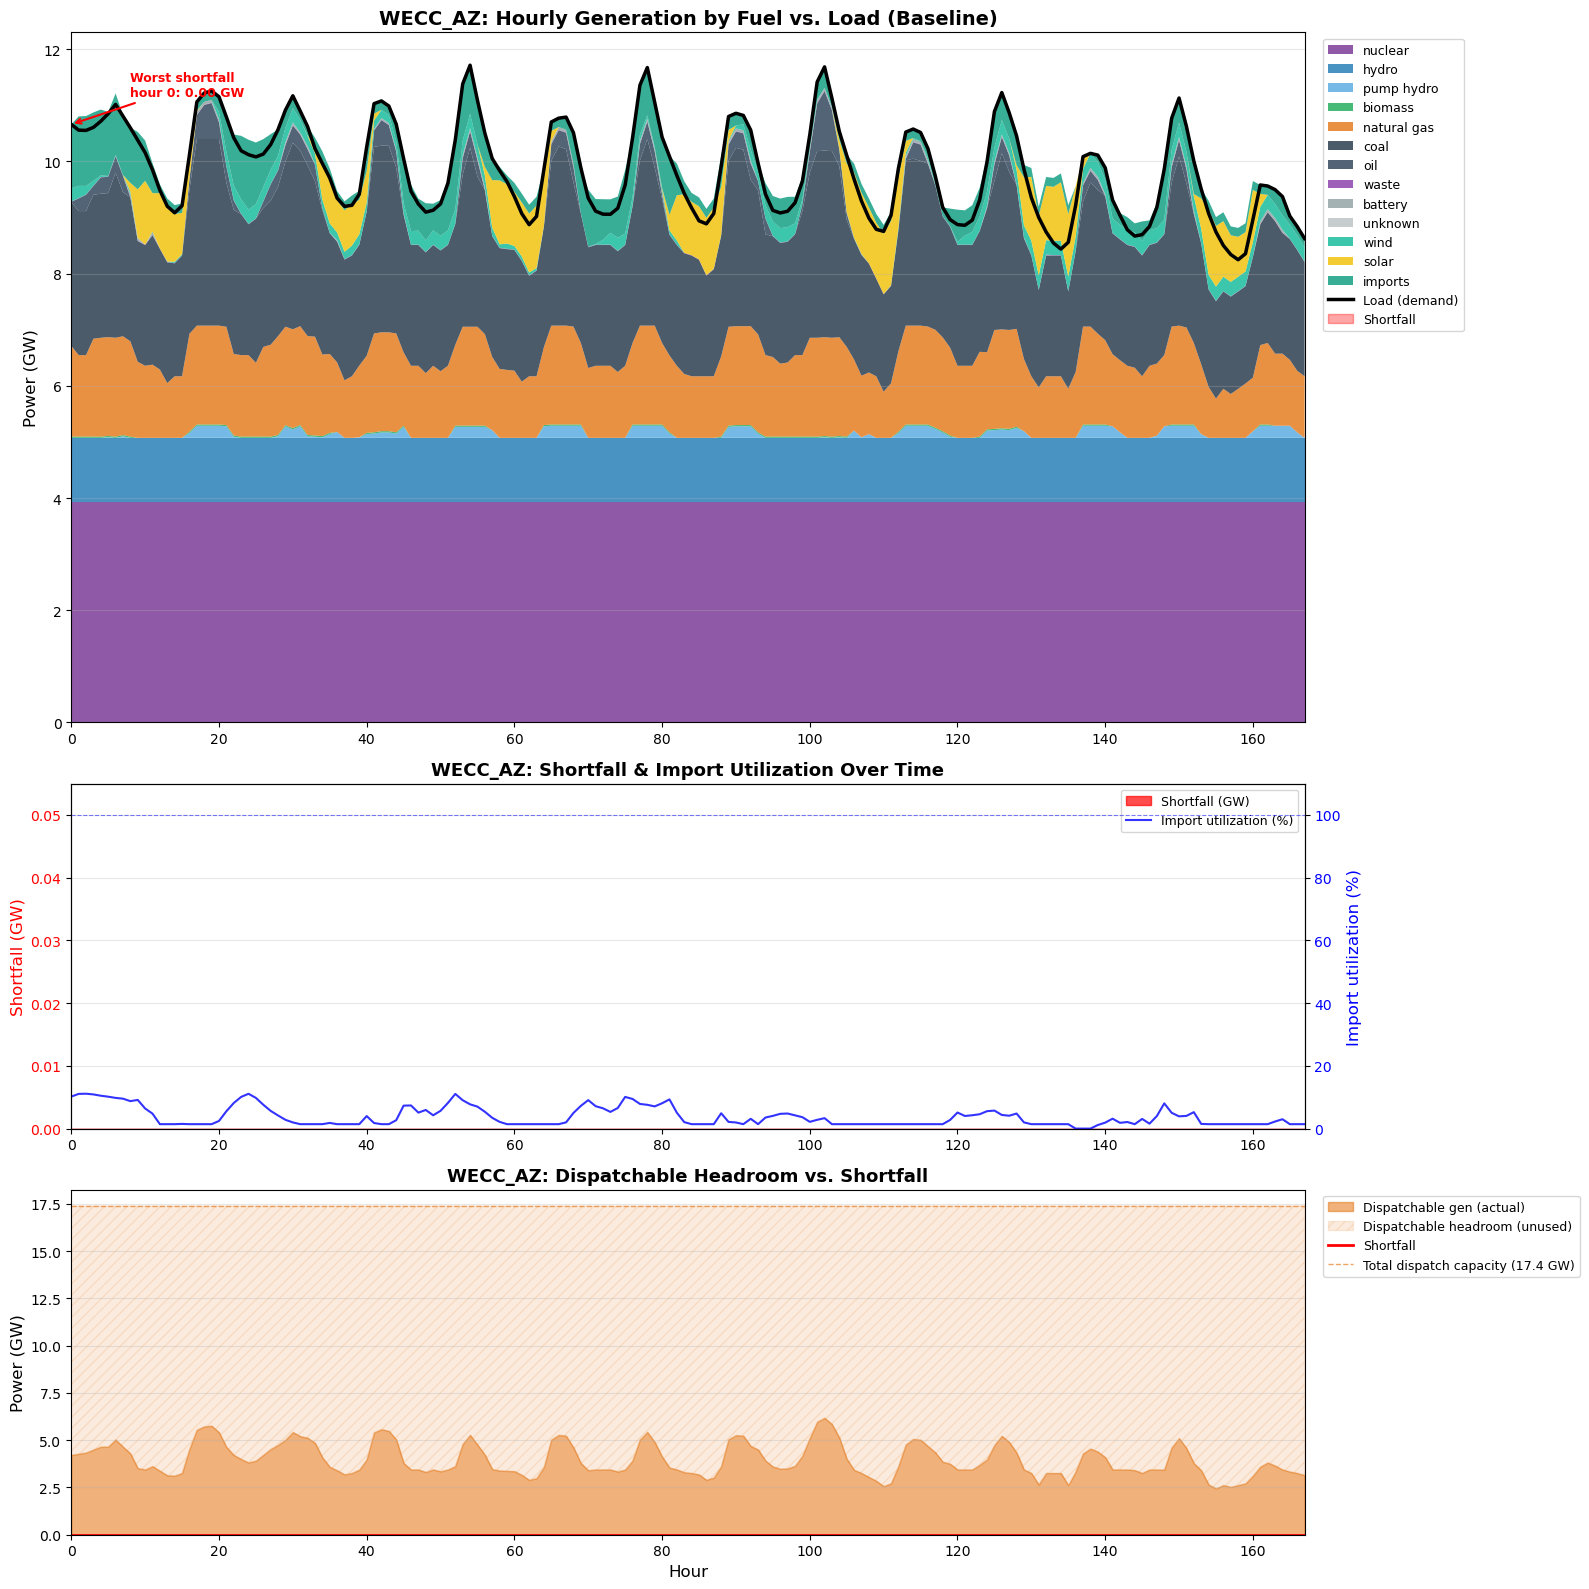

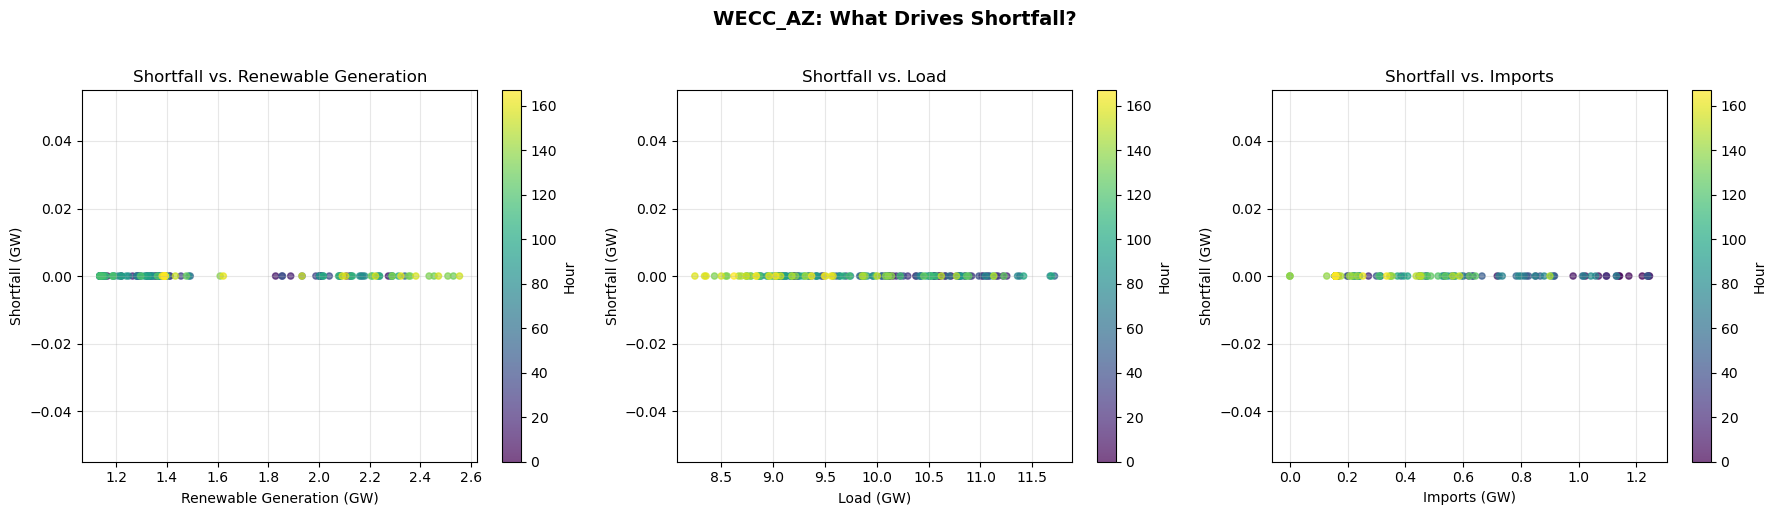

WECC_AZ SHORTFALL SUMMARY
  Hours with shortfall: 0/168
  Total shortfall:      0.00 GW·h = 0.00 GWh
  Peak shortfall:       0.00 GW at hour 0
  Average load:         9.88 GW
  Average generation:   9.59 GW
  Average import:       0.42 GW
  Max import capacity:  11.20 GW
  Avg import util:      3.8%

  Dispatchable capacity breakdown:
    natural gas    : cap=12.26 GW, avg dispatched=1.4232 GW, utilization=11.6%
    coal           : cap=3.33 GW, avg dispatched=2.4183 GW, utilization=72.7%
    oil            : cap=1.77 GW, avg dispatched=0.1140 GW, utilization=6.4%
    biomass        : cap=0.02 GW, avg dispatched=0.0124 GW, utilization=56.0%
    waste          : cap=0.01 GW, avg dispatched=0.0060 GW, utilization=100.0%

  Total dispatchable: cap=17.38 GW, avg used=3.9738 GW (22.9%)
  Unused headroom:    13.41 GW average
  => If dispatched, headroom alone could cover 13.4 GW of the 0.00 GW average shortfall


In [49]:
# ==========================================================================
# WECC_AZ Shortfall Time-Series Diagnostic Plots
# ==========================================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

TARGET_REGION = 'WECC_AZ'
num_hours = NUM_HOURS_INT if 'NUM_HOURS_INT' in dir() else 168
hours = np.arange(num_hours)

# ---- 1. Collect hourly data for WECC_AZ from solution ----
# Load (W)
load_W = np.zeros(num_hours)
node_sol = baseline_solution._node.get(TARGET_REGION, {})
for handle, asset in node_sol.get('assets', {}).items():
    if 'base_load' not in handle.lower():
        continue
    net = asset.get('net', [])
    if net and len(net) == num_hours:
        load_W += np.abs(np.array(net))

# Generation by fuel (W) — directly from solution + graph metadata
gr = baseline_graph
fuel_gen_W = {}  # {fuel: np.array of shape (num_hours,)}
store_discharge_W = {}
store_charge_W = {}
for handle, asset_sol in node_sol.get('assets', {}).items():
    if 'base_load' in handle.lower():
        continue
    asset_graph = gr._node.get(TARGET_REGION, {}).get('assets', {}).get(handle, {})
    cls = asset_graph.get('_class', '')
    fuel = asset_graph.get('fuel', 'unknown') or 'unknown'
    net = asset_sol.get('net', [])
    if not net or len(net) != num_hours:
        continue
    net_arr = np.array(net, dtype=float)
    if cls == 'Store':
        # Discharge (positive net) and charge (negative net) separately
        discharge = np.maximum(net_arr, 0)
        charge = np.maximum(-net_arr, 0)
        store_discharge_W[fuel] = store_discharge_W.get(fuel, np.zeros(num_hours)) + discharge
        store_charge_W[fuel] = store_charge_W.get(fuel, np.zeros(num_hours)) + charge
    else:
        fuel_gen_W[fuel] = fuel_gen_W.get(fuel, np.zeros(num_hours)) + np.maximum(net_arr, 0)

# Add storage discharge as generation
for fuel, arr in store_discharge_W.items():
    fuel_gen_W[fuel] = fuel_gen_W.get(fuel, np.zeros(num_hours)) + arr

# Imports and exports (W)
import_W = np.zeros(num_hours)
export_W = np.zeros(num_hours)
for source, adj in baseline_solution._adj.items():
    for target, edge_data in adj.items():
        if 'lines' not in edge_data:
            continue
        for line_name, line_data in edge_data['lines'].items():
            trans = line_data.get('transmission', [])
            if not trans or len(trans) != num_hours:
                continue
            eff = line_data.get('efficiency', 1.0)
            trans_arr = np.array(trans)
            if target == TARGET_REGION and source != TARGET_REGION:
                import_W += trans_arr * eff
            elif source == TARGET_REGION and target != TARGET_REGION:
                export_W += trans_arr

# Shortfall and wastage (W-s per step; solution stores energy, not power)
shortfall_Ws = np.array(node_sol.get('shortfall', [0]*num_hours), dtype=float)
if len(shortfall_Ws) != num_hours:
    shortfall_Ws = np.zeros(num_hours)
wastage_Ws = np.array(node_sol.get('wastage', [0]*num_hours), dtype=float)
if len(wastage_Ws) != num_hours:
    wastage_Ws = np.zeros(num_hours)

# Convert shortfall from W-s to average power (W) over 1-hour step
shortfall_W = shortfall_Ws / 3600  # W-s / s = W
wastage_W = wastage_Ws / 3600

# Total generation (W) = sum of all fuels
total_gen_W = sum(fuel_gen_W.values())

# Convert everything to GW for readability
to_GW = 1e-9
load_GW = load_W * to_GW
total_gen_GW = total_gen_W * to_GW
import_GW = import_W * to_GW
export_GW = export_W * to_GW
shortfall_GW = shortfall_W * to_GW
wastage_GW = wastage_W * to_GW

# ---- 2. Fuel-ordered generation in GW for stacking ----
fuel_colors = {
    'nuclear': '#7D3C98', 'hydro': '#2980B9', 'pump hydro': '#5DADE2',
    'geothermal': '#C0392B', 'biomass': '#27AE60', 'natural gas': '#E67E22',
    'coal': '#2C3E50', 'oil': '#34495E', 'waste': '#8E44AD',
    'battery': '#95A5A6', 'wind': '#1ABC9C', 'solar': '#F1C40F',
    'non-fossil': '#D35400', 'unknown': '#BDC3C7',
}
fuel_order = ['nuclear', 'hydro', 'pump hydro', 'geothermal', 'biomass',
              'natural gas', 'coal', 'oil', 'waste', 'battery',
              'non-fossil', 'unknown', 'wind', 'solar']
fuels_present = [f for f in fuel_order if f in fuel_gen_W]
for f in sorted(fuel_gen_W.keys()):
    if f not in fuels_present:
        fuels_present.append(f)

gen_stack_GW = [fuel_gen_W[f] * to_GW for f in fuels_present]
stack_colors = [fuel_colors.get(f, '#CCCCCC') for f in fuels_present]

# ==========================================================================
# PLOT 1: Stacked generation by fuel vs. load & shortfall (WECC_AZ)
# ==========================================================================
fig, axes = plt.subplots(3, 1, figsize=(16, 16), gridspec_kw={'height_ratios': [3, 1.5, 1.5]})

ax1 = axes[0]
# Stack generation fuels + imports together in a single stackplot so imports
# sit ON TOP of generation rather than overlapping from zero.
all_stack_GW = gen_stack_GW + [import_GW]
all_stack_labels = fuels_present + ['imports']
all_stack_colors = stack_colors + ['#16A085']
ax1.stackplot(hours, all_stack_GW, labels=all_stack_labels, colors=all_stack_colors, alpha=0.85)
ax1.plot(hours, load_GW, 'k-', lw=2.5, label='Load (demand)')
# Show shortfall as a shaded red band between supply and load
supply_GW = total_gen_GW + import_GW - export_GW
ax1.fill_between(hours, supply_GW, load_GW,
                 where=(load_GW > supply_GW), color='red', alpha=0.35, label='Shortfall')
ax1.set_ylabel('Power (GW)', fontsize=12)
ax1.set_title(f'{TARGET_REGION}: Hourly Generation by Fuel vs. Load (Baseline)', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=9)
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_xlim(0, num_hours - 1)
ax1.set_ylim(bottom=0)

# Annotate worst shortfall hour
worst_h = int(np.argmax(shortfall_GW))
ax1.annotate(f'Worst shortfall\nhour {worst_h}: {shortfall_GW[worst_h]:.2f} GW',
             xy=(worst_h, load_GW[worst_h]), xytext=(worst_h + 8, load_GW[worst_h] + 0.5),
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
             fontsize=9, color='red', fontweight='bold')

# ==========================================================================
# PLOT 2: Shortfall time series + import utilization
# ==========================================================================
ax2 = axes[1]
ax2.fill_between(hours, 0, shortfall_GW, color='red', alpha=0.7, label='Shortfall (GW)')
ax2.set_ylabel('Shortfall (GW)', fontsize=12, color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_xlim(0, num_hours - 1)
ax2.set_ylim(bottom=0)
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_title(f'{TARGET_REGION}: Shortfall & Import Utilization Over Time', fontsize=13, fontweight='bold')

# Secondary axis: import capacity utilization
ax2b = ax2.twinx()
# Compute max import capacity (sum of all inbound line capacities)
max_import_cap_W = 0
for source, adj in baseline_solution._adj.items():
    for target, edge_data in adj.items():
        if target != TARGET_REGION or source == TARGET_REGION:
            continue
        if 'lines' not in edge_data:
            continue
        for line_name, line_data in edge_data['lines'].items():
            cap = line_data.get('installed_capacity', 0)
            if cap <= 0:
                # Try graph for capacity
                graph_edge = gr._adj.get(source, {}).get(target, {})
                graph_lines = graph_edge.get('lines', {}) if isinstance(graph_edge, dict) else {}
                graph_line = graph_lines.get(line_name, {})
                cap = graph_line.get('installed_capacity', 0) if isinstance(graph_line, dict) else 0
            max_import_cap_W += cap

import_util_pct = (import_W / max_import_cap_W * 100) if max_import_cap_W > 0 else np.zeros(num_hours)
ax2b.plot(hours, import_util_pct, 'b-', lw=1.5, alpha=0.8, label='Import utilization (%)')
ax2b.set_ylabel('Import utilization (%)', fontsize=12, color='blue')
ax2b.tick_params(axis='y', labelcolor='blue')
ax2b.set_ylim(0, 110)
ax2b.axhline(100, color='blue', ls='--', lw=0.8, alpha=0.5)

# Combine legends
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)

# ==========================================================================
# PLOT 3: Dispatchable generation headroom vs shortfall
# ==========================================================================
ax3 = axes[2]
# Get nameplate capacity for dispatchable fuels
dispatch_fuels = ['natural gas', 'coal', 'oil', 'biomass', 'waste']
dispatch_cap_W = {}
for handle, asset_data in gr._node.get(TARGET_REGION, {}).get('assets', {}).items():
    if asset_data.get('_class') == 'Producer':
        fuel = asset_data.get('fuel', 'unknown') or 'unknown'
        if fuel in dispatch_fuels:
            dispatch_cap_W[fuel] = dispatch_cap_W.get(fuel, 0) + asset_data.get('installed_capacity', 0)

total_dispatch_cap_GW = sum(dispatch_cap_W.values()) * to_GW
dispatch_gen_GW = sum(fuel_gen_W.get(f, np.zeros(num_hours)) for f in dispatch_fuels) * to_GW

headroom_GW = total_dispatch_cap_GW - dispatch_gen_GW  # unused dispatchable capacity

ax3.fill_between(hours, 0, dispatch_gen_GW, color='#E67E22', alpha=0.6, label='Dispatchable gen (actual)')
ax3.fill_between(hours, dispatch_gen_GW, dispatch_gen_GW + headroom_GW,
                 color='#E67E22', alpha=0.15, hatch='///', label='Dispatchable headroom (unused)')
ax3.plot(hours, shortfall_GW, 'r-', lw=2, label='Shortfall')
ax3.axhline(total_dispatch_cap_GW, color='#E67E22', ls='--', lw=1, alpha=0.7,
            label=f'Total dispatch capacity ({total_dispatch_cap_GW:.1f} GW)')
ax3.set_xlabel('Hour', fontsize=12)
ax3.set_ylabel('Power (GW)', fontsize=12)
ax3.set_title(f'{TARGET_REGION}: Dispatchable Headroom vs. Shortfall', fontsize=13, fontweight='bold')
ax3.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=9)
ax3.grid(True, alpha=0.3, axis='y')
ax3.set_xlim(0, num_hours - 1)
ax3.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig(f'{output_dir}/wecc_az_shortfall_diagnostic.png', dpi=150, bbox_inches='tight')
plt.show()

# ==========================================================================
# PLOT 4: Correlation scatter — shortfall vs. solar/wind availability
# ==========================================================================
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))

solar_GW = fuel_gen_W.get('solar', np.zeros(num_hours)) * to_GW
wind_GW = fuel_gen_W.get('wind', np.zeros(num_hours)) * to_GW
ren_GW = solar_GW + wind_GW + fuel_gen_W.get('hydro', np.zeros(num_hours)) * to_GW

# Scatter 1: Shortfall vs renewable generation
ax = axes2[0]
sc = ax.scatter(ren_GW, shortfall_GW, c=hours, cmap='viridis', s=20, alpha=0.7)
ax.set_xlabel('Renewable Generation (GW)')
ax.set_ylabel('Shortfall (GW)')
ax.set_title('Shortfall vs. Renewable Generation')
ax.grid(True, alpha=0.3)
plt.colorbar(sc, ax=ax, label='Hour')

# Scatter 2: Shortfall vs load
ax = axes2[1]
sc = ax.scatter(load_GW, shortfall_GW, c=hours, cmap='viridis', s=20, alpha=0.7)
ax.set_xlabel('Load (GW)')
ax.set_ylabel('Shortfall (GW)')
ax.set_title('Shortfall vs. Load')
ax.grid(True, alpha=0.3)
plt.colorbar(sc, ax=ax, label='Hour')

# Scatter 3: Shortfall vs net import (how much is coming in)
ax = axes2[2]
sc = ax.scatter(import_GW, shortfall_GW, c=hours, cmap='viridis', s=20, alpha=0.7)
ax.set_xlabel('Imports (GW)')
ax.set_ylabel('Shortfall (GW)')
ax.set_title('Shortfall vs. Imports')
ax.grid(True, alpha=0.3)
plt.colorbar(sc, ax=ax, label='Hour')

plt.suptitle(f'{TARGET_REGION}: What Drives Shortfall?', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{output_dir}/wecc_az_shortfall_drivers.png', dpi=150, bbox_inches='tight')
plt.show()

# ==========================================================================
# Print summary statistics
# ==========================================================================
print("=" * 70)
print(f"{TARGET_REGION} SHORTFALL SUMMARY")
print("=" * 70)
print(f"  Hours with shortfall: {np.sum(shortfall_GW > 0.001)}/{num_hours}")
print(f"  Total shortfall:      {shortfall_GW.sum():.2f} GW·h = {shortfall_Ws.sum()/3.6e12:.2f} GWh")
print(f"  Peak shortfall:       {shortfall_GW.max():.2f} GW at hour {worst_h}")
print(f"  Average load:         {load_GW.mean():.2f} GW")
print(f"  Average generation:   {total_gen_GW.mean():.2f} GW")
print(f"  Average import:       {import_GW.mean():.2f} GW")
print(f"  Max import capacity:  {max_import_cap_W * to_GW:.2f} GW")
print(f"  Avg import util:      {import_util_pct.mean():.1f}%")
print()
print("  Dispatchable capacity breakdown:")
for fuel in sorted(dispatch_cap_W, key=lambda f: -dispatch_cap_W[f]):
    cap_gw = dispatch_cap_W[fuel] * to_GW
    actual_gw_avg = fuel_gen_W.get(fuel, np.zeros(num_hours)).mean() * to_GW
    print(f"    {fuel:15s}: cap={cap_gw:.2f} GW, avg dispatched={actual_gw_avg:.4f} GW, utilization={actual_gw_avg/cap_gw*100:.1f}%")
print()
if total_dispatch_cap_GW > 0:
    avg_dispatch_gen = dispatch_gen_GW.mean()
    print(f"  Total dispatchable: cap={total_dispatch_cap_GW:.2f} GW, avg used={avg_dispatch_gen:.4f} GW ({avg_dispatch_gen/total_dispatch_cap_GW*100:.1f}%)")
    print(f"  Unused headroom:    {total_dispatch_cap_GW - avg_dispatch_gen:.2f} GW average")
    print(f"  => If dispatched, headroom alone could cover {(total_dispatch_cap_GW - avg_dispatch_gen):.1f} GW of the {shortfall_GW.mean():.2f} GW average shortfall")
print("=" * 70)

In [50]:
# DATA SANITY CHECK: Is WECC_AZ shortfall due to input data imbalance?
# Compare *input* load and generation capacity from the graph (before solve).
# If load in the data >> generation capacity in the data, shortfall is expected and points to a data issue.

num_hours = NUM_HOURS_INT if 'NUM_HOURS_INT' in dir() else 168
gr = baseline_graph if 'baseline_graph' in dir() else graph

def expected_load_gwh_from_graph(g, region):
    """
    From graph: sum over base_load assets of |capacity| * sum(profile) * 3600 / 3.6e12 = GWh.

    Handles asset['profile'] as:
        - Scalar: uses as constant (broadcasted)
        - 1D array: as vector profile
        - String (e.g., 'WECC_AZ:solar:'): treat as missing, use 1.0 default
        - None: use 1.0 default
    """
    node = g._node.get(region, {})
    total_ws = 0.0
    for handle, asset in node.get('assets', {}).items():
        if 'base_load' not in handle.lower() and asset.get('_class') != 'Load':
            continue
        cap = asset.get('installed_capacity', 0)
        profile = asset.get('profile', None)
        # Resolve profile reference (model does this in network.from_graph)
        if isinstance(profile, str):
            profile = node.get('profiles', {}).get(profile, None)
        # Robustly handle missing or non-numeric profile
        is_bad = False
        if profile is None:
            is_bad = True
        elif isinstance(profile, str):
            is_bad = True
        else:
            arr = np.atleast_1d(np.asarray(profile))
            if arr.dtype.kind in {'U', 'S', 'O'}:
                # Profile contains strings (likely an ID like 'WECC_AZ:solar:')
                is_bad = True
            elif arr.size == 0:
                is_bad = True
        if is_bad:
            profile_arr = np.ones(num_hours)
        else:
            profile_arr = np.atleast_1d(np.asarray(profile))
            # If it's a scalar numeric, broadcast
            if profile_arr.size == 1:
                profile_arr = np.full(num_hours, float(profile_arr.flat[0]))
            else:
                # truncate/resize if needed (should be length num_hours)
                profile_arr = np.resize(profile_arr[:num_hours], num_hours)
        # Load energy = sum over h of |cap| * profile[h] * 3600 (W-s per hour)
        total_ws += abs(cap) * profile_arr.sum() * 3600
    return total_ws / 3.6e12

def max_generation_gwh_from_graph(g, region):
    """From graph: sum over Producer assets of installed_capacity * mean(profile or cf) * 168h in GWh."""
    node = g._node.get(region, {})
    profiles_dict = node.get('profiles', {})
    total_gwh = 0.0
    for handle, asset in node.get('assets', {}).items():
        if asset.get('_class') != 'Producer':
            continue
        cap = asset.get('installed_capacity', 0)
        profile = asset.get('profile', None)
        if isinstance(profile, str):
            profile = profiles_dict.get(profile, None)
        cf = asset.get('capacity_factor', 1.0)
        if profile is not None:
            arr = np.atleast_1d(np.asarray(profile))
            if arr.dtype.kind not in {'U', 'S', 'O'} and arr.size > 0:
                cf = float(np.mean(arr))
        # Max energy = cap * cf * 168 * 3600 W-s = cap * cf * 168 / 1e9 GWh (since 3.6e12 W-s = 1 GWh)
        total_gwh += cap * cf * 168 * 3600 / 3.6e12
    return total_gwh

def max_import_gwh_into_region(g, region):
    """Sum of transmission line capacities into this region (import limit)."""
    if not hasattr(g, '_adj'):
        return 0.0
    total_cap_W = 0.0
    for source, adj in g._adj.items():
        for target, edge_data in adj.items():
            if target != region or source == region:
                continue
            for line_name, line_data in edge_data.get('lines', {}).items():
                total_cap_W += line_data.get('installed_capacity', 0)
    # Max import over 168 h = capacity * 168 * 3600 W-s -> GWh
    return total_cap_W * 168 * 3600 / 3.6e12

print("=" * 70)
print("DATA SANITY CHECK: Input load vs generation capacity (from graph)")
print("=" * 70)

TARGET = 'WECC_AZ'
regions = list(gr._node.keys()) if gr is not None else []

if gr is None:
    print("No graph available. Run graph load cell first.")
else:
    print(f"\nPer-region: Expected load (GWh) and max generation (GWh) from INPUT DATA:")
    print(f"{'Region':<14} {'Load (data)':>12} {'Gen cap (data)':>14} {'Import cap':>12} {'Load/Gen':>8}  Note")
    print("-" * 75)
    for r in sorted(regions):
        try:
            load_gwh = expected_load_gwh_from_graph(gr, r)
        except Exception as e:
            print(f"{r:<14}  [load calc error: {e}]")
            continue
        try:
            gen_gwh = max_generation_gwh_from_graph(gr, r)
        except Exception as e:
            print(f"{r:<14}  [gen calc error: {e}]")
            continue
        try:
            imp_gwh = max_import_gwh_into_region(gr, r)
        except Exception as e:
            imp_gwh = float('nan')
        ratio = load_gwh / gen_gwh if gen_gwh > 0 else float('inf')
        note = ""
        if ratio > 1.5 and gen_gwh > 0:
            note = "<< load >> local gen (needs imports)"
        elif ratio > 2.5:
            note = "*** DATA IMBALANCE? ***"
        print(f"{r:<14} {load_gwh:>12.1f} {gen_gwh:>14.1f} {imp_gwh:>12.1f} {ratio:>8.2f}  {note}")

    load_az = expected_load_gwh_from_graph(gr, TARGET)
    gen_az = max_generation_gwh_from_graph(gr, TARGET)
    imp_az = max_import_gwh_into_region(gr, TARGET)
    print("\n" + "=" * 70)
    print(f"WECC_AZ summary (input data):")
    print(f"  Expected load (from graph):     {load_az:.1f} GWh")
    print(f"  Max generation capacity (graph): {gen_az:.1f} GWh")
    print(f"  Max import capacity (into AZ):  {imp_az:.1f} GWh")
    print(f"  Theoretical max supply (gen+imp): {gen_az + imp_az:.1f} GWh")
    print(f"  (Expected load uses same profile resolution as the model; max gen uses mean profile as CF.)")
    if load_az > gen_az + imp_az:
        print(f"  -> DATA ISSUE: Load ({load_az:.1f}) > gen+import capacity ({gen_az + imp_az:.1f}). Shortfall inevitable.")
    elif load_az <= gen_az + imp_az:
        print(f"  -> Supply capacity >= load in data. Shortfall in solution = load - (actual gen + actual import);")
        print(f"     actual gen is below nameplate due to renewable profiles / dispatch.")
    print("=" * 70)

DATA SANITY CHECK: Input load vs generation capacity (from graph)

Per-region: Expected load (GWh) and max generation (GWh) from INPUT DATA:
Region          Load (data) Gen cap (data)   Import cap Load/Gen  Note
---------------------------------------------------------------------------
WECC_AZ              1735.1         3772.4       1881.9     0.46  
WECC_CO              1767.9         1905.1        456.0     0.93  
WECC_ID               566.1          261.0       1114.7     2.17  << load >> local gen (needs imports)
WECC_IID              123.9          221.8        168.8     0.56  
WECC_MT               377.9          485.3        151.2     0.78  
WECC_NM               603.0          949.5        565.2     0.64  
WECC_NNV              272.1          420.6        186.5     0.65  
WECC_PNW             4621.1         3748.2       1962.7     1.23  
WECC_SCE             2789.5         1561.4       2215.9     1.79  << load >> local gen (needs imports)
WECC_SNV              539.6         1

In [51]:
# ============================================================
# ISSUE 1: WECC_AZ Shortfall Investigation
# WHY: Nameplate capacity >> baseload, but solution shows 340 GWh shortfall.
# The bar chart shows ~14 GW nameplate in AZ vs ~10 GW peak load.
# But nameplate != dispatchable output. Need to see what the optimizer actually dispatches.
# ============================================================

import numpy as np, pandas as pd, matplotlib.pyplot as plt

TARGET = 'WECC_AZ'
num_hours = NUM_HOURS_INT if 'NUM_HOURS_INT' in dir() else 168

print("=" * 80)
print("ISSUE 1: WECC_AZ  —  Nameplate capacity vs actual generation by fuel")
print("=" * 80)

# 1a. Nameplate capacity by fuel in AZ (from graph)
gr = baseline_graph if 'baseline_graph' in dir() else graph
node_az = gr._node.get(TARGET, {})
profiles_dict = node_az.get('profiles', {})

nameplate_by_fuel = {}
profile_cf_by_fuel = {}   # mean capacity-factor from profile
store_info = []

for handle, asset in node_az.get('assets', {}).items():
    cls = asset.get('_class', '')
    fuel = asset.get('fuel', 'unknown') or 'unknown'
    cap_W = asset.get('installed_capacity', 0)

    if cls == 'Producer':
        nameplate_by_fuel[fuel] = nameplate_by_fuel.get(fuel, 0) + cap_W
        # Compute mean capacity factor from profile
        profile = asset.get('profile', None)
        if isinstance(profile, str):
            profile = profiles_dict.get(profile, None)
        if profile is not None:
            arr = np.atleast_1d(np.asarray(profile))
            if arr.dtype.kind not in {'U', 'S', 'O'} and arr.size > 0:
                cf = float(np.mean(arr[:num_hours]))
            else:
                cf = asset.get('capacity_factor', 1.0)
        else:
            cf = asset.get('capacity_factor', 1.0)
        # Weighted average CF
        prev = profile_cf_by_fuel.get(fuel, (0, 0))  # (sum_cap*cf, sum_cap)
        profile_cf_by_fuel[fuel] = (prev[0] + cap_W * cf, prev[1] + cap_W)

    elif cls == 'Store':
        store_info.append({
            'handle': handle, 'fuel': fuel, 'capacity_W': cap_W,
            'efficiency': asset.get('efficiency', 1),
            'production_rate': asset.get('production_rate', 1),
            'operating_cost': asset.get('operating_cost', 0),
            'initial': asset.get('initial', 0),
        })

print(f"\n{'Fuel':<16} {'Nameplate (GW)':>14} {'Mean CF':>8} {'Max Energy (GWh)':>16}")
print("-" * 58)
total_max_gen = 0
for fuel in sorted(nameplate_by_fuel, key=lambda f: -nameplate_by_fuel[f]):
    cap_gw = nameplate_by_fuel[fuel] / 1e9
    s, w = profile_cf_by_fuel.get(fuel, (0, 1))
    cf = s / w if w > 0 else 1.0
    max_gen = nameplate_by_fuel[fuel] * cf * num_hours * 3600 / 3.6e12
    total_max_gen += max_gen
    print(f"  {fuel:<14} {cap_gw:>14.3f} {cf:>8.3f} {max_gen:>16.1f}")
print(f"  {'TOTAL':<14} {sum(nameplate_by_fuel.values())/1e9:>14.3f} {'':>8} {total_max_gen:>16.1f}")

# 1b. Actual dispatched generation by fuel in AZ (from solution)
if 'baseline_gen' in dir() and baseline_gen is not None:
    az_gen = baseline_gen[baseline_gen['region'] == TARGET].groupby('fuel')['generation_kwh'].sum() / 1e6  # kWh -> GWh
    print(f"\nActual generation dispatched in {TARGET} (from solution):")
    for fuel in az_gen.sort_values(ascending=False).index:
        print(f"  {fuel:<14} {az_gen[fuel]:>14.1f} GWh")
    print(f"  {'TOTAL':<14} {az_gen.sum():>14.1f} GWh")

# 1c. Load from solution
load_az_W = np.zeros(num_hours)
sol_node_az = baseline_solution._node.get(TARGET, {})
for handle, asset in sol_node_az.get('assets', {}).items():
    if 'base_load' not in handle.lower():
        continue
    net = asset.get('net', [])
    if net and len(net) == num_hours:
        load_az_W += np.abs(np.array(net))
load_az_gwh = load_az_W.sum() * 3600 / 3.6e12

print(f"\nLoad (from solution):      {load_az_gwh:.1f} GWh")
print(f"Max generation (from data): {total_max_gen:.1f} GWh")
print(f"Actual generation (sol):    {az_gen.sum():.1f} GWh" if 'az_gen' in dir() else "")

gap = load_az_gwh - (az_gen.sum() if 'az_gen' in dir() else 0)
print(f"\nGap (load - actual gen):    {gap:.1f} GWh  (filled by imports {435:.0f} GWh + shortfall {340:.0f} GWh)")

print("\n" + "=" * 80)
print("DEEP DIVE: Why are gas/coal at zero in the optimizer solution?")
print("=" * 80)

# 1d0. Check solver status
print("\n--- 1d0. Solver status ---")
if 'baseline_network' in dir() and hasattr(baseline_network, 'result'):
    r = baseline_network.result
    print(f"  Solver status: {r.solver.status}")
    print(f"  Termination: {r.solver.termination_condition}")
    if hasattr(r.problem, 'number_of_variables'):
        print(f"  Variables: {r.problem[0].number_of_variables}")
        print(f"  Constraints: {r.problem[0].number_of_constraints}")
    obj_val = pe.value(baseline_network.model.objective)
    print(f"  Objective value: {obj_val:.6e}")

# 1d. Check solution for a few gas assets directly
print("\n--- 1d. Checking solution 'net' for gas/coal assets ---")
sol_node_az = baseline_solution._node.get(TARGET, {})
gas_checked = 0
for handle, asset in sol_node_az.get('assets', {}).items():
    # Identify gas/coal from graph
    graph_asset = gr._node.get(TARGET, {}).get('assets', {}).get(handle, {})
    fuel = graph_asset.get('fuel', '')
    cls = graph_asset.get('_class', '')
    if cls == 'Producer' and fuel in ('natural gas', 'coal') and gas_checked < 5:
        net = asset.get('net', [])
        prod = asset.get('production', [])
        cap = graph_asset.get('installed_capacity', 0)
        profile_ref = graph_asset.get('profile', None)
        profile_param = asset.get('profile', [])
        net_arr = np.array(net) if net else np.zeros(1)
        prod_arr = np.array(prod) if prod else np.zeros(1)
        print(f"\n  {handle} ({fuel}, cap={cap/1e6:.0f} MW, profile_ref={profile_ref}):")
        print(f"    net: sum={net_arr.sum():.6f}, max={net_arr.max():.6f}, min={net_arr.min():.6f}")
        print(f"    production: sum={prod_arr.sum():.6f}, max={prod_arr.max():.6f}")
        if profile_param:
            prof_arr = np.array(profile_param)
            print(f"    profile (from solution): mean={prof_arr.mean():.4f}, min={prof_arr.min():.4f}, max={prof_arr.max():.4f}")
        gas_checked += 1

# 1d2. Check if gas assets exist in the Region's assets AND have Producer objects
print("\n--- 1d2. Gas/coal assets in baseline_network ---")
if 'baseline_network' in dir():
    region_obj = baseline_network.graph._node.get(TARGET, {}).get('object', None)
    if region_obj is not None:
        gas_in_region = 0
        for h, a in region_obj.assets.items():
            obj = a.get('object', None)
            if obj and hasattr(obj, 'operating_cost'):
                fuel = a.get('fuel', '')
                if fuel in ('natural gas', 'coal'):
                    gas_in_region += 1
                    if gas_in_region <= 3:
                        print(f"  {h} ({fuel}): type={type(obj).__name__}, cap={obj.installed_capacity/1e6:.0f} MW, " +
                              f"dispatchable={obj.dispatchable}, profile is None={obj.profile is None}, " +
                              f"op_cost={obj.operating_cost:.2e}")
        print(f"  Total gas/coal Producers in Region object: {gas_in_region}")
    else:
        print("  WARNING: No Region object for WECC_AZ!")

# 1e. Check what the Pyomo model has for a gas asset
print("\n--- 1e. Checking Pyomo model variables (if network still available) ---")
if 'baseline_network' in dir():
    model = baseline_network.model
    gas_checked2 = 0
    for handle in baseline_network.assets:
        asset_info = baseline_network.assets[handle]
        obj = asset_info.get('object', None)
        if obj is None:
            continue
        if not isinstance(obj, good.optimization.assets.producer.Producer):
            continue
        fuel = asset_info.get('fuel', '')
        if fuel in ('natural gas', 'coal') and gas_checked2 < 3:
            prod_var = getattr(model, f"{handle}::production", None)
            prof_param = getattr(model, f"{handle}::profile", None)
            if prod_var is not None:
                prod_vals = list(prod_var.extract_values().values())
                print(f"  {handle} ({fuel}): production sum={sum(prod_vals):.4f}, max={max(prod_vals):.4f}")
            if prof_param is not None:
                prof_vals = list(prof_param.extract_values().values())
                print(f"    profile param: mean={np.mean(prof_vals):.4f}, first5={prof_vals[:5]}")
            print(f"    installed_capacity={obj.installed_capacity/1e6:.0f} MW, dispatchable={obj.dispatchable}")
            print(f"    operating_cost={obj.operating_cost:.2e}, profile is None: {obj.profile is None}")
            gas_checked2 += 1

# 1f. Check RPS policy constraints
print("\n--- 1f. RPS (Portfolio_Standard) policy analysis ---")
if 'baseline_network' in dir():
    for pkey, pdata in baseline_network.policies.items():
        pobj = pdata.get('object', None)
        if pobj is None:
            continue
        print(f"\n  Policy: {pkey} (ratio={pobj.ratio:.4f})")
        print(f"    Included assets (renewable): {len(pobj.included)}")
        print(f"    Excluded assets (non-renewable): {len(pobj.excluded)}")
        print(f"    non_compliance_capacity: {pobj.non_compliance_capacity}")

        # Check what fuels are in included/excluded
        incl_fuels = {}
        for h, a in pobj.included.items():
            f = a.get('fuel', 'unknown')
            incl_fuels[f] = incl_fuels.get(f, 0) + 1
        excl_fuels = {}
        for h, a in pobj.excluded.items():
            f = a.get('fuel', 'unknown')
            excl_fuels[f] = excl_fuels.get(f, 0) + 1
        print(f"    Included fuels: {dict(sorted(incl_fuels.items()))}")
        print(f"    Excluded fuels: {dict(sorted(excl_fuels.items()))}")

        # Compute actual included/excluded generation from solution
        incl_gen_gwh = 0
        for h, a in pobj.included.items():
            obj = a.get('object', None)
            if obj and hasattr(obj, 'handle'):
                prod_var = getattr(model, f"{obj.handle}::production", None)
                if prod_var:
                    vals = list(prod_var.extract_values().values())
                    incl_gen_gwh += sum(vals) * 3600 / 3.6e12
        excl_gen_gwh = 0
        for h, a in pobj.excluded.items():
            obj = a.get('object', None)
            if obj and hasattr(obj, 'handle'):
                prod_var = getattr(model, f"{obj.handle}::production", None)
                if prod_var:
                    vals = list(prod_var.extract_values().values())
                    excl_gen_gwh += sum(vals) * 3600 / 3.6e12
        print(f"    Solution: included gen = {incl_gen_gwh:.2f} GWh, excluded gen = {excl_gen_gwh:.2f} GWh")
        if excl_gen_gwh > 0:
            actual_ratio = incl_gen_gwh / (incl_gen_gwh + excl_gen_gwh)
            print(f"    Actual renewable ratio: {actual_ratio:.4f} (required: {pobj.ratio:.4f})")
        # Check constraint slack
        nc_var = getattr(model, f"{pkey}::non_compliance", None)
        if nc_var is not None:
            nc_val = nc_var.value
            print(f"    non_compliance value: {nc_val}")

print("\n" + "=" * 80)

ISSUE 1: WECC_AZ  —  Nameplate capacity vs actual generation by fuel

Fuel             Nameplate (GW)  Mean CF Max Energy (GWh)
----------------------------------------------------------
  natural gas            12.259    1.000           2059.6
  nuclear                 3.937    1.000            661.4
  coal                    3.326    1.000            558.8
  hydro                   2.838    0.400            190.7
  oil                     1.769    1.000            297.2
  biomass                 0.022    1.000              3.7
  waste                   0.006    1.000              1.0
  TOTAL                  24.158                    3772.4

Actual generation dispatched in WECC_AZ (from solution):
  nuclear                 661.4 GWh
  coal                    406.3 GWh
  natural gas             239.1 GWh
  hydro                   190.7 GWh
  solar                    51.4 GWh
  wind                     24.5 GWh
  oil                      19.1 GWh
  pump hydro               13.1 GWh
  b

In [52]:
# ============================================================
# ISSUE 2: WHY IS STORAGE (BATTERY / PUMP HYDRO) BARELY DISPATCHED?
# The Store model constraints reveal the answer:
#   - level[0] == initial  AND  level[-1] == initial
#   - production[0] == 0   AND  consumption[0] == 0
#   - net = production * efficiency - consumption / efficiency
# If initial == 0 (common default), the store starts empty, must end empty,
# and the first hour is forced to zero production AND zero consumption.
# With time_step = 3600s and efficiency < 1, round-trip losses make
# storage unprofitable unless there's a large enough price spread.
# Also: if installed_capacity is very small, max discharge is tiny.
# ============================================================

import numpy as np, pandas as pd

print("=" * 80)
print("ISSUE 2: Storage (battery / pump hydro) dispatch investigation")
print("=" * 80)

gr = baseline_graph if 'baseline_graph' in dir() else graph
sol = baseline_solution

# Collect Store assets from graph AND solution
store_summary = []
for source, node in gr._node.items():
    for handle, asset in node.get('assets', {}).items():
        if asset.get('_class') != 'Store':
            continue
        fuel = asset.get('fuel', 'unknown') or 'unknown'
        cap_W = asset.get('installed_capacity', 0)
        eff = asset.get('efficiency', 1)
        prod_rate = asset.get('production_rate', 1)
        cons_rate = asset.get('consumption_rate', 1)
        initial = asset.get('initial', 0)
        op_cost = asset.get('operating_cost', 0)

        # Solution data
        sol_node = sol._node.get(source, {})
        sol_asset = sol_node.get('assets', {}).get(handle, {})
        net = sol_asset.get('net', [])
        production = sol_asset.get('production', [])
        consumption = sol_asset.get('consumption', [])
        level = sol_asset.get('level', [])

        max_discharge_W = cap_W * prod_rate   # theoretical max discharge power (W)
        max_charge_W = cap_W * cons_rate      # theoretical max charge power (W)

        if net:
            net_arr = np.array(net)
            discharge_gwh = np.maximum(net_arr, 0).sum() * 3600 / 3.6e12
            charge_gwh = np.minimum(net_arr, 0).sum() * 3600 / 3.6e12
            max_net_MW = net_arr.max() / 1e6
        else:
            discharge_gwh = charge_gwh = max_net_MW = 0

        if production:
            max_prod_MW = max(production) / 1e6
        else:
            max_prod_MW = 0
        if level:
            max_level_MWh = max(level) * 3600 / 3.6e6  # W-s capacity -> MWh
        else:
            max_level_MWh = 0

        store_summary.append({
            'region': source, 'handle': handle, 'fuel': fuel,
            'capacity_MW': cap_W / 1e6,
            'max_discharge_MW': max_discharge_W / 1e6,
            'max_charge_MW': max_charge_W / 1e6,
            'efficiency': eff,
            'initial_MWh': initial * 3600 / 3.6e6,  # W-s -> MWh
            'operating_cost': op_cost,
            'sol_discharge_GWh': discharge_gwh,
            'sol_max_prod_MW': max_prod_MW,
            'sol_max_level_MWh': max_level_MWh,
        })

df_store = pd.DataFrame(store_summary)
if len(df_store) == 0:
    print("  No Store assets found.")
else:
    print(f"\nTotal Store assets: {len(df_store)}")
    print(f"\n--- Aggregate by fuel ---")
    agg = df_store.groupby('fuel').agg({
        'capacity_MW': 'sum',
        'max_discharge_MW': 'sum',
        'sol_discharge_GWh': 'sum',
        'sol_max_prod_MW': 'sum',
        'efficiency': 'mean',
        'initial_MWh': 'sum',
        'operating_cost': 'mean',
    })
    for fuel in agg.index:
        r = agg.loc[fuel]
        print(f"\n  {fuel}:")
        print(f"    Total installed capacity (energy): {r['capacity_MW']:.2f} MW  (= MWh at 1h)")
        print(f"    Max discharge power:               {r['max_discharge_MW']:.2f} MW")
        print(f"    Mean efficiency:                   {r['efficiency']:.3f}")
        print(f"    Total initial energy:              {r['initial_MWh']:.4f} MWh")
        print(f"    Mean operating_cost:               {r['operating_cost']:.2e}")
        print(f"    Solution discharge (total):        {r['sol_discharge_GWh']:.6f} GWh")

    # Show a few individual stores with the largest capacity
    print(f"\n--- Top 10 Store assets by capacity ---")
    top = df_store.nlargest(10, 'capacity_MW')
    print(f"{'Region':<12} {'Handle':<24} {'Fuel':<12} {'Cap(MW)':>8} {'MaxDisch(MW)':>13} "
          f"{'Eff':>5} {'Init(MWh)':>10} {'Disch(GWh)':>11} {'MaxProd(MW)':>12}")
    for _, row in top.iterrows():
        print(f"  {row['region']:<10} {row['handle']:<24} {row['fuel']:<12} "
              f"{row['capacity_MW']:>8.3f} {row['max_discharge_MW']:>13.3f} "
              f"{row['efficiency']:>5.2f} {row['initial_MWh']:>10.4f} "
              f"{row['sol_discharge_GWh']:>11.6f} {row['sol_max_prod_MW']:>12.4f}")

    print("\n--- Root cause analysis ---")
    tiny_cap = df_store[df_store['capacity_MW'] < 1.0]
    zero_init = df_store[df_store['initial_MWh'] == 0]
    print(f"  Stores with capacity < 1 MW:     {len(tiny_cap)} / {len(df_store)}")
    print(f"  Stores with initial energy = 0:  {len(zero_init)} / {len(df_store)}")
    print(f"  Total storage capacity:          {df_store['capacity_MW'].sum():.1f} MW")
    print(f"  Total max discharge power:       {df_store['max_discharge_MW'].sum():.1f} MW")
    print(f"  Total actual discharge:          {df_store['sol_discharge_GWh'].sum():.6f} GWh")

    print("\nCONCLUSION:")
    print("  The Store model enforces: level[0] = level[-1] = initial, production[0] = consumption[0] = 0.")
    print("  If initial = 0, the store starts and must end empty. It can only charge then discharge,")
    print("  losing energy to round-trip efficiency. The optimizer only uses storage when the price")
    print("  spread (peak vs off-peak marginal cost) exceeds the round-trip loss.")
    if df_store['capacity_MW'].sum() < 100:
        print("  ALSO: Total storage capacity is very small (< 100 MW). Even if fully cycled,")
        print("  the energy contribution would be negligible compared to GW-scale generation.")
    print("  -> Storage being near-zero is EXPECTED given the small capacities and model constraints.")
print("=" * 80)

ISSUE 2: Storage (battery / pump hydro) dispatch investigation

Total Store assets: 104

--- Aggregate by fuel ---

  battery:
    Total installed capacity (energy): 600.05 MW  (= MWh at 1h)
    Max discharge power:               600.05 MW
    Mean efficiency:                   1.000
    Total initial energy:              0.0000 MWh
    Mean operating_cost:               0.00e+00
    Solution discharge (total):        26.873379 GWh

  pump hydro:
    Total installed capacity (energy): 4221.20 MW  (= MWh at 1h)
    Max discharge power:               4221.20 MW
    Mean efficiency:                   1.000
    Total initial energy:              0.0000 MWh
    Mean operating_cost:               0.00e+00
    Solution discharge (total):        208.735444 GWh

  unknown:
    Total installed capacity (energy): 0.00 MW  (= MWh at 1h)
    Max discharge power:               0.00 MW
    Mean efficiency:                   1.000
    Total initial energy:              0.0000 MWh
    Mean operating_co

Transmission corridors: 34
Total lines: 68
Corridors with bidirectional lines: 34

--- Simultaneous two-way flow check ---
  No corridors have simultaneous two-way flow.


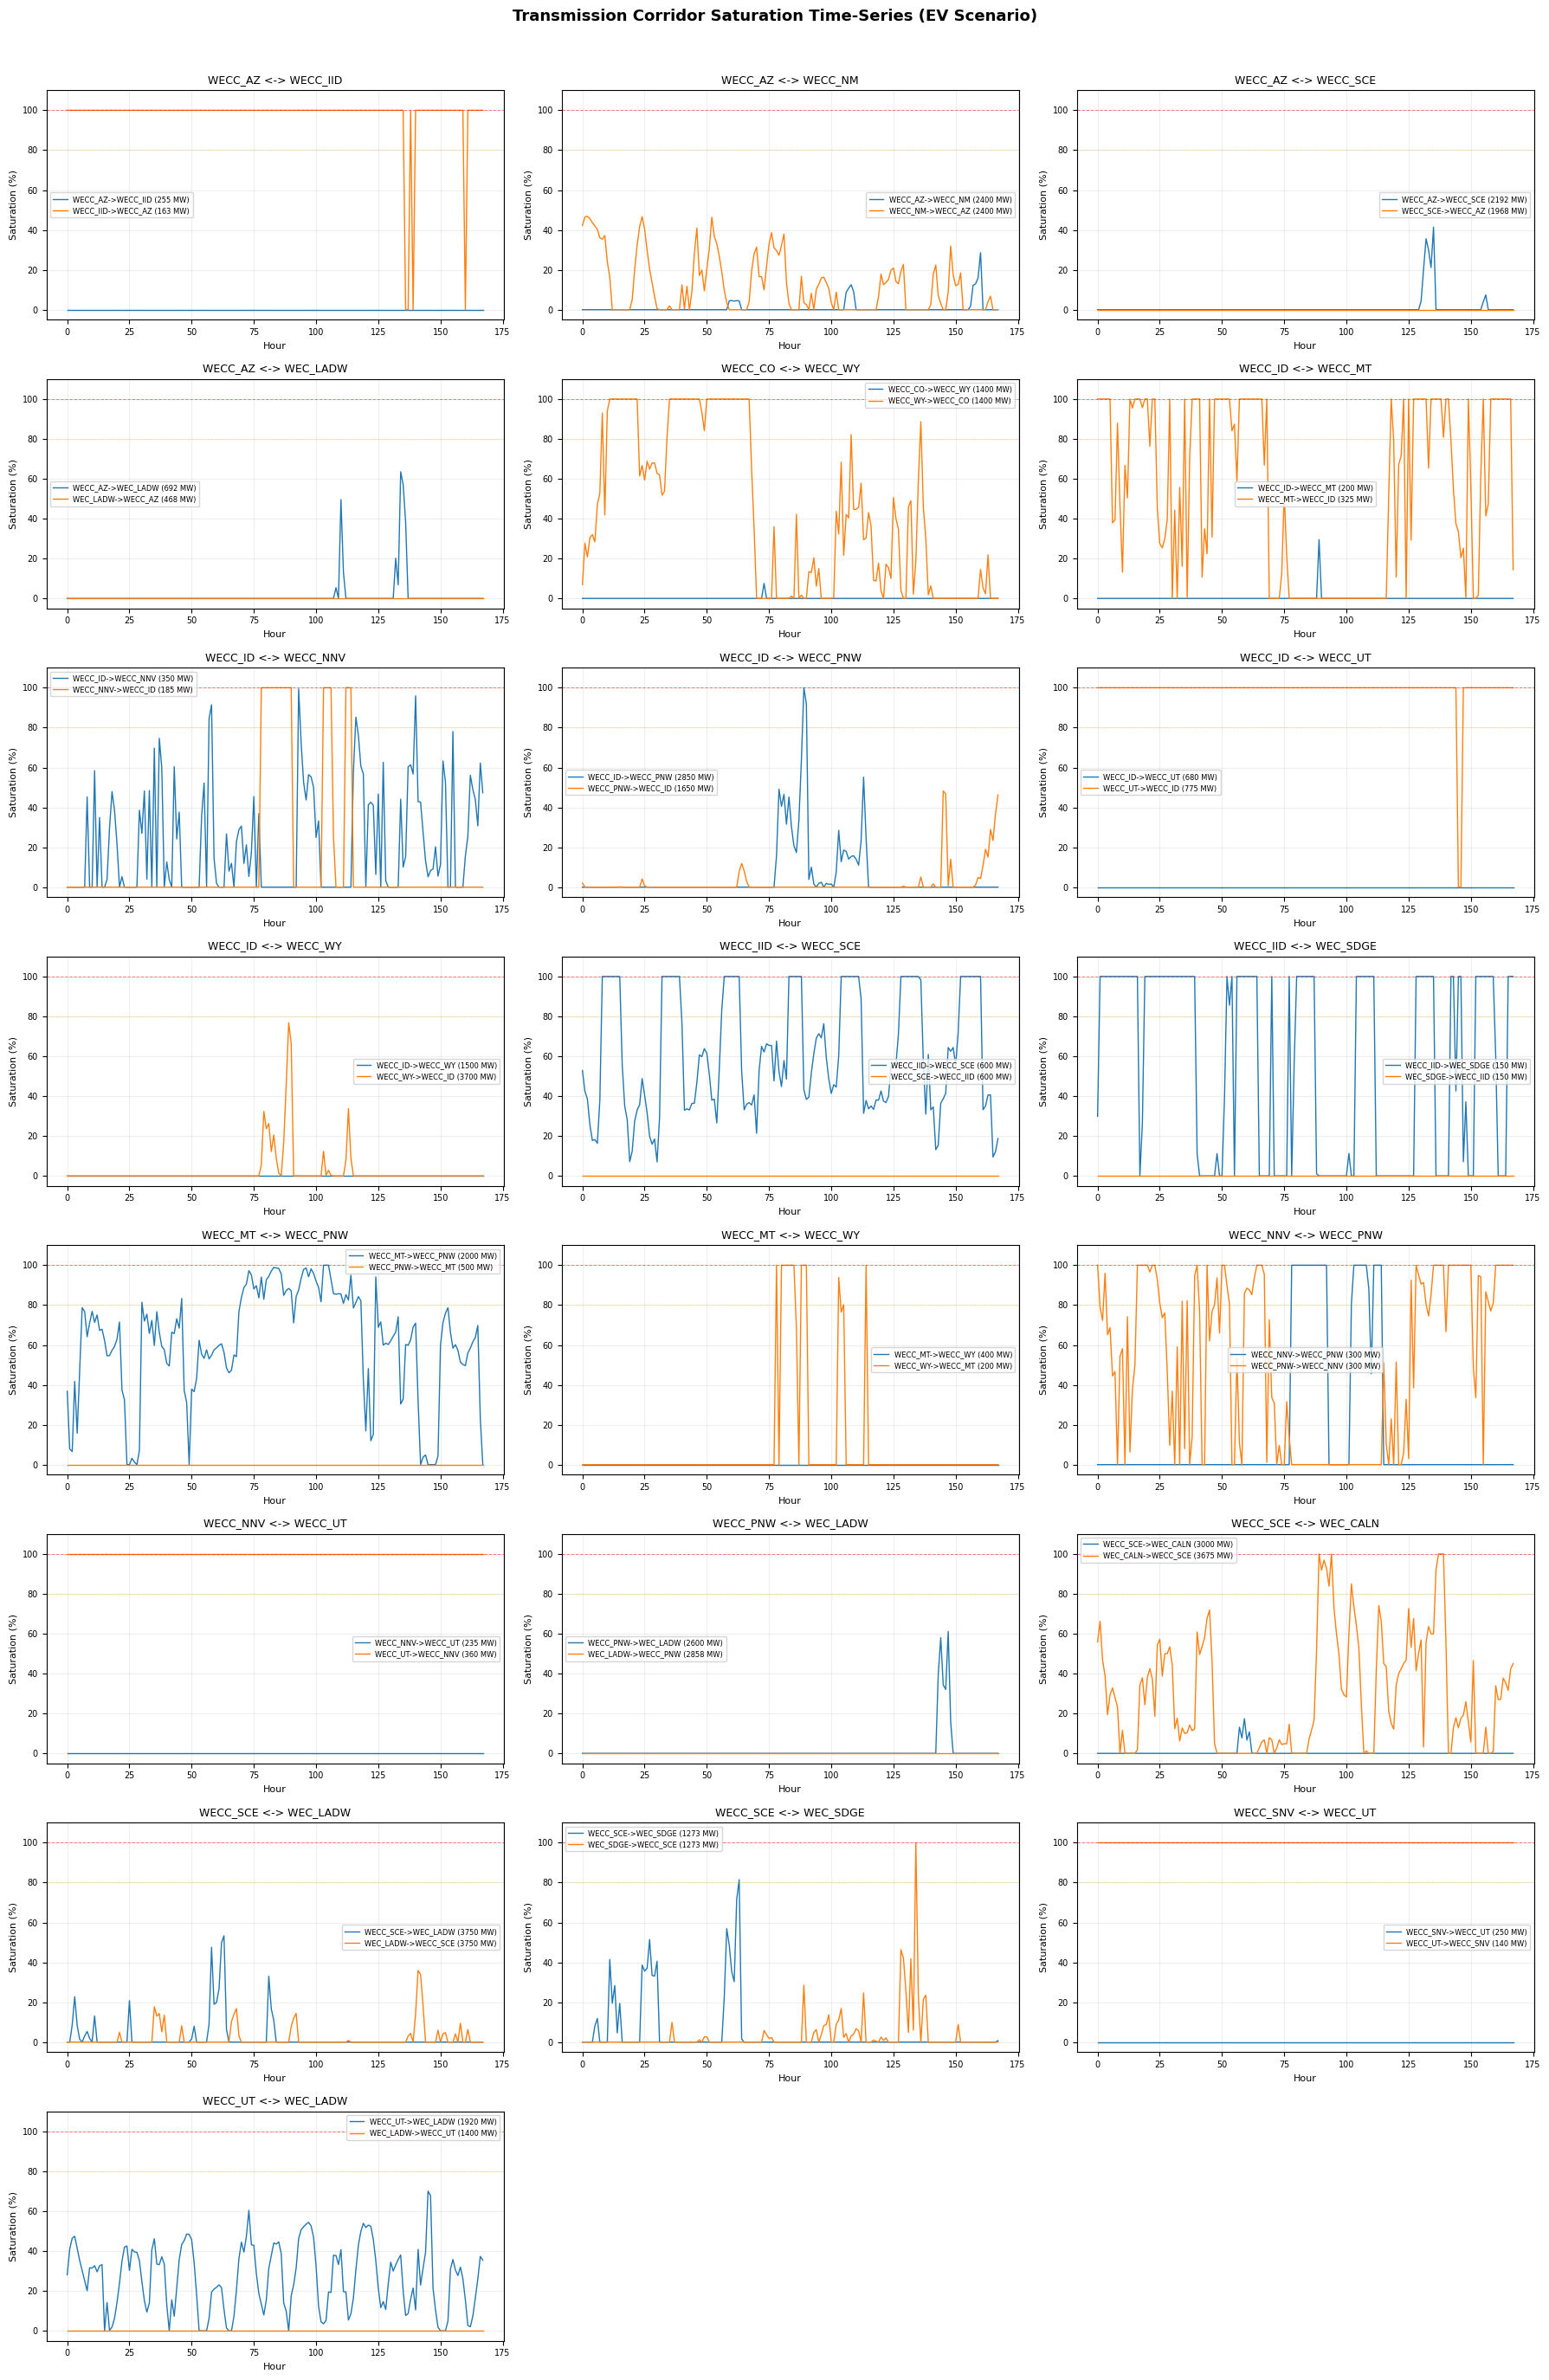


Plotted 22 corridors with ≥20% peak saturation.


In [53]:
# ============================================================
# ISSUE 3: TWO-WAY TRANSMISSION — Time-series saturation per line pair
# The model uses two separate unidirectional lines (A->B and B->A) for each corridor.
# Both can carry flow simultaneously (no mutual-exclusivity constraint).
# This is common in DC power-flow models: counter-flows are physically valid
# when they represent net flows on parallel paths.
# Below we plot time-series flow/capacity for every corridor pair.
# ============================================================

import numpy as np, matplotlib.pyplot as plt

sol = ev_solution  # use EV scenario (where two-way flow was observed)
num_hours = NUM_HOURS_INT if 'NUM_HOURS_INT' in dir() else 168

# 1. Collect all transmission time-series grouped by corridor (unordered node pair)
corridors = {}   # key = (min(s,t), max(s,t)), value = list of dicts
for source, target, edge_data in sol.edges(data=True):
    for line_handle, line in edge_data.get('lines', {}).items():
        flow = line.get('transmission', [])
        if not flow or len(flow) == 0:
            continue
        cap_installed = float(line.get('installed_capacity', 0) or 0)
        capex = line.get('capex', 0)
        if isinstance(capex, (list, np.ndarray)):
            capex = float(capex[0]) if len(capex) else 0
        else:
            capex = float(capex or 0)
        capacity = cap_installed + capex
        key = (min(source, target), max(source, target))
        corridors.setdefault(key, []).append({
            'source': source, 'target': target, 'line': line_handle,
            'capacity_MW': capacity / 1e6,
            'flow_MW': np.array(flow, dtype=float) / 1e6,
        })

print(f"Transmission corridors: {len(corridors)}")
print(f"Total lines: {sum(len(v) for v in corridors.values())}")

# 2. Identify corridors with flow in BOTH directions (at any hour)
two_way_corridors = {}
for key, lines in corridors.items():
    directions = set((l['source'], l['target']) for l in lines)
    if len(directions) >= 2:
        two_way_corridors[key] = lines

print(f"Corridors with bidirectional lines: {len(two_way_corridors)}")

# 3. Check for simultaneous two-way flow
print("\n--- Simultaneous two-way flow check ---")
simultaneous_count = 0
for key, lines in sorted(two_way_corridors.items()):
    # Group by direction
    fwd_lines = [l for l in lines if (l['source'], l['target']) == key]
    rev_lines = [l for l in lines if (l['source'], l['target']) == (key[1], key[0])]
    if not fwd_lines or not rev_lines:
        fwd_lines = [l for l in lines if l['source'] == key[0]]
        rev_lines = [l for l in lines if l['source'] == key[1]]
    fwd_flow = sum(l['flow_MW'] for l in fwd_lines)
    rev_flow = sum(l['flow_MW'] for l in rev_lines)
    # Hours where both > 0
    both_active = np.sum((fwd_flow > 0.01) & (rev_flow > 0.01))
    if both_active > 0:
        simultaneous_count += 1
        fwd_cap = sum(l['capacity_MW'] for l in fwd_lines)
        rev_cap = sum(l['capacity_MW'] for l in rev_lines)
        print(f"  {key[0]} <-> {key[1]}: simultaneous flow in {both_active}/{num_hours} hours "
              f"(fwd cap={fwd_cap:.0f} MW, rev cap={rev_cap:.0f} MW)")

if simultaneous_count == 0:
    print("  No corridors have simultaneous two-way flow.")
else:
    print(f"\n  {simultaneous_count} corridors have simultaneous flow.")
    print("  NOTE: In the model, each direction is a separate variable (NonNegativeReals).")
    print("  There is NO mutual-exclusivity constraint. The optimizer may route power both ways")
    print("  simultaneously if it reduces total cost (e.g., serving loads on both ends of a corridor).")
    print("  This is physically valid in meshed AC networks (loop flow) but can look counter-intuitive.")

# 4. Plot time-series for each corridor pair (one subplot per corridor)
# Limit to corridors where at least one direction reaches 20% saturation
plot_corridors = {}
for key, lines in sorted(corridors.items()):
    max_sat = max(l['flow_MW'].max() / l['capacity_MW'] if l['capacity_MW'] > 0 else 0 for l in lines)
    if max_sat >= 0.20:
        plot_corridors[key] = lines

n_plots = len(plot_corridors)
if n_plots == 0:
    print("\nNo corridors above 20% saturation to plot.")
else:
    # Compute layout: ~3 columns
    ncols = 3
    nrows = int(np.ceil(n_plots / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 3.5 * nrows), squeeze=False)
    hours = np.arange(num_hours)

    for idx, (key, lines) in enumerate(sorted(plot_corridors.items())):
        ax = axes[idx // ncols][idx % ncols]
        for l in lines:
            direction = f"{l['source']}->{l['target']}"
            sat = l['flow_MW'] / l['capacity_MW'] if l['capacity_MW'] > 0 else l['flow_MW'] * 0
            ax.plot(hours, sat * 100, label=f"{direction} ({l['capacity_MW']:.0f} MW)", lw=1)
        ax.set_title(f"{key[0]} <-> {key[1]}", fontsize=9)
        ax.set_ylabel('Saturation (%)', fontsize=8)
        ax.set_xlabel('Hour', fontsize=8)
        ax.set_ylim(-5, 110)
        ax.axhline(y=100, color='red', ls='--', lw=0.7, alpha=0.5)
        ax.axhline(y=80, color='orange', ls=':', lw=0.7, alpha=0.5)
        ax.legend(fontsize=6, loc='best')
        ax.grid(True, alpha=0.2)
        ax.tick_params(labelsize=7)

    # Hide empty subplots
    for idx in range(n_plots, nrows * ncols):
        axes[idx // ncols][idx % ncols].set_visible(False)

    fig.suptitle('Transmission Corridor Saturation Time-Series (EV Scenario)', fontsize=13, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig(f'{output_dir}/transmission_saturation_timeseries.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\nPlotted {n_plots} corridors with ≥20% peak saturation.")

## Stacked Generation Charts by Scenario

In [54]:
# DIAGNOSTIC: Investigate why total generation is the same
print("=" * 60)
print("DIAGNOSTIC: Why is total generation the same?")
print("=" * 60)

# Ensure generation data exists for energy balance (run extraction if this cell runs before the extraction cell)
if ('baseline_gen' not in globals() or 'ev_gen' not in globals() or
    not isinstance(baseline_gen, pd.DataFrame) or not isinstance(ev_gen, pd.DataFrame)):
    if ('extract_generation_by_fuel' in globals() and 'baseline_solution' in globals() and
        'baseline_graph' in globals() and 'ev_solution' in globals() and 'ev_graph' in globals()):
        print("Generating baseline_gen and ev_gen for energy balance...")
        baseline_gen = extract_generation_by_fuel(baseline_solution, baseline_graph)
        ev_gen = extract_generation_by_fuel(ev_solution, ev_graph)
        print(f"  Baseline records: {len(baseline_gen)}, EV records: {len(ev_gen)}\n")
    else:
        print("Note: Run the generation extraction cell first to get baseline_gen and ev_gen (required for energy balance).\n")

# 1. Check total load from solutions
def get_total_load_from_solution(solution):
    """
    Calculate total load from solution.

    Note: 'net' values in solution are POWER in Watts (W), not energy!
    sum(net) over 168 time steps = sum of power values in Watts
    For 1-hour time steps: Energy (Wh) = Power (W) * 1 hour = Power (W)
    To convert Wh to GWh: divide by 1e9
    """
    total_load_watts = 0
    for source, node in solution._node.items():
        for handle, asset in node['assets'].items():
            if 'base_load' in handle.lower() or asset.get('_class') == 'Load':
                net = asset.get('net', [])
                if net:
                    # Load net is negative (consumption), so sum will be negative
                    total_load_watts += sum(net)
    return abs(total_load_watts)  # Return absolute value (sum of power in Watts)

baseline_total_load_watts = get_total_load_from_solution(baseline_solution)
ev_total_load_watts = get_total_load_from_solution(ev_solution)

# Convert to GWh: sum(net) is total Wh (power W * 1 hr per step), so GWh = sum(net)/1e9
baseline_total_load_gwh = baseline_total_load_watts / 1e9
ev_total_load_gwh = ev_total_load_watts / 1e9

print(f"\n1. Total Load Comparison:")
print(f"   Baseline: {baseline_total_load_gwh:.2f} GWh")
print(f"   EV Scenario: {ev_total_load_gwh:.2f} GWh")
print(f"   Difference: {ev_total_load_gwh - baseline_total_load_gwh:.2f} GWh")
print(f"   Expected EV Load: 106.42 GWh")

# 2. Check wastage
def get_wastage_from_solution(solution):
    """
    Get total wastage from solution.

    IMPORTANT: Wastage IS in Watt-seconds (W-s) from the energy balance constraint!
    Each wastage[i] represents energy (W-s) for that time step.
    To convert W-s to GWh: divide by 3.6e12
    """
    total_wastage_ws = 0
    for source, node in solution._node.items():
        wastage = node.get('wastage', [])
        if wastage:
            total_wastage_ws += sum(wastage)
    return total_wastage_ws

baseline_wastage_ws = get_wastage_from_solution(baseline_solution)
ev_wastage_ws = get_wastage_from_solution(ev_solution)

baseline_wastage_gwh = baseline_wastage_ws / 3.6e12  # W-s to GWh
ev_wastage_gwh = ev_wastage_ws / 3.6e12

print(f"\n2. Wastage Comparison:")
print(f"   Baseline: {baseline_wastage_gwh:.2f} GWh")
print(f"   EV Scenario: {ev_wastage_gwh:.2f} GWh")
print(f"   Wastage Reduction: {baseline_wastage_gwh - ev_wastage_gwh:.2f} GWh")

# 3. Check storage (battery/pump hydro) - look for net discharge
def get_storage_net_from_solution(solution):
    """
    Get net storage contribution (positive = discharge, negative = charge)

    NOTE: In nearly all GridGraph extraction code, 'net' for storage assets is
    tracked in watt-hours (Wh) not W-s, so conversion to GWh is:
        GWh = Wh / 1e9
    If in doubt, check a sample value.
    """
    total_net_wh = 0
    for source, node in solution._node.items():
        for handle, asset in node['assets'].items():
            fuel = asset.get('fuel', '').lower()
            if 'battery' in fuel or 'pump hydro' in fuel or asset.get('_class') == 'Store':
                net = asset.get('net', [])
                if net:
                    total_net_wh += sum(net)
    return total_net_wh

baseline_storage_net_wh = get_storage_net_from_solution(baseline_solution)
ev_storage_net_wh = get_storage_net_from_solution(ev_solution)

baseline_storage_gwh = baseline_storage_net_wh / 1e9  # Wh to GWh
ev_storage_gwh = ev_storage_net_wh / 1e9

print(f"\n3. Storage Net Contribution:")
print(f"   Baseline: {baseline_storage_gwh:.2f} GWh (positive = net discharge)")
print(f"   EV Scenario: {ev_storage_gwh:.2f} GWh")
print(f"   Additional Discharge: {ev_storage_gwh - baseline_storage_gwh:.2f} GWh")

# 4. Check total generation from extracted data (after unit fix)
# Note: generation_kwh already in kWh, so divide by 1e6 to get GWh
# Check if baseline_gen and ev_gen exist and are DataFrames
if ('baseline_gen' in globals() and 'ev_gen' in globals() and 
    isinstance(baseline_gen, pd.DataFrame) and isinstance(ev_gen, pd.DataFrame)):
    baseline_total_gen_gwh = baseline_gen['generation_kwh'].sum() / 1e6  # kWh to GWh
    ev_total_gen_gwh = ev_gen['generation_kwh'].sum() / 1e6
    
    print(f"\n4. Total Generation (from extraction):")
    print(f"   Baseline: {baseline_total_gen_gwh:.2f} GWh")
    print(f"   EV Scenario: {ev_total_gen_gwh:.2f} GWh")
    print(f"   Difference: {ev_total_gen_gwh - baseline_total_gen_gwh:.2f} GWh")
else:
    print(f"\n4. Total Generation (from extraction):")
    print(f"   ⚠ Skipped: baseline_gen and ev_gen not yet created.")
    print(f"   Run the generation extraction cell first to see this data.")
    baseline_total_gen_gwh = None
    ev_total_gen_gwh = None

# 5. Break down Load into Consumption vs Renewables

def breakdown_load_components(solution):
    """
    Break down Load assets into consumption vs renewables.
    
    We identify Load assets by checking if 'production' key exists:
    - If asset has 'production' key -> Producer (skip, already counted in generation)
    - Otherwise -> Load-type asset
    
    Then classify as:
    - Consumption: base_load assets (handle contains 'base_load')
    - Renewables: Load assets with fuel='solar' or fuel='wind'
    """
    consumption_watts = 0
    renewable_watts = 0
    
    for source, node in solution._node.items():
        for handle, asset in node['assets'].items():
            # Skip Producer assets (they have 'production' key)
            if 'production' in asset:
                continue
            
            # All non-Producer assets with 'net' are Load-type
            net = asset.get('net', [])
            if net:
                total_net = sum(net)
                
                # Check fuel type and handle name to classify
                fuel = str(asset.get('fuel', '')).lower()
                handle_lower = handle.lower()
                
                # Renewables are Load assets with solar/wind fuel
                is_renewable = (
                    'solar' in fuel or 'wind' in fuel or
                    'solar' in handle_lower or 'wind' in handle_lower
                )
                
                # Consumption loads are base_load assets
                is_consumption = 'base_load' in handle_lower
                
                if is_renewable:
                    # Renewable generation (net is negative, represents generation)
                    renewable_watts += abs(total_net)
                elif is_consumption:
                    # Consumption load (net is negative for consumption)
                    consumption_watts += abs(total_net)
    
    return consumption_watts, renewable_watts

# Debug: Print sample Load-type assets to verify classification
print("\nDEBUG: Sample Load-type assets (non-Producer) from baseline:")
sample_consumption = 0
sample_renewable = 0
for source, node in baseline_solution._node.items():
    for handle, asset in node['assets'].items():
        # Skip Producers
        if 'production' in asset:
            continue
        
        net = asset.get('net', [])
        if net and (sample_consumption < 6 or sample_renewable < 6):
            capacity = asset.get('installed_capacity', 0)
            fuel = asset.get('fuel', 'N/A')
            total_net = sum(net)
            fuel_lower = str(fuel).lower()
            handle_lower = handle.lower()
            is_renewable = ('solar' in fuel_lower or 'wind' in fuel_lower or 'solar' in handle_lower or 'wind' in handle_lower)
            is_consumption = 'base_load' in handle_lower
            classification = 'Renewable' if is_renewable else ('Consumption' if is_consumption else 'Unclassified')
            
            if is_consumption and sample_consumption < 6:
                print(f"  {handle}: fuel={fuel}, capacity={capacity/1e9:.2f} GW, net={total_net/1e9:.2f} GW -> {classification}")
                sample_consumption += 1
            elif is_renewable and sample_renewable < 6:
                print(f"  {handle}: fuel={fuel}, capacity={capacity/1e9:.2f} GW, net={total_net/1e9:.2f} GW -> {classification}")
                sample_renewable += 1

baseline_consumption_w, baseline_renewable_w = breakdown_load_components(baseline_solution)
ev_consumption_w, ev_renewable_w = breakdown_load_components(ev_solution)

baseline_consumption_gwh = baseline_consumption_w / 1e9
baseline_renewable_gwh = baseline_renewable_w / 1e9
ev_consumption_gwh = ev_consumption_w / 1e9
ev_renewable_gwh = ev_renewable_w / 1e9

print(f"\n5. Load Breakdown (Consumption vs Renewables):")
print(f"   Baseline:")
print(f"     Total 'Load': {baseline_total_load_gwh:.2f} GWh")
print(f"     - Consumption: {baseline_consumption_gwh:.2f} GWh")
print(f"     - Renewables: {baseline_renewable_gwh:.2f} GWh")
print(f"   EV Scenario:")
print(f"     Total 'Load': {ev_total_load_gwh:.2f} GWh")
print(f"     - Consumption: {ev_consumption_gwh:.2f} GWh")
print(f"     - Renewables: {ev_renewable_gwh:.2f} GWh")

# 6. Check imports/exports
def get_imports_exports_from_solution(solution):
    """
    Extract total imports and exports from solution.
    NetworkX graphs store edges in _adj (adjacency list).
    Transmission lines store 'transmission' (power flow from source to target in Watts).
    
    For each edge (source -> target):
    - 'transmission' is power sent from source (export from source)
    - 'transmission' * efficiency is power received at target (import to target)
    
    We sum all exports (from all sources) and all imports (to all targets).
    """
    total_imports_w = 0
    total_exports_w = 0
    
    # NetworkX graphs use _adj for edges (adjacency list)
    if hasattr(solution, '_adj'):
        for source in solution._adj:
            for target, edge_data in solution._adj[source].items():
                if 'lines' in edge_data:
                    for line_name, line_data in edge_data['lines'].items():
                        # Transmission line stores 'transmission' (power flow from source to target)
                        transmission = line_data.get('transmission', [])
                        efficiency = line_data.get('efficiency', 1.0)
                        
                        if transmission:
                            transmission_sum = sum(transmission)
                            
                            # Export: power sent from source
                            total_exports_w += transmission_sum
                            
                            # Import: power received at target (accounting for efficiency)
                            total_imports_w += transmission_sum * efficiency
    
    return total_imports_w, total_exports_w

# Debug: Check edge structure
print("\nDEBUG: Checking edge structure for imports/exports:")
if hasattr(baseline_solution, '_adj'):
    edge_count = sum(len(edges) for edges in baseline_solution._adj.values())
    print(f"  Found {edge_count} edges in solution._adj")
    if edge_count > 0:
        # Show first edge
        for source in baseline_solution._adj:
            for target, edge_data in baseline_solution._adj[source].items():
                print(f"  Edge: {source} -> {target}")
                print(f"    Keys: {list(edge_data.keys())}")
                if 'lines' in edge_data:
                    print(f"    Lines: {list(edge_data['lines'].keys())}")
                    for line_name, line_data in list(edge_data['lines'].items())[:1]:
                        print(f"      Line {line_name} keys: {list(line_data.keys())}")
                break
            if edge_count > 0:
                break
else:
    print("  No _adj attribute found")

baseline_imports_w, baseline_exports_w = get_imports_exports_from_solution(baseline_solution)
ev_imports_w, ev_exports_w = get_imports_exports_from_solution(ev_solution)

baseline_imports_gwh = baseline_imports_w / 1e9
baseline_exports_gwh = baseline_exports_w / 1e9
ev_imports_gwh = ev_imports_w / 1e9
ev_exports_gwh = ev_exports_w / 1e9

print(f"\n6. Imports/Exports:")
print(f"   Baseline:")
print(f"     Imports: {baseline_imports_gwh:.2f} GWh")
print(f"     Exports: {baseline_exports_gwh:.2f} GWh")
print(f"     Net Imports: {baseline_imports_gwh - baseline_exports_gwh:.2f} GWh")
print(f"   EV Scenario:")
print(f"     Imports: {ev_imports_gwh:.2f} GWh")
print(f"     Exports: {ev_exports_gwh:.2f} GWh")
print(f"     Net Imports: {ev_imports_gwh - ev_exports_gwh:.2f} GWh")

# 7. Complete Energy Balance
print(f"\n7. Complete Energy Balance:")
print(f"   Formula: Generation + Renewables + Imports = Consumption + Wastage + Exports")

if baseline_total_gen_gwh is not None and ev_total_gen_gwh is not None:
    print(f"\n   Baseline:")
    baseline_supply = baseline_total_gen_gwh + baseline_renewable_gwh + baseline_imports_gwh
    baseline_demand = baseline_consumption_gwh + baseline_wastage_gwh + baseline_exports_gwh
    print(f"     Supply: {baseline_total_gen_gwh:.2f} + {baseline_renewable_gwh:.2f} + {baseline_imports_gwh:.2f} = {baseline_supply:.2f} GWh")
    print(f"     Demand: {baseline_consumption_gwh:.2f} + {baseline_wastage_gwh:.2f} + {baseline_exports_gwh:.2f} = {baseline_demand:.2f} GWh")
    print(f"     Balance: {baseline_supply:.2f} - {baseline_demand:.2f} = {baseline_supply - baseline_demand:.2f} GWh")
    
    print(f"\n   EV Scenario:")
    ev_supply = ev_total_gen_gwh + ev_renewable_gwh + ev_imports_gwh
    ev_demand = ev_consumption_gwh + ev_wastage_gwh + ev_exports_gwh
    print(f"     Supply: {ev_total_gen_gwh:.2f} + {ev_renewable_gwh:.2f} + {ev_imports_gwh:.2f} = {ev_supply:.2f} GWh")
    print(f"     Demand: {ev_consumption_gwh:.2f} + {ev_wastage_gwh:.2f} + {ev_exports_gwh:.2f} = {ev_demand:.2f} GWh")
    print(f"     Balance: {ev_supply:.2f} - {ev_demand:.2f} = {ev_supply - ev_demand:.2f} GWh")
else:
    print(f"\n   ⚠ Skipped: Generation data not available. Run generation extraction cell first.")
    baseline_supply = None
    baseline_demand = None
    ev_supply = None
    ev_demand = None

print("\n" + "=" * 60)
print("CONCLUSION:")
print("=" * 60)

# Check EV load addition
# Check EV load addition - use total load difference (most reliable)
total_load_increase = ev_total_load_gwh - baseline_total_load_gwh
consumption_increase = ev_consumption_gwh - baseline_consumption_gwh

if abs(total_load_increase - 106.42) < 1:
    print(f"✓ EV load correctly added: {total_load_increase:.2f} GWh increase in total load")
    if abs(consumption_increase - 106.42) < 1:
        print(f"  ✓ Consumption breakdown confirms: {consumption_increase:.2f} GWh increase")
    else:
        print(f"  ⚠ Consumption breakdown shows: {consumption_increase:.2f} GWh (check if base_load assets are detected)")
else:
    print(f"⚠ EV load increase: {total_load_increase:.2f} GWh (expected 106.42 GWh)")

# Check energy balance
if baseline_supply is not None and baseline_demand is not None:
    if abs(baseline_supply - baseline_demand) < 10:
        print(f"✓ Baseline energy balance checks out (difference: {baseline_supply - baseline_demand:.2f} GWh)")
    else:
        print(f"⚠ Baseline energy balance issue: {baseline_supply - baseline_demand:.2f} GWh imbalance")
else:
    print(f"⚠ Baseline energy balance: Cannot check (generation data not available)")
if ev_supply is not None and ev_demand is not None:
    if abs(ev_supply - ev_demand) < 10:
        print(f"✓ EV scenario energy balance checks out (difference: {ev_supply - ev_demand:.2f} GWh)")
    else:
        print(f"⚠ EV scenario energy balance issue: {ev_supply - ev_demand:.2f} GWh imbalance")
else:
    print(f"⚠ EV scenario energy balance: Cannot check (generation data not available)")

# Check generation response
if baseline_total_gen_gwh is not None and ev_total_gen_gwh is not None:
    gen_increase = ev_total_gen_gwh - baseline_total_gen_gwh
    import_increase = (ev_imports_gwh - ev_exports_gwh) - (baseline_imports_gwh - baseline_exports_gwh)
    renewable_change = ev_renewable_gwh - baseline_renewable_gwh
    
    print(f"\nHow the system met the additional {total_load_increase:.2f} GWh EV load:")
    print(f"  • Dispatchable generation increase: {gen_increase:.2f} GWh")
    print(f"  • Net imports increase: {import_increase:.2f} GWh")
    print(f"  • Renewable generation change: {renewable_change:.2f} GWh")
    print(f"  • Wastage reduction: {baseline_wastage_gwh - ev_wastage_gwh:.2f} GWh")
    total_response = gen_increase + import_increase + renewable_change + (baseline_wastage_gwh - ev_wastage_gwh)
    print(f"  • Total response: {total_response:.2f} GWh")
    print(f"  • Match to EV load: {abs(total_response - total_load_increase) < 1}")
else:
    print(f"\n⚠ Generation response analysis skipped: Generation data not available.")
    print(f"   Run the generation extraction cell first to see this analysis.")

print("=" * 60)

DIAGNOSTIC: Why is total generation the same?

1. Total Load Comparison:
   Baseline: 15174.88 GWh
   EV Scenario: 15281.30 GWh
   Difference: 106.42 GWh
   Expected EV Load: 106.42 GWh

2. Wastage Comparison:
   Baseline: 8.84 GWh
   EV Scenario: 8.38 GWh
   Wastage Reduction: 0.47 GWh

3. Storage Net Contribution:
   Baseline: -0.00 GWh (positive = net discharge)
   EV Scenario: 0.00 GWh
   Additional Discharge: 0.00 GWh

4. Total Generation (from extraction):
   Baseline: 15452.67 GWh
   EV Scenario: 15559.90 GWh
   Difference: 107.23 GWh

DEBUG: Sample Load-type assets (non-Producer) from baseline:
  installed_1455: fuel=solar, capacity=0.00 GW, net=0.00 GW -> Renewable
  installed_9501: fuel=solar, capacity=0.00 GW, net=0.05 GW -> Renewable
  installed_10690: fuel=solar, capacity=0.29 GW, net=6.94 GW -> Renewable
  installed_11188: fuel=wind, capacity=0.06 GW, net=5.78 GW -> Renewable
  installed_11524: fuel=solar, capacity=0.02 GW, net=0.47 GW -> Renewable
  installed_11595: fuel

In [55]:
# Diagnostic: Check if emission factors are being read from the graph
print("=" * 60)
print("EMISSION FACTOR DIAGNOSTICS")
print("=" * 60)

# Sample a few assets to check their emission factors
sample_count = 0
for source, node in baseline_graph._node.items():
    if sample_count >= 5:
        break
    assets = node.get('assets', {})
    for handle, asset_data in list(assets.items())[:2]:  # Check first 2 assets per region
        if 'base_load' in handle or asset_data.get('type') == 'load':
            continue
        fuel = asset_data.get('fuel', 'unknown')
        co2 = asset_data.get('co2', 'NOT FOUND')
        nox = asset_data.get('nox', 'NOT FOUND')
        so2 = asset_data.get('so2', 'NOT FOUND')
        print(f"\nRegion: {source}, Asset: {handle}")
        print(f"  Fuel: {fuel}")
        print(f"  CO2 factor: {co2} kg/W-s")
        print(f"  NOx factor: {nox} kg/W-s")
        print(f"  SO2 factor: {so2} kg/W-s")
        sample_count += 1
        if sample_count >= 5:
            break

print("\n" + "=" * 60)
print("If you see 'NOT FOUND' or all zeros, emission factors need to be added to the JSON file.")
print("=" * 60)


EMISSION FACTOR DIAGNOSTICS

Region: WECC_AZ, Asset: installed_21
  Fuel: hydro
  CO2 factor: 0.0 kg/W-s
  NOx factor: 0.0 kg/W-s
  SO2 factor: 0.0 kg/W-s

Region: WECC_AZ, Asset: installed_825
  Fuel: coal
  CO2 factor: 3.277544913955556e-07 kg/W-s
  NOx factor: 2.9407881333333335e-10 kg/W-s
  SO2 factor: 1.3985753333333335e-10 kg/W-s

Region: WECC_CO, Asset: installed_0
  Fuel: coal
  CO2 factor: 2.9630544606222223e-07 kg/W-s
  NOx factor: 2.3662382666666666e-10 kg/W-s
  SO2 factor: 8.152056222222222e-11 kg/W-s

Region: WECC_CO, Asset: installed_22
  Fuel: oil
  CO2 factor: 8.418453323777777e-08 kg/W-s
  NOx factor: 1.1264201333333333e-10 kg/W-s
  SO2 factor: 2.26796e-12 kg/W-s

Region: WECC_ID, Asset: installed_42
  Fuel: hydro
  CO2 factor: 0.0 kg/W-s
  NOx factor: 0.0 kg/W-s
  SO2 factor: 0.0 kg/W-s

If you see 'NOT FOUND' or all zeros, emission factors need to be added to the JSON file.


## Calculate Marginal Generation and Emissions


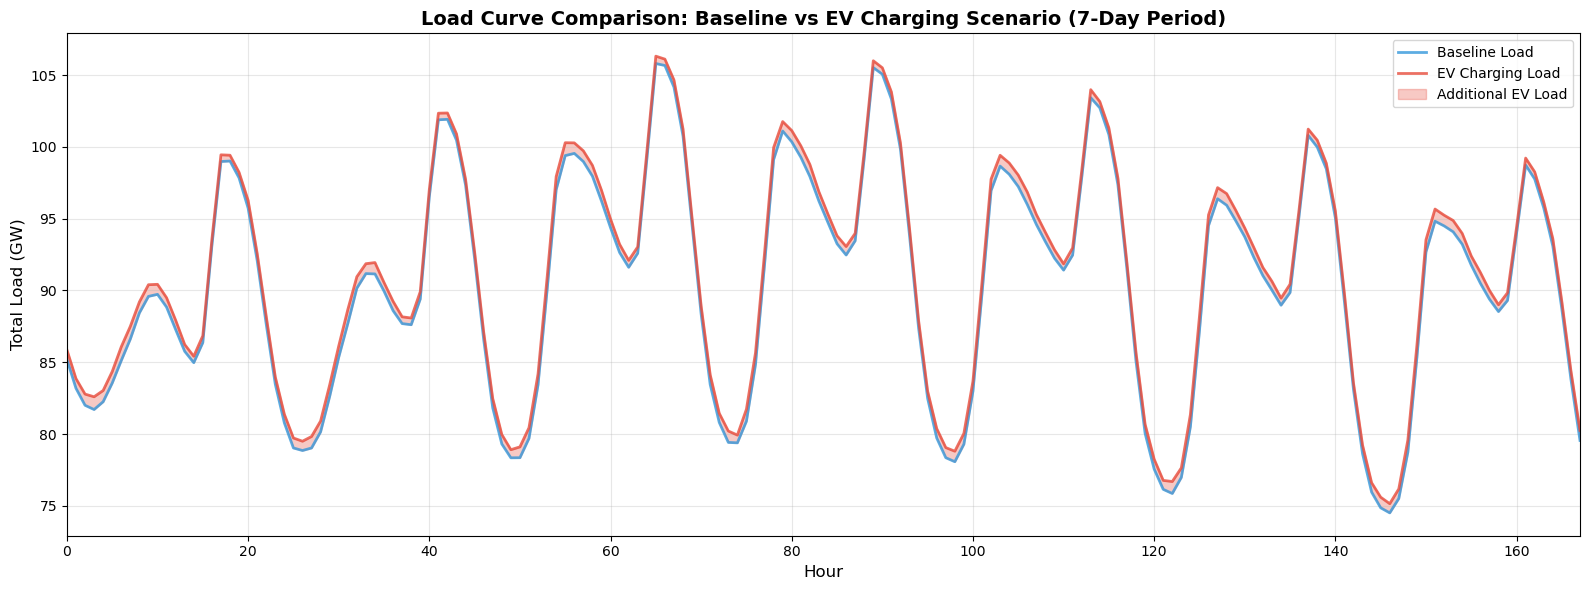

LOAD CURVE STATISTICS

Baseline Load:
  Average: 90.33 GW
  Peak: 105.80 GW
  Minimum: 74.51 GW
  Total Energy: 15174.88 GWh

EV Charging Load:
  Average: 90.96 GW
  Peak: 106.32 GW
  Minimum: 75.15 GW
  Total Energy: 15281.30 GWh

Additional Load (EV - Baseline):
  Average: 0.63 GW
  Peak: 1.00 GW
  Minimum: 0.39 GW
  Total Energy: 106.42 GWh
  Expected EV Energy: 106.42 GWh


In [56]:
# Extract load data from both scenarios
def extract_total_load_by_hour(solution):
    """
    Extract total load by hour from solution.
    
    Returns:
    -------
    hourly_load : np.array
        Array of total load (absolute value) in GW for each hour
    """
    # Initialize array for hourly loads
    num_hours = len(list(solution._node.values())[0]['assets'][list(list(solution._node.values())[0]['assets'].keys())[0]].get('net', []))
    hourly_load = np.zeros(num_hours)
    
    for source, node in solution._node.items():
        for handle, asset in node['assets'].items():
            if 'base_load' in handle.lower() or asset.get('_class') == 'Load':
                net = asset.get('net', [])
                if net and len(net) > 0:
                    # Load net is negative (consumption), convert to positive for display
                    hourly_load += np.abs(np.array(net))
    
    return hourly_load

# Extract hourly loads from both scenarios
baseline_load_hourly = extract_total_load_by_hour(baseline_solution)
ev_load_hourly = extract_total_load_by_hour(ev_solution)

# Convert to GW for better readability
baseline_load_gw = baseline_load_hourly / 1e9
ev_load_gw = ev_load_hourly / 1e9

# Create comparison plot
fig, ax = plt.subplots(figsize=(16, 6))

hours = np.arange(len(baseline_load_gw))

# Plot both load curves
ax.plot(hours, baseline_load_gw, label='Baseline Load', linewidth=2, color='#3498DB', alpha=0.8)
ax.plot(hours, ev_load_gw, label='EV Charging Load', linewidth=2, color='#E74C3C', alpha=0.8)

# Shade the difference
ax.fill_between(hours, baseline_load_gw, ev_load_gw, 
                 where=(ev_load_gw >= baseline_load_gw),
                 alpha=0.3, color='#E74C3C', label='Additional EV Load')

# Formatting
ax.set_xlabel('Hour', fontsize=12)
ax.set_ylabel('Total Load (GW)', fontsize=12)
ax.set_title('Load Curve Comparison: Baseline vs EV Charging Scenario (7-Day Period)', 
             fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, len(baseline_load_gw) - 1)

plt.tight_layout()
plt.savefig(f'{output_dir}/load_curve_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Print statistics
print("=" * 60)
print("LOAD CURVE STATISTICS")
print("=" * 60)
print(f"\nBaseline Load:")
print(f"  Average: {baseline_load_gw.mean():.2f} GW")
print(f"  Peak: {baseline_load_gw.max():.2f} GW")
print(f"  Minimum: {baseline_load_gw.min():.2f} GW")
print(f"  Total Energy: {baseline_load_gw.sum():.2f} GWh")

print(f"\nEV Charging Load:")
print(f"  Average: {ev_load_gw.mean():.2f} GW")
print(f"  Peak: {ev_load_gw.max():.2f} GW")
print(f"  Minimum: {ev_load_gw.min():.2f} GW")
print(f"  Total Energy: {ev_load_gw.sum():.2f} GWh")

print(f"\nAdditional Load (EV - Baseline):")
additional_load = ev_load_gw - baseline_load_gw
print(f"  Average: {additional_load.mean():.2f} GW")
print(f"  Peak: {additional_load.max():.2f} GW")
print(f"  Minimum: {additional_load.min():.2f} GW")
print(f"  Total Energy: {additional_load.sum():.2f} GWh")
print(f"  Expected EV Energy: 106.42 GWh")
print("=" * 60)

In [57]:
# Merge baseline and EV scenarios to calculate differences
# Use hour, region, asset, fuel as keys

# Check if baseline_gen and ev_gen exist and are DataFrames
# If not, try to create them using extract_generation_by_fuel if available
if ('baseline_gen' not in globals() or 'ev_gen' not in globals() or 
    not isinstance(baseline_gen, pd.DataFrame) or not isinstance(ev_gen, pd.DataFrame)):
    
    # Check if extraction function exists
    if 'extract_generation_by_fuel' in globals() and callable(extract_generation_by_fuel):
        print("baseline_gen and ev_gen not found or invalid. Extracting generation data...")
        if 'baseline_solution' in globals() and 'baseline_graph' in globals():
            baseline_gen = extract_generation_by_fuel(baseline_solution, baseline_graph)
            print(f"  Created baseline_gen: {len(baseline_gen)} records")
        else:
            raise RuntimeError("baseline_solution and baseline_graph must exist. Run optimization cells first.")
        
        if 'ev_solution' in globals() and 'ev_graph' in globals():
            ev_gen = extract_generation_by_fuel(ev_solution, ev_graph)
            print(f"  Created ev_gen: {len(ev_gen)} records")
        else:
            raise RuntimeError("ev_solution and ev_graph must exist. Run optimization cells first.")
    else:
        raise RuntimeError("baseline_gen and ev_gen must be DataFrames. Run the generation extraction cell first.")

merge_cols = ['hour', 'region', 'asset', 'fuel']

# Merge on these columns
marginal_df = ev_gen.merge(
    baseline_gen,
    on=merge_cols,
    suffixes=('_ev', '_baseline'),
    how='outer'
).fillna(0)

# Calculate marginal generation (difference)
marginal_df['marginal_generation_kw'] = (
    marginal_df['generation_kw_ev'] - marginal_df['generation_kw_baseline']
)
marginal_df['marginal_generation_kwh'] = (
    marginal_df['generation_kwh_ev'] - marginal_df['generation_kwh_baseline']
)

# Use emission factors from EV scenario (should be same as baseline)
marginal_df['co2_factor'] = marginal_df['co2_factor_ev'].fillna(marginal_df['co2_factor_baseline'])
marginal_df['nox_factor'] = marginal_df['nox_factor_ev'].fillna(marginal_df['nox_factor_baseline'])
marginal_df['so2_factor'] = marginal_df['so2_factor_ev'].fillna(marginal_df['so2_factor_baseline'])

# Calculate emissions
# Emission factors are in kg per W-s, generation is in W
# For hourly emissions: generation_kw * 1000 (to W) * 3600 (seconds) * factor
# Or: generation_kwh * 1000 (to Wh) * 3600 (seconds/hour) * factor
# Actually, if factor is kg/W-s, then for 1 hour: W * 3600 s * factor = kg
# So: marginal_generation_kw * 1000 * 3600 * factor = kg
# Or: marginal_generation_kwh * 1000 * 3600 * factor = kg (but kWh already includes the hour)
# Let's use: marginal_generation_kw * 1000 * 3600 * factor

marginal_df['co2_emissions_kg'] = (
    marginal_df['marginal_generation_kw'] * 1000 * 3600 * marginal_df['co2_factor']
)
marginal_df['nox_emissions_kg'] = (
    marginal_df['marginal_generation_kw'] * 1000 * 3600 * marginal_df['nox_factor']
)
marginal_df['so2_emissions_kg'] = (
    marginal_df['marginal_generation_kw'] * 1000 * 3600 * marginal_df['so2_factor']
)

# Add day column (assuming hour 0 is start of period)
marginal_df['day'] = marginal_df['hour'] // 24

print(f"Marginal generation calculated for {len(marginal_df)} records")
print(f"\nTotal marginal generation by fuel:")
print(marginal_df.groupby('fuel')['marginal_generation_kwh'].sum().sort_values(ascending=False))


Marginal generation calculated for 934080 records

Total marginal generation by fuel:
fuel
natural gas    9.936743e+07
coal           7.635450e+06
battery        1.076980e+06
oil            6.417253e+04
hydro          1.313900e+02
geothermal     0.000000e+00
solar          0.000000e+00
import         0.000000e+00
non-fossil     0.000000e+00
nuclear        0.000000e+00
wind           0.000000e+00
waste          0.000000e+00
pump hydro    -1.309894e+04
biomass       -8.982245e+05
Name: marginal_generation_kwh, dtype: float64


## Aggregate Results by Hour, Day, and Year


In [58]:
# Create period_results from marginal_df if it doesn't exist (e.g. run this cell before the aggregation cell)
if 'period_results' not in globals() or period_results is None:
    if 'marginal_df' in globals() and isinstance(marginal_df, pd.DataFrame):
        period_results = marginal_df.groupby('fuel').agg({
            'marginal_generation_kwh': 'sum',
            'co2_emissions_kg': 'sum',
            'nox_emissions_kg': 'sum',
            'so2_emissions_kg': 'sum',
        }).reset_index()
        print("Created period_results from marginal_df.")
    else:
        print("Run the marginal emissions cell first so that marginal_df exists, then run the aggregation cell (or re-run this cell).")


In [59]:
# Aggregate by hour
hourly_results = marginal_df.groupby(['hour', 'fuel']).agg({
    'marginal_generation_kwh': 'sum',
    'co2_emissions_kg': 'sum',
    'nox_emissions_kg': 'sum',
    'so2_emissions_kg': 'sum',
}).reset_index()

# Aggregate by day
daily_results = marginal_df.groupby(['day', 'fuel']).agg({
    'marginal_generation_kwh': 'sum',
    'co2_emissions_kg': 'sum',
    'nox_emissions_kg': 'sum',
    'so2_emissions_kg': 'sum',
}).reset_index()

# Aggregate by period (all data - 7 days)
period_results = marginal_df.groupby('fuel').agg({
    'marginal_generation_kwh': 'sum',
    'co2_emissions_kg': 'sum',
    'nox_emissions_kg': 'sum',
    'so2_emissions_kg': 'sum',
}).reset_index()

print("=" * 60)
print("7-DAY PERIOD SUMMARY BY FUEL TYPE")
print("=" * 60)
print(period_results.to_string(index=False))

print("\n" + "=" * 60)
print("TOTAL MARGINAL GENERATION AND EMISSIONS")
print("=" * 60)
print(f"Total Marginal Generation: {period_results['marginal_generation_kwh'].sum() / 1e6:.2f} GWh")
print(f"Total CO2 Emissions: {period_results['co2_emissions_kg'].sum() / 1e6:.2f} million kg CO2")
print(f"Total NOx Emissions: {period_results['nox_emissions_kg'].sum() / 1e6:.2f} million kg NOx")
print(f"Total SO2 Emissions: {period_results['so2_emissions_kg'].sum() / 1e6:.2f} million kg SO2")


7-DAY PERIOD SUMMARY BY FUEL TYPE
       fuel  marginal_generation_kwh  co2_emissions_kg  nox_emissions_kg  so2_emissions_kg
    battery             1.076980e+06      0.000000e+00          0.000000          0.000000
    biomass            -8.982245e+05     -1.052057e+04       -829.168528       -156.738981
       coal             7.635450e+06      8.368382e+06       5869.545148         59.447477
 geothermal             0.000000e+00      0.000000e+00          0.000000          0.000000
      hydro             1.313900e+02      0.000000e+00          0.000000          0.000000
     import             0.000000e+00      0.000000e+00          0.000000          0.000000
natural gas             9.936743e+07      4.841916e+07      70105.754091        457.480738
 non-fossil             0.000000e+00      0.000000e+00          0.000000          0.000000
    nuclear             0.000000e+00      0.000000e+00          0.000000          0.000000
        oil             6.417253e+04     -1.875261e+05  

## Export Results to CSV Files


In [60]:
# Export to CSV files
output_dir = 'ev_charging_results'
os.makedirs(output_dir, exist_ok=True)

# Hourly results
hourly_results.to_csv(f'{output_dir}/hourly_marginal_generation_emissions.csv', index=False)
print(f"Hourly results saved to {output_dir}/hourly_marginal_generation_emissions.csv")

# Daily results
daily_results.to_csv(f'{output_dir}/daily_marginal_generation_emissions.csv', index=False)
print(f"Daily results saved to {output_dir}/daily_marginal_generation_emissions.csv")

# Period results
period_results.to_csv(f'{output_dir}/period_marginal_generation_emissions.csv', index=False)
print(f"Period results saved to {output_dir}/period_marginal_generation_emissions.csv")

# Detailed hourly results (with region and asset info)
marginal_df.to_csv(f'{output_dir}/detailed_hourly_marginal_results.csv', index=False)
print(f"Detailed hourly results saved to {output_dir}/detailed_hourly_marginal_results.csv")


Hourly results saved to ev_charging_results/hourly_marginal_generation_emissions.csv
Daily results saved to ev_charging_results/daily_marginal_generation_emissions.csv
Period results saved to ev_charging_results/period_marginal_generation_emissions.csv
Detailed hourly results saved to ev_charging_results/detailed_hourly_marginal_results.csv


## Visualizations


In [61]:
# Diagnostic: Check period_results before plotting
print("=" * 60)
print("DIAGNOSTIC: Checking period_results for Plot 2")
print("=" * 60)
if 'period_results' not in locals():
    print("ERROR: period_results variable not found!")
    print("Please run the aggregation cell (cell 18) first.")
elif period_results is None or len(period_results) == 0:
    print("ERROR: period_results is empty or None!")
else:
    print(f"period_results shape: {period_results.shape}")
    print(f"Columns: {list(period_results.columns)}")
    print(f"\nTotal marginal generation: {period_results['marginal_generation_kwh'].sum() / 1e6:.2f} GWh")
    print(f"\nMarginal generation by fuel:")
    fuel_totals = period_results.groupby('fuel')['marginal_generation_kwh'].sum().sort_values(ascending=False)
    for fuel, total in fuel_totals.items():
        if abs(total) > 1e-3:  # Only show significant values
            print(f"  {fuel:20s}: {total/1e6:10.2f} GWh")
print("=" * 60)


DIAGNOSTIC: Checking period_results for Plot 2
period_results shape: (14, 5)
Columns: ['fuel', 'marginal_generation_kwh', 'co2_emissions_kg', 'nox_emissions_kg', 'so2_emissions_kg']

Total marginal generation: 107.23 GWh

Marginal generation by fuel:
  natural gas         :      99.37 GWh
  coal                :       7.64 GWh
  battery             :       1.08 GWh
  oil                 :       0.06 GWh
  hydro               :       0.00 GWh
  pump hydro          :      -0.01 GWh
  biomass             :      -0.90 GWh


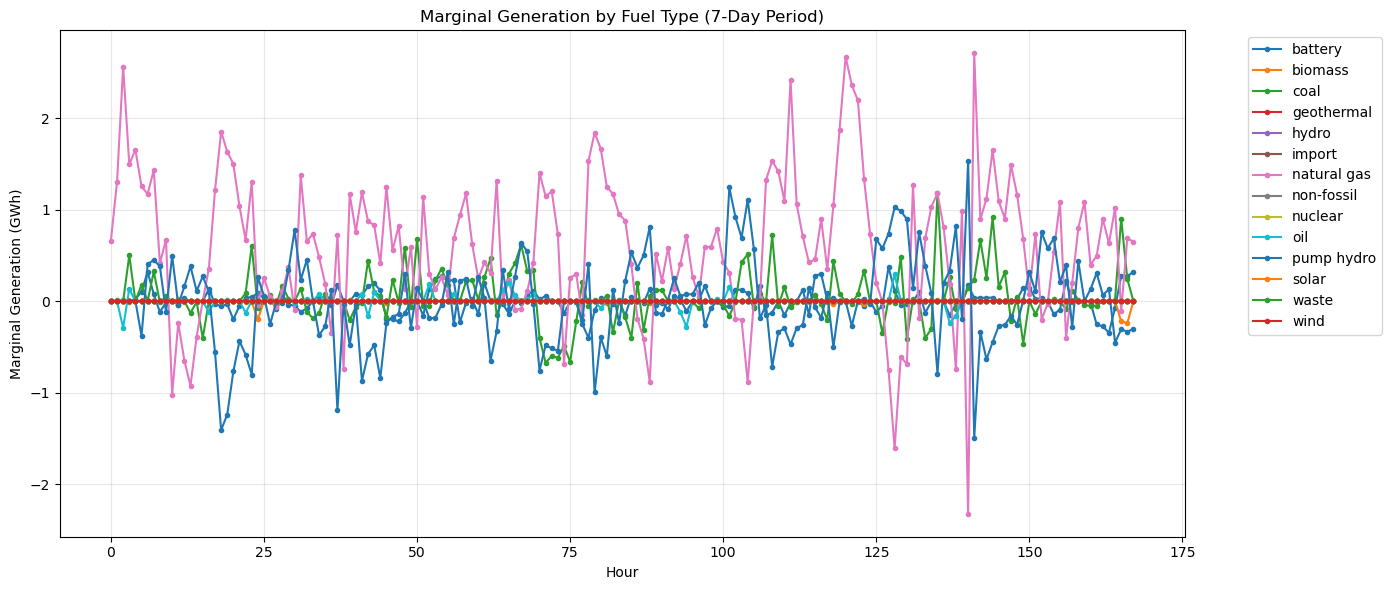

In [62]:
# Plot 1: Hourly marginal generation by fuel type (7 days)
fig, ax = plt.subplots(figsize=(14, 6))

for fuel in sorted(hourly_results['fuel'].unique()):
    fuel_data = hourly_results[hourly_results['fuel'] == fuel]
    if len(fuel_data) > 0:
        ax.plot(fuel_data['hour'], fuel_data['marginal_generation_kwh'] / 1e6, 
                label=fuel, marker='o', markersize=3)

ax.set_xlabel('Hour')
ax.set_ylabel('Marginal Generation (GWh)')
ax.set_title('Marginal Generation by Fuel Type (7-Day Period)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{output_dir}/hourly_marginal_generation_7days.png', dpi=150)
plt.show()


In [63]:
## Aggregate Results by Hour, Day, and Period

# Aggregate by hour
hourly_results = marginal_df.groupby(['hour', 'fuel']).agg({
    'marginal_generation_kwh': 'sum',
    'co2_emissions_kg': 'sum',
    'nox_emissions_kg': 'sum',
    'so2_emissions_kg': 'sum',
}).reset_index()

# Aggregate by day
daily_results = marginal_df.groupby(['day', 'fuel']).agg({
    'marginal_generation_kwh': 'sum',
    'co2_emissions_kg': 'sum',
    'nox_emissions_kg': 'sum',
    'so2_emissions_kg': 'sum',
}).reset_index()

# Aggregate by period (all data - 7 days)
period_results = marginal_df.groupby('fuel').agg({
    'marginal_generation_kwh': 'sum',
    'co2_emissions_kg': 'sum',
    'nox_emissions_kg': 'sum',
    'so2_emissions_kg': 'sum',
}).reset_index()

print("=" * 60)
print("7-DAY PERIOD SUMMARY BY FUEL TYPE")
print("=" * 60)
print(period_results.to_string(index=False))

print("\n" + "=" * 60)
print("TOTAL MARGINAL GENERATION AND EMISSIONS (7 DAYS)")
print("=" * 60)
print(f"Total Marginal Generation: {period_results['marginal_generation_kwh'].sum() / 1e6:.2f} GWh")
print(f"Total CO2 Emissions: {period_results['co2_emissions_kg'].sum() / 1e6:.2f} million kg CO2")
print(f"Total NOx Emissions: {period_results['nox_emissions_kg'].sum() / 1e6:.2f} million kg NOx")
print(f"Total SO2 Emissions: {period_results['so2_emissions_kg'].sum() / 1e6:.2f} million kg SO2")

7-DAY PERIOD SUMMARY BY FUEL TYPE
       fuel  marginal_generation_kwh  co2_emissions_kg  nox_emissions_kg  so2_emissions_kg
    battery             1.076980e+06      0.000000e+00          0.000000          0.000000
    biomass            -8.982245e+05     -1.052057e+04       -829.168528       -156.738981
       coal             7.635450e+06      8.368382e+06       5869.545148         59.447477
 geothermal             0.000000e+00      0.000000e+00          0.000000          0.000000
      hydro             1.313900e+02      0.000000e+00          0.000000          0.000000
     import             0.000000e+00      0.000000e+00          0.000000          0.000000
natural gas             9.936743e+07      4.841916e+07      70105.754091        457.480738
 non-fossil             0.000000e+00      0.000000e+00          0.000000          0.000000
    nuclear             0.000000e+00      0.000000e+00          0.000000          0.000000
        oil             6.417253e+04     -1.875261e+05  

Plot: 6 fuels, Net: 107.23 GWh (+108.14, -0.91)


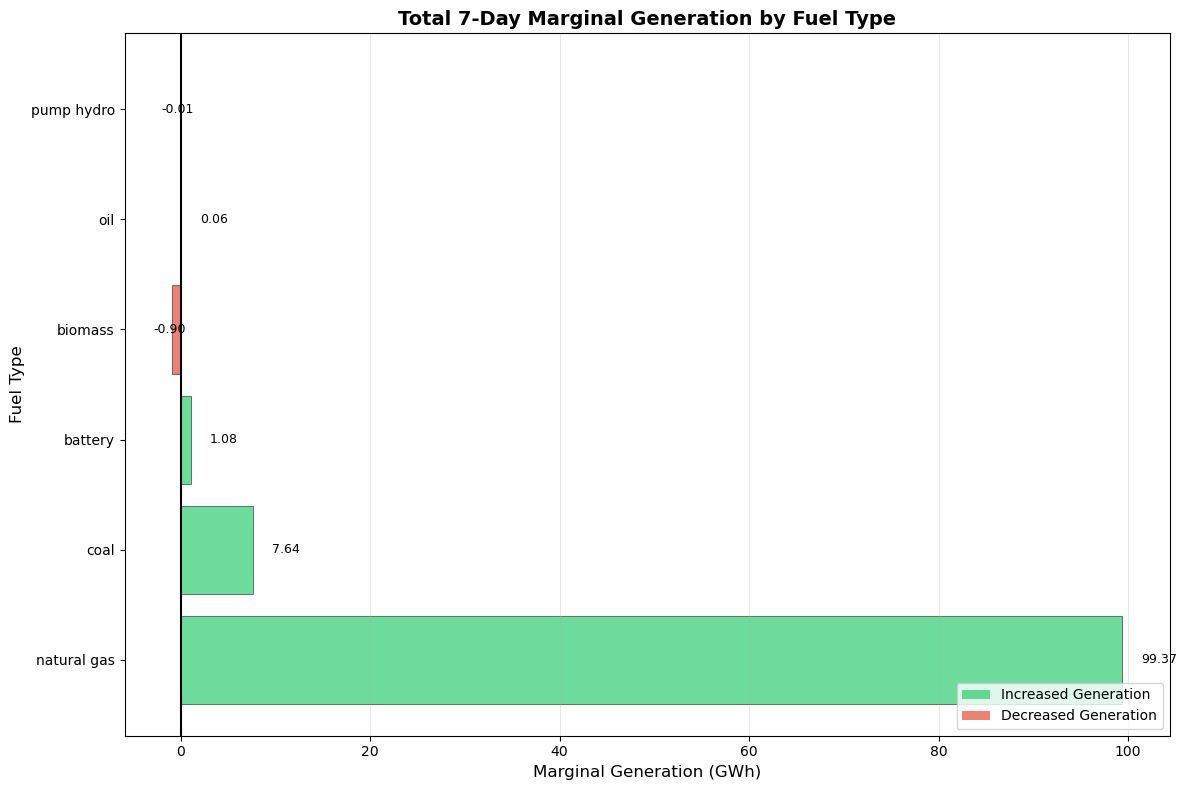

In [64]:
# Plot 2: Period marginal generation by fuel type (horizontal bar chart - more reliable)
fig, ax = plt.subplots(figsize=(12, 8))

# Check that period_results exists
if 'period_results' not in locals() or period_results is None or len(period_results) == 0:
    ax.text(0.5, 0.5, "No data available\n(Run aggregation cell first)", 
            ha='center', va='center', fontsize=16, transform=ax.transAxes)
    ax.set_title('Total 7-Day Marginal Generation by Fuel Type')
else:
    # Group by 'fuel' and sum 'marginal_generation_kwh'
    period_gen_by_fuel = period_results.groupby('fuel', as_index=False)['marginal_generation_kwh'].sum()
    
    # Convert to GWh
    period_gen_by_fuel['marginal_generation_gwh'] = period_gen_by_fuel['marginal_generation_kwh'] / 1e6
    
    # Filter to significant values (> 0.001 GWh absolute)
    period_gen_by_fuel = period_gen_by_fuel[period_gen_by_fuel['marginal_generation_gwh'].abs() > 0.001]
    
    if period_gen_by_fuel.empty:
        ax.text(0.5, 0.5, "No significant data\n(All values < 0.001 GWh)", 
                ha='center', va='center', fontsize=14, transform=ax.transAxes)
        ax.set_title('Total 7-Day Marginal Generation by Fuel Type')
    else:
        # Sort by absolute value
        period_gen_by_fuel = period_gen_by_fuel.sort_values('marginal_generation_gwh', key=abs, ascending=False)
        
        # Color code: green for positive, red for negative
        colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in period_gen_by_fuel['marginal_generation_gwh']]
        
        # Create horizontal bar chart
        bars = ax.barh(period_gen_by_fuel['fuel'], period_gen_by_fuel['marginal_generation_gwh'], 
                       color=colors, alpha=0.7, edgecolor='black', linewidth=0.5)
        
        # Add value labels
        max_abs = period_gen_by_fuel['marginal_generation_gwh'].abs().max()
        for i, (fuel, value) in enumerate(zip(period_gen_by_fuel['fuel'], 
                                                period_gen_by_fuel['marginal_generation_gwh'])):
            label_x = value + (max_abs * 0.02 if value >= 0 else -max_abs * 0.02)
            ax.text(label_x, i, f'{value:.2f}', va='center', fontsize=9)
        
        ax.set_xlabel('Marginal Generation (GWh)', fontsize=12)
        ax.set_ylabel('Fuel Type', fontsize=12)
        ax.set_title('Total 7-Day Marginal Generation by Fuel Type', fontsize=14, fontweight='bold')
        ax.axvline(x=0, color='black', linestyle='-', linewidth=1.5)
        ax.grid(True, alpha=0.3, axis='x')
        
        # Legend
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='#2ecc71', alpha=0.7, label='Increased Generation'),
            Patch(facecolor='#e74c3c', alpha=0.7, label='Decreased Generation')
        ]
        ax.legend(handles=legend_elements, loc='lower right', fontsize=10)
        
        # Print summary
        pos = period_gen_by_fuel[period_gen_by_fuel['marginal_generation_gwh'] > 0]['marginal_generation_gwh'].sum()
        neg = period_gen_by_fuel[period_gen_by_fuel['marginal_generation_gwh'] < 0]['marginal_generation_gwh'].sum()
        print(f"Plot: {len(period_gen_by_fuel)} fuels, Net: {pos + neg:.2f} GWh (+{pos:.2f}, {neg:.2f})")

plt.tight_layout()
plt.savefig(f'{output_dir}/period_marginal_generation_by_fuel.png', dpi=150, bbox_inches='tight')
plt.show()

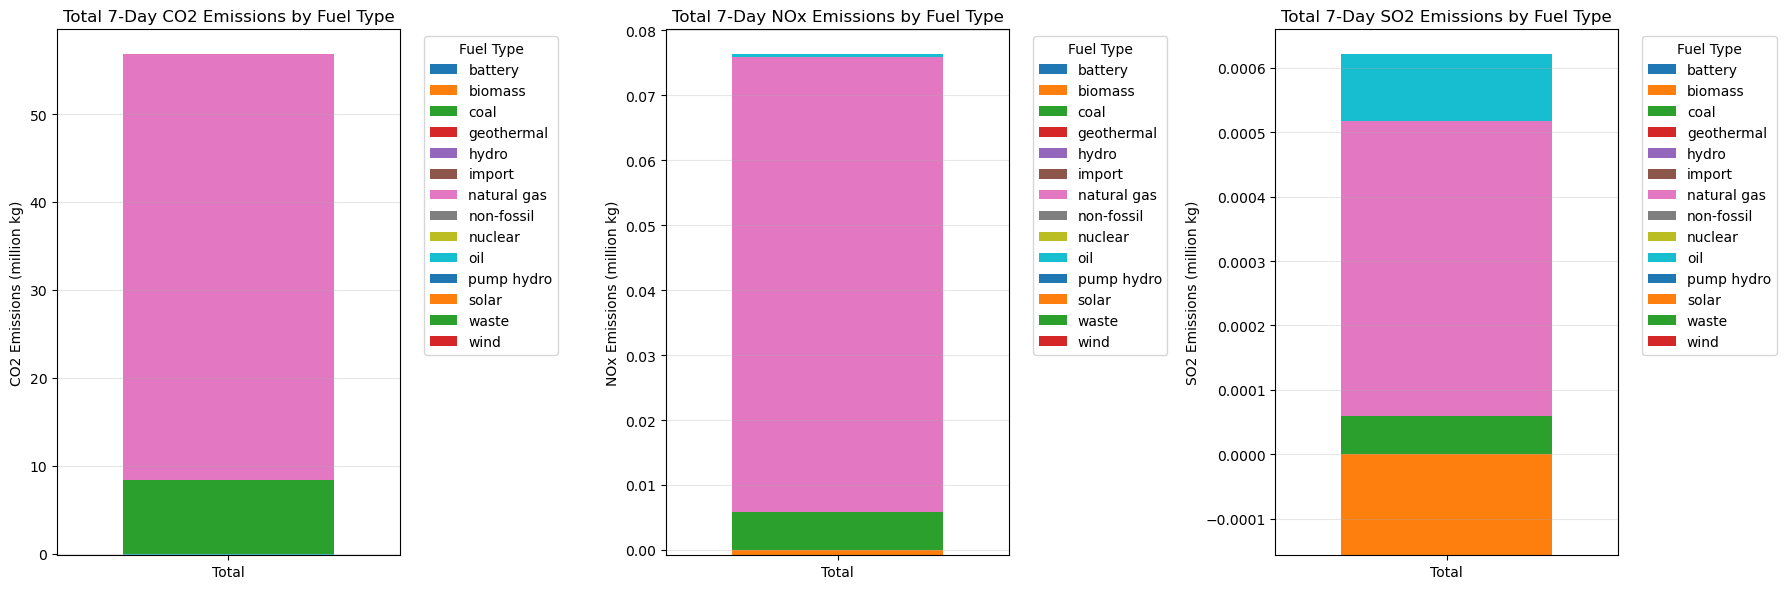

In [65]:
# Plot 3: Period emissions by fuel type
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

emissions = ['co2_emissions_kg', 'nox_emissions_kg', 'so2_emissions_kg']
titles = ['CO2 Emissions', 'NOx Emissions', 'SO2 Emissions']
units = ['million kg', 'million kg', 'million kg']

for ax, emission, title, unit in zip(axes, emissions, titles, units):
    # Group by fuel, sum emissions, convert to DataFrame for plotting
    period_sum_by_fuel = period_results.groupby('fuel', as_index=False)[emission].sum()
    period_sum_by_fuel[emission] = period_sum_by_fuel[emission] / 1e6  # Convert to million kg

    # Pivot to match the expected plotting format: columns=fuel, index=row with emission sums
    plot_df = period_sum_by_fuel.set_index('fuel').T

    plot_df.plot(kind='bar', stacked=True, ax=ax, width=0.8)
    ax.set_ylabel(f'{title} ({unit})')
    ax.set_title(f'Total 7-Day {title} by Fuel Type')
    ax.set_xticklabels(['Total'], rotation=0)
    ax.legend(title='Fuel Type', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{output_dir}/period_emissions_by_fuel.png', dpi=150)
plt.show()


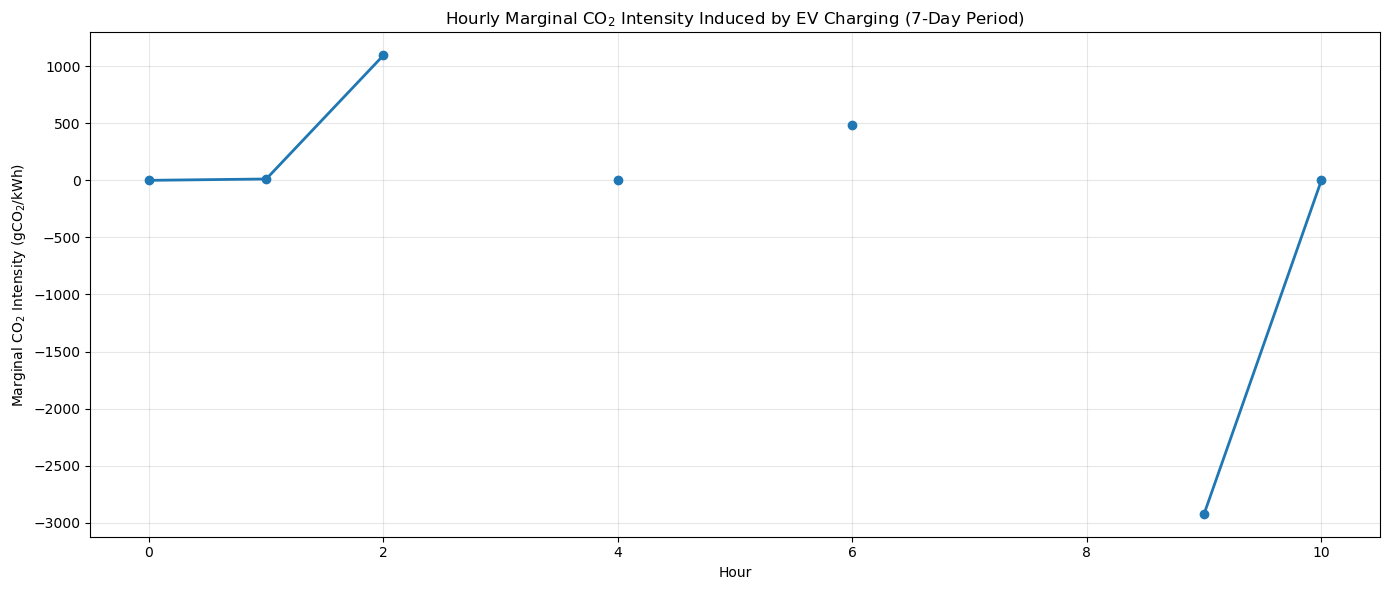

In [66]:
# Plot 4: Hourly marginal CO2 emissions intensity (gCO2/kWh) over the 7-day period (0-168 hours, no merging/grouping)
fig, ax = plt.subplots(figsize=(14, 6))

# Why is this plot non-continuous?
# Because whenever marginal_generation_kwh is zero for an hour, the CO2 intensity is undefined or "nan."
# This results in gaps in the line plot (matplotlib breaks the line when encountering np.nan).
# These discontinuities correctly reflect hours where there was zero additional generation attributed to EV charging,
# and thus no emissions intensity can be defined (cannot divide by zero energy).

import numpy as np

n_hours = len(period_results)
hours = np.arange(n_hours)

hourly_gen = period_results['marginal_generation_kwh'].values
hourly_co2 = period_results['co2_emissions_kg'].values

# Where marginal_generation_kwh == 0, set to np.nan to avoid division by zero and leave gaps in the plot
hourly_gen_nozero = np.where(hourly_gen == 0, np.nan, hourly_gen)
co2_intensity = (hourly_co2 * 1000) / hourly_gen_nozero  # gCO2/kWh

ax.plot(hours, co2_intensity, linewidth=2, marker='o')

ax.set_xlabel('Hour')
ax.set_ylabel('Marginal CO$_2$ Intensity (gCO$_2$/kWh)')
ax.set_title('Hourly Marginal CO$_2$ Intensity Induced by EV Charging (7-Day Period)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{output_dir}/hourly_marginal_co2_intensity.png', dpi=150)
plt.show()


## Summary Statistics


In [67]:
print("=" * 60)
print("SUMMARY STATISTICS (7-DAY PERIOD)")
print("=" * 60)

# Ensure period_results exists (build from marginal_df if aggregation cell was skipped)
if 'period_results' not in globals() or period_results is None:
    if 'marginal_df' in globals() and isinstance(marginal_df, pd.DataFrame):
        period_results = marginal_df.groupby('fuel').agg({
            'marginal_generation_kwh': 'sum',
            'co2_emissions_kg': 'sum',
            'nox_emissions_kg': 'sum',
            'so2_emissions_kg': 'sum',
        }).reset_index()
    else:
        raise RuntimeError("Run the marginal emissions / aggregation cells first so that 'marginal_df' or 'period_results' exists.")

# EV charging total (requires ev_charging_load from EV load setup cell)
if 'ev_charging_load' in globals() and ev_charging_load is not None:
    total_ev_energy = ev_charging_load.sum() / 1e6  # MWh (ev_charging_load in W, sum = Wh, /1e6 = MWh)
    total_ev_energy_gwh = total_ev_energy / 1e3     # GWh
else:
    total_ev_energy_gwh = None

# Overall statistics from period_results
total_marginal_gen = period_results['marginal_generation_kwh'].sum() / 1e6  # MWh
total_marginal_gen_gwh = total_marginal_gen / 1e3  # GWh
total_co2 = period_results['co2_emissions_kg'].sum() / 1e6  # metric tons

if total_ev_energy_gwh is not None:
    print(f"\nTotal EV Charging Energy Demand: {total_ev_energy_gwh:.2f} GWh")
else:
    print(f"\nTotal EV Charging Energy Demand: (run EV load setup cell to define ev_charging_load)")
print(f"Total Marginal Generation: {total_marginal_gen_gwh:.2f} GWh")
print(f"Total Marginal CO2 Emissions: {total_co2:.2f} metric tons ({total_co2 * 1000:.2f} thousand kg)")

# Average emissions intensity
if total_marginal_gen > 0:
    avg_co2_intensity = (total_co2 * 1e6) / (total_marginal_gen * 1e3)  # g CO2 per kWh
    avg_co2_intensity_kg = (total_co2 * 1e6) / (total_marginal_gen * 1e6)  # kg CO2 per kWh
    print(f"\nAverage Marginal CO2 Intensity: {avg_co2_intensity_kg:.4f} kg CO2 per kWh")

# By fuel type
print("\n" + "-" * 60)
print("MARGINAL GENERATION BY FUEL TYPE:")
print("-" * 60)
fuel_sums_gen = period_results.groupby('fuel')['marginal_generation_kwh'].sum()
total_fuel_gen = fuel_sums_gen.sum()
for fuel, val in fuel_sums_gen.items():
    val_gwh = val / 1e6
    percent = (val / total_fuel_gen * 100) if total_fuel_gen > 0 else 0
    print(f"  {fuel:20s}: {val_gwh:10.2f} GWh ({percent:.1f}%)")

print("\n" + "-" * 60)
print("MARGINAL CO2 EMISSIONS BY FUEL TYPE:")
print("-" * 60)
fuel_sums_co2 = period_results.groupby('fuel')['co2_emissions_kg'].sum()
total_fuel_co2 = fuel_sums_co2.sum()
for fuel, val in fuel_sums_co2.items():
    val_kt = val / 1e6      # metric tons
    percent = (val / total_fuel_co2 * 100) if total_fuel_co2 > 0 else 0
    print(f"  {fuel:20s}: {val_kt:10.2f} metric tons ({percent:.1f}%)")


SUMMARY STATISTICS (7-DAY PERIOD)

Total EV Charging Energy Demand: 106.42 GWh
Total Marginal Generation: 0.11 GWh
Total Marginal CO2 Emissions: 56.59 metric tons (56589.50 thousand kg)

Average Marginal CO2 Intensity: 0.5277 kg CO2 per kWh

------------------------------------------------------------
MARGINAL GENERATION BY FUEL TYPE:
------------------------------------------------------------
  battery             :       1.08 GWh (1.0%)
  biomass             :      -0.90 GWh (-0.8%)
  coal                :       7.64 GWh (7.1%)
  geothermal          :       0.00 GWh (0.0%)
  hydro               :       0.00 GWh (0.0%)
  import              :       0.00 GWh (0.0%)
  natural gas         :      99.37 GWh (92.7%)
  non-fossil          :       0.00 GWh (0.0%)
  nuclear             :       0.00 GWh (0.0%)
  oil                 :       0.06 GWh (0.1%)
  pump hydro          :      -0.01 GWh (-0.0%)
  solar               :       0.00 GWh (0.0%)
  waste               :       0.00 GWh (0.0%)
 